### Imports

In [28]:
from abc import ABC, abstractmethod
from typing import List, Any, cast, Dict, Tuple, Set
from collections import defaultdict
import subprocess, re, json, pm4py, hashlib, os, random, time, csv, sys, math, shutil, subprocess, pathlib, warnings
from functools import lru_cache
from dataclasses import dataclass
from math import sqrt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from graphviz import Digraph
from itertools import count
from IPython.display import display
warnings.filterwarnings('ignore')
from pathlib import Path

### Empty nodes counter

In [29]:
def enumerate_tau(node, counter):
    if (not hasattr(node, "children") or not node.children) and getattr(node, "label", None) is None:
        node.label = f"tau_{counter[0]}"
        counter[0] += 1

    if hasattr(node, "children") and node.children is not None:
        for child in node.children:
            enumerate_tau(child, counter)

none_counter = [1]

### Process tree

In [30]:
class ASTNode(ABC):
    @abstractmethod
    def to_string(self, depth: int = 0) -> str:
        pass

class LiteralASTNode(ASTNode):
    def __init__(self, label: str):
        self.label = label

    def to_string(self, depth: int = 0) -> str:
        indent = "    " * depth
        return f"{indent}Literal: '{self.label}'"

class OperatorASTNode(ASTNode):
    def __init__(self, operator: str, children: List[ASTNode]):
        self.operator = operator
        self.children = children

    def to_string(self, depth: int = 0) -> str:
        indent = "    " * depth
        child_str = "\n".join(child.to_string(depth + 1) for child in self.children)
        return f"{indent}Operator: {self.operator}\n{child_str}"

### Process tree to AST

Converts process tree to AST

In [31]:
def process_tree_to_ast(pt: Any) -> ASTNode:
    if hasattr(pt, "children") and pt.children:
        op = getattr(pt, "operator", None) or "Seq"
        children_ast = [process_tree_to_ast(c) for c in pt.children]
        return OperatorASTNode(operator=str(op), children=children_ast)
    else:
        label = getattr(pt, "label", None) or "tau"
        return LiteralASTNode(label=str(label))

### Visitor

In [32]:
class ASTVisitor(ABC):
    @abstractmethod
    def visit_literal(self, node: LiteralASTNode):
        pass

    @abstractmethod
    def visit_operator(self, node: OperatorASTNode):
        pass

    def visit(self, node: ASTNode) -> Any:
        if isinstance(node, LiteralASTNode):
            lit = cast(LiteralASTNode, node)
            return self.visit_literal(lit)
        elif isinstance(node, OperatorASTNode):
            op = cast(OperatorASTNode, node)
            return self.visit_operator(op)
        else:
            ...

### AST Visitor extension

Creates logical specification from AST

In [33]:
class LogicalSpecificationVisitor(ASTVisitor):
    def visit_literal(self, node: LiteralASTNode):
        return f"'{node.label}'"

    def visit_operator(self, node: OperatorASTNode):
        op = node.operator.lower()
        if op == "seq":
            if len(node.children) == 2:
                ini = self.visit(node.children[0])
                fin = self.visit(node.children[1])
                return [
                    f"{ini} => <> {fin}",
                    f"~{ini} => ~<> {fin}",
                    f"[]~({ini} & {fin})"
                ]
            return [
                f"{self.visit(node.children[i])} => <> {self.visit(node.children[i+1])}"
                for i in range(len(node.children) - 1)
            ]
        parts = []
        for c in node.children:
            r = self.visit(c)
            parts.append(r[0] if isinstance(r, list) else r)
        args_str = ", ".join(parts)
        return [f"{node.operator}({args_str})"]

visitor = LogicalSpecificationVisitor()

### Fromatting

Basic functions that help with activities

In [34]:
class Format:
    @staticmethod
    def lowercase_in_quotes(s: str) -> str:
        def _repl(m: re.Match) -> str:
            inner = m.group(1)
            return f"'{inner.lower()}'"
        return re.sub(r"'([^']*)'", _repl, s)

    @staticmethod
    def replace_parens_in_quotes(s: str) -> str:
        def _repl(m: re.Match) -> str:
            inner = m.group(1).replace('(', '-').replace(')', '-')
            return f"'{inner}'"
        return re.sub(r"'([^']*)'", _repl, s)

    @staticmethod
    def replace_colons_in_quotes(s: str) -> str:
        def _repl(m: re.Match) -> str:
            inner = m.group(1)
            return f"'{inner.replace(':', '_')}'"
        return re.sub(r"'([^']*)'", _repl, s)

    @staticmethod
    def replace_spaces_with_underscore(text: str) -> str:
        def replace_spaces(m: re.Match) -> str:
            return re.sub(r'\s+', '_', m.group(0))
        text_with_underscore = re.sub(r"'(.*?)'", replace_spaces, text)
        text_no_quotes = re.sub(r"'", '', text_with_underscore)
        return text_no_quotes

    @staticmethod
    def label_expressions(expression: str) -> str:
        labelled_expression = ""
        label_number = 0
        for c in expression:
            if c == '(':
                label_number += 1
                labelled_expression += f"({label_number}]"
            elif c == ')':
                labelled_expression += f"[{label_number})"
                label_number -= 1
            else:
                labelled_expression += c
        return labelled_expression

### Process tree adapter

Defines tools for argument extraction

In [35]:
class ProcessTreeAdapter:
    @staticmethod
    def extract_arguments_from_labelled_expression(labelled_expression):
        pattern_label_number = int(labelled_expression[labelled_expression.index(
            "(") + 1:labelled_expression.index("]")])
        trimmed_labelled_expression = labelled_expression[labelled_expression.index("]") + 1: list(re.finditer(r'\[', labelled_expression))[-1].start()]
        split = trimmed_labelled_expression.split(",")
        arguments = []
        brackets_counter = 0
        temp_arg = ""
        for s in split:
            brackets_counter += s.count('(')
            brackets_counter -= s.count(')')
            temp_arg += s + ","
            if brackets_counter == 0:
                temp_arg = temp_arg[:-1]
                arguments.append(temp_arg)
                temp_arg = ""
        return arguments, pattern_label_number

    @staticmethod
    def find_symbol(labelled_expression):
        pattern = r'^[^()]*'
        match = re.match(pattern, labelled_expression)
        if match:
            return re.sub(r'\s+', '', match.group())
        else:
            raise Exception("No match")

    @staticmethod
    def replace_symbol_with_name(labelled_pattern_expression, pattern_label_number, old_symbol, new_name):
        pattern = rf"{re.escape(old_symbol)}\(\s*{pattern_label_number}\s*\]"
        final_name = f"{new_name}({pattern_label_number}]"
        replaced_string = re.sub(pattern, final_name, labelled_pattern_expression, count=1)

        return replaced_string

    @staticmethod
    def get_highest_label(labelledExpression: str) -> int:
        maxLabel = -1
        active = False
        sb = ""
        for c in labelledExpression:
            if c == '(':
                active = True
            elif c == ']':
                if int(sb) > maxLabel:
                    maxLabel = int(sb)
                sb = ""
                active = False
            elif active:
                sb += c
        return maxLabel

### Pattern operators

In [36]:
class Sequence:
    _counter = defaultdict(int)

    @staticmethod
    def change_symbol_into_name(labelled_expression, pattern_label_number):
        n = len(labelled_expression)
        if not (2 <= n <= 15):
            raise Exception(f"Pattern for Seq{n} does not exist")

        Sequence._counter[n] += 1

        pattern_name = f'Seq{n}'
        old = f"({pattern_label_number}]" + ",".join(labelled_expression) + f"[{pattern_label_number})"
        new = old

        return pattern_name, old, new


class Loop:
    _counter = defaultdict(int)

    @staticmethod
    def change_symbol_into_name(labelled_expression, pattern_label_number):
        n = len(labelled_expression)
        if not (2 <= n <= 30):
            raise Exception(f"Pattern for Loop{n} does not exist")

        Loop._counter[n] += 1
        idx = Loop._counter[n]

        pattern_name = f'Loop{n}'
        old = "(" + str(pattern_label_number) + "]" + ",".join(labelled_expression) + "[" + str(pattern_label_number) + ")"

        start = f'l{n}_s_{idx}'
        end   = f'l{n}_e_{idx}'
        labelled_expression = [start] + labelled_expression + [end]

        new = "(" + str(pattern_label_number) + "]" + ",".join(labelled_expression) + "[" + str(pattern_label_number) + ")"
        return pattern_name, old, new


class ExclusiveChoice:
    _counter = defaultdict(int)

    @staticmethod
    def change_symbol_into_name(labelled_expression, pattern_label_number):
        n = len(labelled_expression)
        if not (2 <= n <= 30):
            raise Exception(f"Pattern for Xor{n} does not exist")

        ExclusiveChoice._counter[n] += 1
        idx = ExclusiveChoice._counter[n]
        pattern_name = f'Xor{n}'
        labelled_expression_to_replace = "(" + str(pattern_label_number) + "]" + ",".join(
            labelled_expression) + "[" + str(pattern_label_number) + ")"

        start = f'x{n}_s_{idx}'
        end   = f'x{n}_e_{idx}'
        labelled_expression = [start] + labelled_expression + [end]

        new_labelled_expression = "(" + str(pattern_label_number) + "]" + ",".join(
            labelled_expression) + "[" + str(pattern_label_number) + ")"
        return pattern_name, labelled_expression_to_replace, new_labelled_expression


class Parallelism:
    _counter = defaultdict(int)

    @staticmethod
    def change_symbol_into_name(labelled_expression, pattern_label_number):
        n = len(labelled_expression)

        if not (2 <= n <= 30):
            raise Exception(f"Pattern for And{n} does not exist")

        Parallelism._counter[n] += 1
        idx = Parallelism._counter[n]

        pattern_name = f'And{n}'
        labelled_expression_to_replace = "(" + str(pattern_label_number) + "]" + ",".join(
            labelled_expression) + "[" + str(pattern_label_number) + ")"

        start = f'a{n}_s_{idx}'
        end   = f'a{n}_e_{idx}'
        labelled_expression = [start] + labelled_expression + [end]

        new_labelled_expression = "(" + str(pattern_label_number) + "]" + ",".join(
            labelled_expression) + "[" + str(pattern_label_number) + ")"
        return pattern_name, labelled_expression_to_replace, new_labelled_expression

### Pattern Generator

Identifies operators

In [37]:
class PatternExpressionGenerator:
    def __init__(self, converted_expression):
        self.converted_expression = converted_expression

    def add_approved_workflow_patterns(self, expression):
        if expression is None or isinstance(expression, list):
            return

        symbol = ProcessTreeAdapter.find_symbol(expression)
        up = symbol.upper()
        if up.startswith("SEQ"):
            symbol = "->"
        elif up.startswith("AND"):
            symbol = "+"
        elif up.startswith("XOR"):
            symbol = "X"
        elif up.startswith("LOOP"):
            symbol = "*"

        pattern = r'>|X|\+|\*'
        matches = re.findall(pattern, expression)

        if len(matches) != 0:
            arguments = ProcessTreeAdapter.extract_arguments_from_labelled_expression(
                expression)
            expression = arguments[0]
            pattern_label_number = arguments[1]

            if symbol == '->' or symbol.upper().startswith("SEQ"):
                new_name = Sequence.change_symbol_into_name(expression, pattern_label_number)
                self.converted_expression = ProcessTreeAdapter.replace_symbol_with_name(
                    self.converted_expression, pattern_label_number, symbol, new_name[0])
                expr_tmp = self.converted_expression
                self.converted_expression = expr_tmp.replace(new_name[1], new_name[2])

            elif symbol == '*' or symbol.upper().startswith("LOOP"):
                new_name = Loop.change_symbol_into_name(
                    expression, pattern_label_number)
                self.converted_expression = ProcessTreeAdapter.replace_symbol_with_name(
                    self.converted_expression, pattern_label_number, symbol, new_name[0])
                self.converted_expression = self.converted_expression.replace(
                    new_name[1], new_name[2])

            elif symbol == '+' or symbol.upper().startswith("AND"):
                new_name = Parallelism.change_symbol_into_name(
                    expression, pattern_label_number)
                self.converted_expression = ProcessTreeAdapter.replace_symbol_with_name(
                    self.converted_expression, pattern_label_number, symbol, new_name[0])
                self.converted_expression = self.converted_expression.replace(
                    new_name[1], new_name[2])

            elif symbol == 'X' or symbol.upper().startswith("XOR"):
                new_name = ExclusiveChoice.change_symbol_into_name(
                    expression, pattern_label_number)
                self.converted_expression = ProcessTreeAdapter.replace_symbol_with_name(
                    self.converted_expression, pattern_label_number, symbol, new_name[0])
                self.converted_expression = self.converted_expression.replace(
                    new_name[1], new_name[2])

            else:
                raise Exception(f"Pattern for {symbol} does not exist")

        return expression

    def get_converted_expression(self):
        return self.converted_expression

### Get expression


Orchestrates the process of recursively converting a labeled expression to a named expression

In [38]:
class GetPatternExpression:

    @staticmethod
    def process_patterns(pattern_list: list, instance) -> list:
        new_pattern_list = []
        for pattern in pattern_list:
            new_pattern = instance.add_approved_workflow_patterns(pattern)
            if isinstance(new_pattern, list):
                new_pattern = GetPatternExpression.process_patterns(new_pattern, instance)
            new_pattern_list.append(new_pattern)
        return new_pattern_list

    @staticmethod
    def recursive_process(pattern_list: list, instance, depth: int) -> list:
        if depth <= 0:
            return pattern_list
        pattern_list = GetPatternExpression.process_patterns(pattern_list, instance)
        return GetPatternExpression.recursive_process(pattern_list, instance, depth - 1)

    @staticmethod
    def get_pattern_expression(labelled_pattern_expression: str) -> str:
        pattern_list = [labelled_pattern_expression]
        generator = PatternExpressionGenerator(labelled_pattern_expression)
        max_label = ProcessTreeAdapter.get_highest_label(labelled_pattern_expression)
        GetPatternExpression.recursive_process(pattern_list, generator, max_label)
        return generator.get_converted_expression()

### Patterns for workflows

In [39]:
class WorkflowPatternTemplate:
    def __init__(self, name, number_of_arguments, rules):
        self.name = name
        self.number_of_arguments = number_of_arguments
        self.rules = rules

    @staticmethod
    def load_pattern_property_set(path_to_pattern_rules_file):
        with open(path_to_pattern_rules_file, 'r') as file:
            e_data = json.load(file)
            pattern_property_set = []
            for workflow_pattern_template_name, pattern_descr_json_object in e_data.items():
                number_of_arguments = pattern_descr_json_object["number of args"]
                rules = pattern_descr_json_object["rules"]
                workflow_pattern_template = WorkflowPatternTemplate(
                    workflow_pattern_template_name, number_of_arguments, rules)
                pattern_property_set.append(workflow_pattern_template)
            return pattern_property_set

    def get_name(self):
        return self.name

    def set_name(self, name):
        self.name = name

    def get_number_of_arguments(self):
        return self.number_of_arguments

    def set_number_of_arguments(self, number_of_arguments):
        self.number_of_arguments = number_of_arguments

    def get_rules(self):
        return self.rules

    def set_rules(self, rules):
        self.rules = rules

### Workflow patterns

Represents a specific instance of a workflow pattern

In [40]:
class WorkflowPattern:
    def __init__(self, workflow_pattern_template, pattern_arguments):
        self.workflow_pattern_template = workflow_pattern_template
        self.pattern_arguments = pattern_arguments

    @staticmethod
    def get_workflow_pattern_from_expression(pattern_expression, pattern_property_set):
        workflow_name = pattern_expression[:pattern_expression.index("(")]
        workflow_pattern_template = next(
            (template for template in pattern_property_set if template.get_name() == workflow_name), None)

        if workflow_pattern_template is None:
            raise Exception("Workflow pattern template not found! Workflow name: " + workflow_name)
        pattern_arguments = WorkflowPattern.extract_arguments_from_labelled_expression(
            pattern_expression, pattern_property_set)
        return WorkflowPattern(workflow_pattern_template, pattern_arguments)

    @staticmethod
    def extract_arguments_from_labelled_expression(labelled_expression, pattern_property_set):
        workflow_name = labelled_expression[:labelled_expression.index("(")]
        workflow_pattern_template = next(
            (template for template in pattern_property_set if template.get_name() == workflow_name), None)
        if workflow_pattern_template is None:
            raise Exception("Workflow pattern template not found!")

        number_of_arguments = int(workflow_pattern_template.get_number_of_arguments())
        pattern_label_number = int(labelled_expression[labelled_expression.index(
            "(") + 1:labelled_expression.index("]")])
        trimmed_labelled_expression = labelled_expression[labelled_expression.index("]") + 1 : list(re.finditer(r'\[', labelled_expression))[-1].start()]

        split = trimmed_labelled_expression.split(",")
        arguments = []
        brackets_counter = 0
        temp_arg = ""
        for s in split:
            brackets_counter += s.count('(')
            brackets_counter -= s.count(')')
            temp_arg += s + ","
            if brackets_counter == 0:
                temp_arg = temp_arg[:-1]
                arguments.append(temp_arg)
                temp_arg = ""

        if len(arguments) != number_of_arguments:
            print(labelled_expression)
            print(pattern_label_number)
            raise Exception("Too much arguments")
        return arguments

    @staticmethod
    def count_occurrence_of_char(string, char):
        return string.count(char)

    @staticmethod
    def is_not_atomic(argument):
        return "=>" in argument or "|" in argument or "^" in argument or "]" in argument

    def get_workflow_pattern_template(self):
        return self.workflow_pattern_template

    def set_workflow_pattern_template(self, workflow_pattern_template):
        self.workflow_pattern_template = workflow_pattern_template

    def get_workflow_pattern_filled_rules(self):
        if len(self.pattern_arguments) > 0:
            outcomes = []
            for outcome in self.workflow_pattern_template.get_rules():
                outcome_with_params = outcome
                for i, arg in enumerate(self.pattern_arguments):
                    outcome_with_params = outcome_with_params.replace(
                        "arg" + str(i), arg)
                outcomes.append(outcome_with_params)
            return outcomes
        else:
            raise Exception(
                "No arguments for the given pattern in the expression")

    def get_pattern_arguments(self):
        return self.pattern_arguments

    def set_pattern_arguments(self, pattern_arguments):
        self.pattern_arguments = pattern_arguments

### Consolidated Expression generator

In [41]:
class CalculatingConsolidatedExpression:

    @staticmethod
    def generate_consolidated_expression(pattern_expression: str, expression_type: str, pattern_property_set: List[WorkflowPatternTemplate]) -> str:

        if expression_type not in ("ini", "fin"):
            raise Exception("Type must equal 'ini' or 'fin'!")

        workflow_pattern = WorkflowPattern.get_workflow_pattern_from_expression(
            pattern_expression, pattern_property_set)
        rules_with_atomic_activities = workflow_pattern.get_workflow_pattern_filled_rules()
        ini = rules_with_atomic_activities[0]
        fin = rules_with_atomic_activities[1]

        if expression_type == "ini":
            ex = ini
        else:
            ex = fin

        expression_arguments = WorkflowPattern.extract_arguments_from_labelled_expression(
            pattern_expression, pattern_property_set)
        for argument in expression_arguments:
            if WorkflowPattern.is_not_atomic(argument):
                inner_consolidated_expression = CalculatingConsolidatedExpression.generate_consolidated_expression(
                    argument, expression_type, pattern_property_set)

                ex = ex.replace(argument, inner_consolidated_expression)
        return ex

### Generating Logical Specification

In [42]:
class GeneratingLogicalSpecifications:

    @staticmethod
    def generate_logical_specifications(pattern_expression: str, pattern_property_set: List[WorkflowPatternTemplate], verbose=False) -> str:
        logical_specification = []
        labelled_expression = pattern_expression
        highest_label_number = ProcessTreeAdapter.get_highest_label(
            labelled_expression)
        for l in range(highest_label_number, 0, -1):
            c = 1
            pat = GeneratingLogicalSpecifications.get_pat(
                labelled_expression, l, c, pattern_property_set)
            while pat is not None:
                L2 = pat.get_workflow_pattern_filled_rules()
                L2 = L2[2:]
                for arg in pat.get_pattern_arguments():
                    if WorkflowPattern.is_not_atomic(arg):
                        cons = CalculatingConsolidatedExpression.generate_consolidated_expression(
                            arg, "ini", pattern_property_set) + " | " + CalculatingConsolidatedExpression.generate_consolidated_expression(arg, "fin", pattern_property_set)
                        L2_cons = [outcome.replace(arg, cons)
                                   for outcome in L2]
                        L2 = L2_cons
                c += 1
                logical_specification.extend(L2)
                pat = GeneratingLogicalSpecifications.get_pat(
                    labelled_expression, l, c, pattern_property_set)

        logical_specification = list(set(logical_specification))
        connected_string = ""
        if verbose:
            print("\nResult: ")
        for l_value in logical_specification:
            connected_string += l_value + "\n"
            if verbose:
                print(l_value)
        return connected_string

    @staticmethod
    def get_pat(labelled_expression: str, l: int, c: int, pattern_property_set: List[WorkflowPatternTemplate]) -> Any:
        entry_occurrences = labelled_expression.count("(" + str(l) + "]")
        end_occurrences = labelled_expression.count("[" + str(l) + ")")
        if entry_occurrences != end_occurrences:
            raise Exception("(" + str(l) + "] not equal [" + str(l) + ")")

        if entry_occurrences < c:
            return None

        expression_split_by_entry = re.split(rf"\({l}\]", labelled_expression)
        pattern_content = re.split(
            rf"\[{l}\)", expression_split_by_entry[c])[0]
        split_by_bracket = re.split(r"\]", expression_split_by_entry[c - 1])
        workflow_name = re.split(r",", split_by_bracket[-1])[-1]
        workflow_exp = workflow_name + f"({l}]" + pattern_content + f"[{l})"
        return WorkflowPattern.get_workflow_pattern_from_expression(workflow_exp, pattern_property_set)

### Ruleset path for expression

In [43]:
PATTERN_RULES_PATH = "../Data/patterns.json"
ltl_pattern_property_set = WorkflowPatternTemplate.load_pattern_property_set(
    PATTERN_RULES_PATH)

def get_results(pattern_expression):
    ini = CalculatingConsolidatedExpression.generate_consolidated_expression(
        pattern_expression.replace(" ", ""), "ini", ltl_pattern_property_set)
    print("ini: " + ini)
    fin = CalculatingConsolidatedExpression.generate_consolidated_expression(
        pattern_expression.replace(" ", ""), "fin", ltl_pattern_property_set)
    print("fin: " + fin)

    return GeneratingLogicalSpecifications.generate_logical_specifications(
        pattern_expression.replace(" ", ""), ltl_pattern_property_set)

### Vampire integration

In [44]:
VAMPIRE_TIME_LIMIT_S = 2
VAMPIRE_EXTRA_ARGS = ["--mode", "casc"]

def _find_vampire() -> str:
    p = shutil.which("vampire")
    if p:
        return p

    candidates = [
        "~/.local/bin/vampire",
        "~/vampire/bin/vampire",
        "~/vampire/bin/vampire_rel",
        "~/vampire",
    ]
    for c in candidates:
        cp = Path(os.path.expanduser(c))
        if cp.exists() and os.access(cp, os.X_OK):
            return str(cp)

    raise FileNotFoundError(
        "No 'vampire'. Try better."
    )

def run_vampire(tptp_file_path: str, verbose: bool = False):
    tptp = Path(tptp_file_path).expanduser()
    if not tptp.exists():
        if verbose:
            print(f"Plik TPTP nie istnieje: {tptp.resolve()}")
        return False, ""

    try:
        vampire_bin = _find_vampire()
        env = os.environ.copy()
        vdir = str(Path(vampire_bin).parent)
        env["PATH"] = vdir + os.pathsep + env.get("PATH", "")

        result = subprocess.run(
            [vampire_bin, "--input_syntax", "tptp", str(tptp)],
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            env=env,
        )

        if verbose:
            print("Vampire Result:")
            print(result.stdout)
            if result.stderr:
                print("Errors:")
                print(result.stderr)

        return True, result.stdout

    except subprocess.CalledProcessError as e:
        if verbose:
            print("Error during vampire run:")
            print(f"Exit code: {e.returncode}")
            print(f"Out:\n{e.stdout}")
            print(f"Errors:\n{e.stderr}")
        return False, e.stdout if e.stdout else ""

    except FileNotFoundError as e:
        if verbose:
            print(f"No file: {e}")
        return False, ""


### TPTP transformer

Transforms formulas into TPTP format

In [45]:
_exist_pattern     = re.compile(r"(?i)Exist\s*\((.*?)\)", re.DOTALL)
_op_pattern        = re.compile(r"\s*(&|\||=>)\s*")
_atom_pattern      = re.compile(r"\b[A-Za-z][A-Za-z0-9_]*\b")
_pred_call_pattern = re.compile(r"([a-z][0-9a-z_]*\(\s*X\s*\))")

def transform_to_tptp(input_str: str) -> str:
    def inline_existentials(formula: str) -> str:
        prev = None
        while prev != formula:
            prev = formula
            formula = _exist_pattern.sub(
                lambda m: f"?[X]: ( {inline_existentials(m.group(1).strip().rstrip('.-'))} )",
                formula
            )
        return formula

    lines = [ln.strip() for ln in input_str.splitlines() if ln.strip()]
    result = []

    for idx, line in enumerate(lines, start=1):
        name    = f"f{idx}"
        content = line.strip()

        quant = ""
        if content.startswith("ForAll"):
            quant   = "!"
            content = content[len("ForAll"):].strip()
        elif content.startswith("Exist"):
            quant   = "?"
            content = content[len("Exist"):].strip()

        if content.startswith("(") and content.endswith(")"):
            content = content[1:-1].strip()

        content = inline_existentials(content)

        content = content.replace("^", "&")
        content = _op_pattern.sub(lambda m: f" {m.group(1)} ", content)
        content = " ".join(content.split())

        content = content.replace(".", "")
        content = content.replace("-", "")

        def atom_to_pred(m: re.Match) -> str:
            tok = m.group(0)
            if tok in {"&","|","=>","?","!","[","]",":","X"}:
                return tok
            return f"{tok.lower()}(X)"

        expr = _atom_pattern.sub(atom_to_pred, content)
        expr = _pred_call_pattern.sub(r"(\1)", expr)

        prefix = f"{quant}[X]:" if quant in ("!","?") else ""

        result.append(f"fof({name}, axiom, {prefix} {expr}).")

    return "\n".join(result)

### Data config

In [46]:
LOG_PATHS: Dict[str, str] = {
    "running_example": "../Data/running-example.xes",
    "hospital_billing": "../Data/Hospital Billing - Event Log.xes",
    "bpi_2012": "../Data/BPI_Challenge_2012.xes",
}

NOISE_LEVELS = [0.0, 0.25, 0.5, 1.0]

### PM4Py helpers

In [47]:
def load_event_log(path: str):
    return pm4py.read_xes(path)

def discover_tree_inductive(event_log, noise: float):
    return pm4py.discover_process_tree_inductive(event_log, noise_threshold=noise)

def assign_tau_labels(tree: Any):
    counter = [1]
    enumerate_tau(tree, counter)
    return tree

def count_nodes(tree: Any) -> int:
    if not hasattr(tree, "children") or not tree.children:
        return 1
    return 1 + sum(count_nodes(c) for c in tree.children)

### Loading event log

In [48]:
EVENT_LOGS: Dict[str, Any] = {}
for name, path in LOG_PATHS.items():
    EVENT_LOGS[name] = load_event_log(path)

{ k: len(v) for k, v in EVENT_LOGS.items() }

parsing log, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/100000 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/13087 [00:00<?, ?it/s]

{'running_example': 42, 'hospital_billing': 451359, 'bpi_2012': 262200}

### Discover process trees

In [49]:
TREES: Dict[Tuple[str, float], Any] = {}

for log_name, log_obj in EVENT_LOGS.items():
    for noise in NOISE_LEVELS:
        tree = discover_tree_inductive(log_obj, noise=noise)
        tree = assign_tau_labels(tree)
        TREES[(log_name, noise)] = tree

### Summary

In [50]:
SUMMARY: Dict[str, Dict[float, int]] = {}
for (log_name, noise), tree in TREES.items():
    SUMMARY.setdefault(log_name, {})[noise] = count_nodes(tree)

SUMMARY

{'running_example': {0.0: 14, 0.25: 14, 0.5: 14, 1.0: 14},
 'hospital_billing': {0.0: 93, 0.25: 73, 0.5: 61, 1.0: 40},
 'bpi_2012': {0.0: 99, 0.25: 78, 0.5: 69, 1.0: 24}}

### Conversion

- Map pm4py operator to symbol
- Build raw pattern expression from process tree

In [51]:
def _op_symbol(op_obj) -> str:
    s = str(op_obj).lower()
    if "loop" in s: return "*"
    if "parallel" in s or "and" in s: return "+"
    if "xor" in s or "exclusive" in s: return "X"
    # default: sequence
    return "->"

def tree_to_pattern_expr(node) -> str:
    has_children = hasattr(node, "children") and node.children
    if not has_children:
        label = getattr(node, "label", "tau")
        return f"'{label}'"
    sym = _op_symbol(getattr(node, "operator", "Seq"))
    args = [tree_to_pattern_expr(c) for c in node.children]
    inner = ",".join(args)
    return f"{sym}({inner})"

### Conversion pipeline

In [52]:
def sanitize_pattern_expression(raw_expr: str) -> str:
    s1 = Format.lowercase_in_quotes(raw_expr)
    s2 = Format.replace_parens_in_quotes(s1)
    s3 = Format.replace_colons_in_quotes(s2)
    s4 = Format.replace_spaces_with_underscore(s3)
    return s4

def label_and_convert(expr_noquotes: str) -> str:
    labelled = Format.label_expressions(expr_noquotes)
    return GetPatternExpression.get_pattern_expression(labelled)

def tree_to_named_pattern_expression(tree) -> str:
    raw = tree_to_pattern_expr(tree)
    clean = sanitize_pattern_expression(raw)
    named = label_and_convert(clean)
    return named

### Pattern templates loader

In [53]:
def load_pattern_templates(path: str = PATTERN_RULES_PATH):
    return WorkflowPatternTemplate.load_pattern_property_set(path)

def build_full_spec(named_pattern_expr: str, pattern_templates) -> str:
    return GeneratingLogicalSpecifications.generate_logical_specifications(
        named_pattern_expr, pattern_templates, verbose=False
    )

### Summarize

In [54]:
PATTERNS = {}
SPECS = {}
TEMPLATES = load_pattern_templates()

for key, tree in TREES.items():
    named_expr = tree_to_named_pattern_expression(tree)
    PATTERNS[key] = named_expr
    SPECS[key] = build_full_spec(named_expr, TEMPLATES)

### Prover helper

In [55]:
def _count_lines(s: str) -> int:
    return sum(1 for ln in s.splitlines() if ln.strip())

SPEC_LINES_SUMMARY = {}
for (log_name, noise), spec in SPECS.items():
    SPEC_LINES_SUMMARY.setdefault(log_name, {})[noise] = _count_lines(spec)

SPEC_LINES_SUMMARY

{'running_example': {0.0: 21, 0.25: 21, 0.5: 21, 1.0: 21},
 'hospital_billing': {0.0: 144, 0.25: 118, 0.5: 106, 1.0: 130},
 'bpi_2012': {0.0: 161, 0.25: 132, 0.5: 117, 1.0: 60}}

### Helper

Compute ini/fin for a named expression; convert []/<> wrappers to FO-friendly forms

In [56]:
def extract_ini_fin(named_pattern_expr: str, pattern_templates) -> tuple[str, str]:
    ini = CalculatingConsolidatedExpression.generate_consolidated_expression(
        named_pattern_expr, "ini", pattern_templates
    )
    fin = CalculatingConsolidatedExpression.generate_consolidated_expression(
        named_pattern_expr, "fin", pattern_templates
    )
    return ini, fin

def temporal_to_fo_wrappers(formula: str) -> str:
    s = formula
    s = re.sub(r"\s+", " ", s).strip()

    def _wrap_all(match: re.Match) -> str:
        inner = match.group(1)
        return f"ForAll({inner})"

    def _wrap_exist(match: re.Match) -> str:
        inner = match.group(1)
        return f"Exist({inner})"

    s = re.sub(r"\[\]\s*\((.*?)\)", _wrap_all, s)
    s = re.sub(r"<>\s*\((.*?)\)", _wrap_exist, s)
    return s

### Prover glue

Parse SZS status, cache results, build TPTP, and evaluate SAT/entailment

In [57]:
def parse_vampire_status(raw_output: str) -> str:
    m = re.search(r"SZS status\s+([A-Za-z]+)", raw_output)
    return m.group(1) if m else "Unknown"

OUT_DIR = "../Docs/Problems/out"
os.makedirs(OUT_DIR, exist_ok=True)

_PROVER_CACHE: dict[tuple[str, str], int] = {}

def _hash_key(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

def tptp_from_spec(spec_text: str) -> str:
    return transform_to_tptp(spec_text)

def tptp_from_spec_and_conjecture(spec_text: str, conjecture_text: str) -> str:
    t_axioms = transform_to_tptp(spec_text)
    t_conj = transform_to_tptp(conjecture_text).strip().splitlines()
    t_conj = [ln.replace(", axiom,", ", conjecture,") for ln in t_conj]
    return t_axioms.rstrip() + "\n" + "\n".join(t_conj) + "\n"

def eval_satisfiable(spec_text: str, *, verbose: bool = False) -> int:
    key = (_hash_key(spec_text), "sat")
    if key in _PROVER_CACHE:
        return _PROVER_CACHE[key]
    tptp_content = tptp_from_spec(spec_text)
    path = os.path.join(OUT_DIR, "out_sat_tmp.p")
    with open(path, "w", encoding="utf-8") as f:
        f.write(tptp_content)
    ok, out = run_vampire(path, verbose=verbose)
    status = parse_vampire_status(out if ok else "")
    val = 1 if status.lower() == "satisfiable" else 0
    _PROVER_CACHE[key] = val
    return val

def eval_entails(spec_text: str, property_text: str, *, verbose: bool = False) -> int:
    key = (_hash_key(spec_text + "\n#\n" + property_text), "entails")
    if key in _PROVER_CACHE:
        return _PROVER_CACHE[key]
    tptp_content = tptp_from_spec_and_conjecture(spec_text, property_text)
    path = os.path.join(OUT_DIR, "out_entails_tmp.p")
    with open(path, "w", encoding="utf-8") as f:
        f.write(tptp_content)
    ok, out = run_vampire(path, verbose=verbose)
    status = parse_vampire_status(out if ok else "")
    val = 1 if status.lower() == "theorem" else 0
    _PROVER_CACHE[key] = val
    return val

### Properties builder 

Build liveness/safety variants and evaluate them (or satisfiability) via the prover

In [58]:
def build_liveness_property(ini: str, fin: str, pattern: str = "standard") -> str:
    pattern = pattern.lower()
    if pattern == "standard" or pattern == "response":
        return temporal_to_fo_wrappers(f"[] ({ini} => <> ({fin}))")
    elif pattern == "eventual":
        return temporal_to_fo_wrappers(f"<> ({fin})")
    else:
        raise ValueError(f"Unknown liveness pattern: {pattern}")

def build_safety_property(ini: str, fin: str, pattern: str = "standard") -> str:
    pattern = pattern.lower()
    if pattern == "standard" or pattern == "mutual_exclusion":
        return temporal_to_fo_wrappers(f"[] ~({ini} & {fin})")
    elif pattern == "precedence":
        return temporal_to_fo_wrappers(f"[] ({fin} => ({ini} WU {fin}))")
    elif pattern == "absence":
        return temporal_to_fo_wrappers(f"[] ~({ini})")
    elif pattern == "invariant":
        return temporal_to_fo_wrappers(f"[] ({ini} => {fin})")
    elif pattern == "until":
        return temporal_to_fo_wrappers(f"[] ({ini} => ({ini} | <> {fin}))")
    else:
        raise ValueError(f"Unknown safety pattern: {pattern}")

def evaluate_property(spec_text: str, property_type: str, ini: str | None = None, fin: str | None = None, 
                     pattern: str = "standard", *, verbose: bool = False) -> int:
    p = property_type.lower()
    
    if p == "satisfiability":
        return eval_satisfiable(spec_text, verbose=verbose)
    elif p == "liveness":
        assert ini is not None and fin is not None, "ini/fin required for liveness"
        prop = build_liveness_property(ini, fin, pattern)
        return eval_entails(spec_text, prop, verbose=verbose)
    elif p == "safety":
        assert ini is not None and fin is not None, "ini/fin required for safety"
        prop = build_safety_property(ini, fin, pattern)
        return eval_entails(spec_text, prop, verbose=verbose)
    else:
        raise ValueError(f"Unknown property type: {property_type}. Supported: satisfiability, liveness, safety")


### Precompute ini/fin formulas

In [59]:
INI_FIN: dict[tuple[str, float], tuple[str, str]] = {}

for key, named_expr in PATTERNS.items():
    ini, fin = extract_ini_fin(named_expr, TEMPLATES)
    INI_FIN[key] = (ini, fin)

### Smoke test

In [60]:
_sample_key = next(iter(SPECS.keys()))
_sample_spec = SPECS[_sample_key]
_sample_ini, _sample_fin = INI_FIN[_sample_key]

_sample_results = {
    "satisfiability": evaluate_property(_sample_spec, "satisfiability"),
    "liveness": evaluate_property(_sample_spec, "liveness", _sample_ini, _sample_fin),
    "safety": evaluate_property(_sample_spec, "safety", _sample_ini, _sample_fin),
}
_sample_key, _sample_results

(('running_example', 0.0), {'satisfiability': 1, 'liveness': 1, 'safety': 0})

### Players

Pattern nodes mapped to ids Name@Label; helpers to extract by label and list all players

In [61]:
@dataclass(frozen=True)
class Player:
    id: str
    name: str
    label: int
    snippet: str

def _parse_labelled_expression_to_tree(labelled_expr: str):
    m = re.match(r"^([A-Za-z0-9_]+)\((\d+)\]", labelled_expr)
    if not m:
        return {"type": "literal", "text": labelled_expr}

    name = m.group(1)
    label_num = int(m.group(2))
    args, _pat_label = ProcessTreeAdapter.extract_arguments_from_labelled_expression(labelled_expr)

    children = []
    for a in args:
        if re.search(r"\(\d+\]", a):
            children.append(_parse_labelled_expression_to_tree(a))
        else:
            children.append({"type": "literal", "text": a})

    return {
        "type": "pattern",
        "name": name,
        "label": label_num,
        "id": f"{name}@{label_num}",
        "children": children,
    }

def _extract_pattern_by_label(named_expr: str, l: int, occurrence: int = 1) -> tuple[str, str] | None:
    entry_occ = named_expr.count(f"({l}]")
    end_occ = named_expr.count(f"[{l})")
    if entry_occ != end_occ or entry_occ == 0 or occurrence < 1 or occurrence > entry_occ:
        return None
    parts = re.split(rf"\({l}\]", named_expr)
    pattern_content = re.split(rf"\[{l}\)", parts[occurrence])[0]
    prefix = re.split(r"\]", parts[occurrence - 1])[-1]
    workflow_name = re.split(r",", prefix)[-1]
    snippet = f"{workflow_name}({l}]{pattern_content}[{l})"
    return workflow_name, snippet

def list_players_from_expression(named_expr: str) -> list[Player]:
    tree = _parse_labelled_expression_to_tree(named_expr)
    players: list[Player] = []
    totals: dict[str, int] = defaultdict(int)

    def tally(node):
        if node.get("type") == "pattern":
            totals[node["id"]] += 1
        for ch in node.get("children", []):
            tally(ch)

    tally(tree)

    seen: dict[str, int] = defaultdict(int)

    def collect(node):
        if node.get("type") != "pattern":
            return
        base_id = node["id"]
        seen[base_id] += 1
        occurrence = seen[base_id]
        total_occurrences = totals[base_id]
        suffix = f"@{occurrence}" if total_occurrences > 1 else ""
        extracted = _extract_pattern_by_label(named_expr, node["label"], occurrence)
        if extracted is None:
            name, snippet = node["name"], base_id
        else:
            name, snippet = extracted
        pid = f"{base_id}{suffix}"
        players.append(Player(id=pid, name=name, label=node["label"], snippet=snippet))
        for ch in node.get("children", []):
            collect(ch)

    collect(tree)
    return players

### Masking

Mask expression by replacing excluded players' subtrees with 'tau' (preserves structure)

In [62]:
def mask_expression_with_coalition(named_expr: str, include_ids: set[str]) -> str:
    players = list_players_from_expression(named_expr)
    out = named_expr
    for p in sorted(players, key=lambda x: x.label, reverse=True):
        if p.id not in include_ids:
            out = re.sub(re.escape(p.snippet), "tau", out, count=1)
    return out

### Ensure

Safe ini/fin for atomic expressions; build spec even if some patterns were masked out

In [63]:
def extract_ini_fin_for_any_expr(expr: str, pattern_templates) -> tuple[str, str]:
    if "(" not in expr:
        return expr, expr
    return extract_ini_fin(expr, pattern_templates)

def build_spec_for_expr(expr: str, pattern_templates) -> str:
    if "(" not in expr:
        return ""  # no pattern rules when only atomic remains
    return build_full_spec(expr, pattern_templates)

### Coalition builder

Build coalition artifacts: masked expression, derived spec, and ini/fin for selected players

In [64]:
def build_coalition_artifacts(base_named_expr: str, selected_player_ids: set[str], pattern_templates):
    masked_expr = mask_expression_with_coalition(base_named_expr, selected_player_ids)
    spec = build_spec_for_expr(masked_expr, pattern_templates)
    ini, fin = extract_ini_fin_for_any_expr(masked_expr, pattern_templates)
    return masked_expr, spec, ini, fin

### Demo

Demo coalition run: keep half of players, build artifacts, evaluate all properties, and print summary


In [65]:

def demo_coalition_keep_half(named_expr: str) -> set[str]:
    players = list_players_from_expression(named_expr)
    keep = {p.id for p in players[: max(1, len(players)//2)]}
    return keep

ALL_RESULTS = []

for (log_name, noise), named_expr in PATTERNS.items():
    try:
        keep_ids = demo_coalition_keep_half(named_expr)
        masked_expr, spec_c, ini_c, fin_c = build_coalition_artifacts(named_expr, keep_ids, TEMPLATES)

        res_sat = evaluate_property(spec_c, "satisfiability")
        res_liv = evaluate_property(spec_c, "liveness", ini_c, fin_c)
        res_saf = evaluate_property(spec_c, "safety", ini_c, fin_c)

        ALL_RESULTS.append({
            "log": log_name,
            "noise": noise,
            "players_total": len(list_players_from_expression(named_expr)),
            "kept_players": len(keep_ids),
            "v(C)": {"satisfiability": res_sat, "liveness": res_liv, "safety": res_saf},
            "masked_expression_preview": masked_expr[:120] + ("..." if len(masked_expr) > 120 else "")
        })
    except Exception as e:
        ALL_RESULTS.append({
            "log": log_name,
            "noise": noise,
            "error": str(e)
        })

print(f"Total configurations evaluated (demo coalition): {len(ALL_RESULTS)}")
for i, row in enumerate(sorted(ALL_RESULTS, key=lambda r: (r.get('log',''), r.get('noise',0.0))), start=1):
    if "error" in row:
        print(f"{i:02d}. log={row['log']}, noise={row['noise']}  -> ERROR: {row['error']}")
    else:
        v = row["v(C)"]
        print(f"{i:02d}. log={row['log']}, noise={row['noise']} | players kept {row['kept_players']}/{row['players_total']} | "
              f"sat={v['satisfiability']}, liv={v['liveness']}, saf={v['safety']}")

Total configurations evaluated (demo coalition): 12
01. log=bpi_2012, noise=0.0 | players kept 22/45 | sat=0, liv=1, saf=0
02. log=bpi_2012, noise=0.25 | players kept 17/34 | sat=0, liv=1, saf=0
03. log=bpi_2012, noise=0.5 | players kept 15/30 | sat=0, liv=1, saf=0
04. log=bpi_2012, noise=1.0 | players kept 4/8 | sat=1, liv=1, saf=0
05. log=hospital_billing, noise=0.0 | players kept 22/44 | sat=1, liv=1, saf=0
06. log=hospital_billing, noise=0.25 | players kept 16/33 | sat=0, liv=1, saf=0
07. log=hospital_billing, noise=0.5 | players kept 13/26 | sat=0, liv=1, saf=0
08. log=hospital_billing, noise=1.0 | players kept 7/14 | sat=1, liv=1, saf=0
09. log=running_example, noise=0.0 | players kept 3/6 | sat=1, liv=1, saf=0
10. log=running_example, noise=0.25 | players kept 3/6 | sat=1, liv=1, saf=0
11. log=running_example, noise=0.5 | players kept 3/6 | sat=1, liv=1, saf=0
12. log=running_example, noise=1.0 | players kept 3/6 | sat=1, liv=1, saf=0


### Evaluator builder

Build v(C) evaluator with memoized coalition artifacts for a fixed expression/property

In [66]:
def _hash_text(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

@lru_cache(maxsize=4096)
def cached_coalition_artifacts():
    raise RuntimeError("This is a sentinel; use make_coalition_evaluator to bind the expression text.")

def make_coalition_evaluator(base_named_expr: str, pattern_templates, property_type: str, pattern: str = "standard"):
    base_hash = _hash_text(base_named_expr)
    players = list_players_from_expression(base_named_expr)
    player_ids = [p.id for p in players]

    local_cache = {}

    def artifacts_for(ids: frozenset):
        key = (base_hash, ids)
        if key in local_cache:
            return local_cache[key]
        masked_expr, spec, ini, fin = build_coalition_artifacts(base_named_expr, set(ids), pattern_templates)
        local_cache[key] = (masked_expr, spec, ini, fin)
        return masked_expr, spec, ini, fin

    def vC(ids_set: set[str]) -> int:
        masked_expr, spec, ini, fin = artifacts_for(frozenset(ids_set))
        if property_type == "satisfiability":
            return evaluate_property(spec, "satisfiability", pattern=pattern)
        elif property_type == "liveness":
            return evaluate_property(spec, "liveness", ini, fin, pattern)
        elif property_type == "safety":
            return evaluate_property(spec, "safety", ini, fin, pattern)
        else:
            raise ValueError(property_type)

    return player_ids, vC

### Monte Carlo definition

Monte Carlo Shapley with progress and memoized coalition values; returns phi and meta

In [67]:
def shapley_mc_permutations(base_named_expr: str, pattern_templates, property_type: str,
                            n_perm: int = 1000, seed: int = 42,
                            progress_every: int = 25, pattern: str = "standard"):
    rng = random.Random(seed)
    player_ids, vC = make_coalition_evaluator(base_named_expr, pattern_templates, property_type, pattern)
    n = len(player_ids)

    v_cache: Dict[frozenset, int] = {}

    def v_cached(S: Set[str]) -> int:
        key = frozenset(S)
        if key in v_cache: return v_cache[key]
        val = vC(S)
        v_cache[key] = val
        return val

    contrib = {pid: 0.0 for pid in player_ids}
    total_value = 0.0
    start = time.time()

    for it in range(1, n_perm + 1):
        perm = player_ids[:]
        rng.shuffle(perm)
        S: Set[str] = set()
        prev = v_cached(S)
        for pid in perm:
            S_with = S | {pid}
            val = v_cached(S_with)
            contrib[pid] += (val - prev)
            prev = val
            S = S_with
        total_value += prev

        if it % progress_every == 0:
            elapsed = time.time() - start
            print(f"      ... MC progress {it}/{n_perm} "
                  f"(players={n}, cached={len(v_cache)}) [{elapsed:.1f}s]", flush=True)

    for pid in contrib:
        contrib[pid] /= n_perm
    avg_value = total_value / n_perm
    dur = time.time() - start

    meta = {
        "n_perm": n_perm,
        "property_type": property_type,
        "avg_value": avg_value,
        "players": n,
        "seconds": dur,
        "cache_entries": len(v_cache)
    }
    return contrib, meta

### Random Subsets definition

Random subset Shapley with progress; returns influence (Δ mean with/without) and meta

In [68]:
def shapley_random_subsets(base_named_expr: str, pattern_templates, property_type: str,
                           n_samples: int = 2000, keep_frac_range=(0.5, 0.8), seed: int = 123,
                           progress_every: int = 100, pattern: str = "standard"):
    rng = random.Random(seed)
    player_ids, vC = make_coalition_evaluator(base_named_expr, pattern_templates, property_type, pattern)
    n = len(player_ids)

    with_sums = {pid: 0.0 for pid in player_ids}
    with_cnts = {pid: 0 for pid in player_ids}
    without_sums = {pid: 0.0 for pid in player_ids}
    without_cnts = {pid: 0 for pid in player_ids}

    total_value = 0.0
    start = time.time()

    for it in range(1, n_samples + 1):
        keep_frac = rng.uniform(*keep_frac_range)
        k = max(0, min(n, int(round(keep_frac * n))))
        subset = set(rng.sample(player_ids, k)) if k > 0 else set()

        val = vC(subset)
        total_value += val

        for pid in player_ids:
            if pid in subset:
                with_sums[pid] += val
                with_cnts[pid] += 1
            else:
                without_sums[pid] += val
                without_cnts[pid] += 1

        if it % progress_every == 0:
            elapsed = time.time() - start
            print(f"      ... RS progress {it}/{n_samples} "
                  f"(players={n}) [{elapsed:.1f}s]", flush=True)

    influence = {}
    for pid in player_ids:
        m_with = with_sums[pid] / with_cnts[pid] if with_cnts[pid] > 0 else 0.0
        m_without = without_sums[pid] / without_cnts[pid] if without_cnts[pid] > 0 else 0.0
        influence[pid] = m_with - m_without

    dur = time.time() - start
    meta = {
        "n_samples": n_samples,
        "property_type": property_type,
        "avg_value": total_value / n_samples,
        "players": n,
        "keep_frac_range": keep_frac_range,
        "seconds": dur
    }
    return influence, meta

### Runner

Run both Shapley methods across all configurations; return a collected results list and print progress

In [69]:
def run_shapley_all_configs(PATTERNS, TEMPLATES, properties=("satisfiability","liveness","safety"),
                            n_perm_small=1000, n_samples_small=2000, seed=7):
    results = []
    for (log_name, noise), named_expr in sorted(PATTERNS.items(), key=lambda kv: (kv[0][0], kv[0][1])):
        for prop in properties:
            try:
                phi_mc, meta_mc = shapley_mc_permutations(named_expr, TEMPLATES, prop,
                                                          n_perm=n_perm_small, seed=seed)
                infl_rs, meta_rs = shapley_random_subsets(named_expr, TEMPLATES, prop,
                                                          n_samples=n_samples_small, seed=seed+1)

                results.append({
                    "log": log_name,
                    "noise": noise,
                    "property": prop,
                    "players": len(phi_mc),
                    "mc_meta": meta_mc,
                    "rs_meta": meta_rs,
                    "phi_mc": phi_mc,
                    "influence_rs": infl_rs
                })

                print(f"[OK] log={log_name}, noise={noise}, property={prop} | "
                      f"players={len(phi_mc)} | MC perms={meta_mc['n_perm']} ({meta_mc['seconds']:.2f}s) | "
                      f"RS samples={meta_rs['n_samples']} ({meta_rs['seconds']:.2f}s)")
            except Exception as e:
                results.append({
                    "log": log_name,
                    "noise": noise,
                    "property": prop,
                    "error": str(e)
                })
                print(f"[ERROR] log={log_name}, noise={noise}, property={prop}: {e}")
    return results

### Results - 36 configs

In [70]:
PROPERTIES = ["satisfiability", "liveness", "safety"]

SHAPLEY_RESULTS = []
cfg_index = 0

for (log_name, noise), named_expr in sorted(PATTERNS.items(), key=lambda kv: (kv[0][0], kv[0][1])):
    for prop in PROPERTIES:
        cfg_index += 1
        sys.stdout.write(f"\r[{cfg_index:02d}/36] log={log_name}, noise={noise}, property={prop} -> START")
        sys.stdout.flush()

        sys.stdout.write("\r   ├─ MC: computing 1000 permutations (time-limited prover calls) ...")
        sys.stdout.flush()
        phi_mc, meta_mc = shapley_mc_permutations(
            named_expr, TEMPLATES, prop,
            n_perm=1000, seed=2025, progress_every=25
        )

        print(f"\r   ├─ MC: done in {meta_mc['seconds']:.2f}s, players={meta_mc['players']}, "
              f"avg v(N)={meta_mc['avg_value']:.3f}, cache={meta_mc['cache_entries']}")

        sys.stdout.write("\r   ├─ RS: computing 2000 subsets (keep 50–80%) ...")
        sys.stdout.flush()
        infl_rs, meta_rs = shapley_random_subsets(
            named_expr, TEMPLATES, prop,
            n_samples=2000, keep_frac_range=(0.5, 0.8), seed=2026, progress_every=100
        )
        print(f"\r   ├─ RS: done in {meta_rs['seconds']:.2f}s, players={meta_rs['players']}, "
              f"avg v={meta_rs['avg_value']:.3f}")

        SHAPLEY_RESULTS.append({
            "log": log_name,
            "noise": noise,
            "property": prop,
            "players": len(phi_mc),
            "mc_meta": meta_mc,
            "rs_meta": meta_rs,
            "phi_mc": phi_mc,
            "influence_rs": infl_rs
        })

        print(f"[{cfg_index:02d}/36] DONE | MC perms={meta_mc['n_perm']} | RS samples={meta_rs['n_samples']}\n")

print("=== SUMMARY (all 36 configurations) ===")
for i, r in enumerate(SHAPLEY_RESULTS, start=1):
    mc = r["mc_meta"]; rs = r["rs_meta"]
    print(f"{i:02d}. {r['log']:<18} noise={r['noise']:<4} prop={r['property']:<14} "
          f"| MC avg v={mc['avg_value']:.3f} perms={mc['n_perm']} "
          f"| RS avg v={rs['avg_value']:.3f} samples={rs['n_samples']}")

   ├─ MC: computing 1000 permutations (time-limited prover calls) ...      ... MC progress 25/1000 (players=45, cached=1088) [18.1s]
      ... MC progress 50/1000 (players=45, cached=2162) [36.1s]
      ... MC progress 75/1000 (players=45, cached=3222) [53.1s]
      ... MC progress 100/1000 (players=45, cached=4277) [70.8s]
      ... MC progress 125/1000 (players=45, cached=5320) [88.2s]
      ... MC progress 150/1000 (players=45, cached=6363) [105.5s]
      ... MC progress 175/1000 (players=45, cached=7407) [122.3s]
      ... MC progress 200/1000 (players=45, cached=8450) [138.7s]
      ... MC progress 225/1000 (players=45, cached=9487) [155.9s]
      ... MC progress 250/1000 (players=45, cached=10528) [173.5s]
      ... MC progress 275/1000 (players=45, cached=11566) [190.5s]
      ... MC progress 300/1000 (players=45, cached=12610) [207.1s]
      ... MC progress 325/1000 (players=45, cached=13647) [224.2s]
      ... MC progress 350/1000 (players=45, cached=14681) [240.8s]
      ... 

### Saving

File/IO helpers: ensure dirs, save JSON, append CSV, top-k utilities, split player ids

In [71]:
OUT_ROOT = "../Docs/Problems/shapley_values"
OUT_SHAPLEY_DIR = os.path.join(OUT_ROOT, "shapley")
os.makedirs(OUT_SHAPLEY_DIR, exist_ok=True)

def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def save_json(path: str, data):
    ensure_dir(os.path.dirname(path))
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

def append_rows_csv(path: str, rows: List[Dict]):
    ensure_dir(os.path.dirname(path))
    fieldnames = sorted({k for r in rows for k in r.keys()})
    file_exists = os.path.exists(path)
    with open(path, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            w.writeheader()
        for r in rows:
            w.writerow(r)

def top_k(d: Dict[str, float], k: int = 5) -> List[Tuple[str, float]]:
    return sorted(d.items(), key=lambda kv: kv[1], reverse=True)[:k]

def split_player_id(pid: str) -> Tuple[str, str]:
    if "@" in pid:
        name, label = pid.split("@", 1)
        return name, label
    return pid, ""

### Availability

Ensure SHAPLEY_RESULTS are available (compute if missing), then print TOP-5 by MC and RS for all configs

In [72]:
if "SHAPLEY_RESULTS" not in globals() or not SHAPLEY_RESULTS:
    print("No SHAPLEY_RESULTS found — running all 36 configurations now...")
    PROPERTIES = ["satisfiability", "liveness", "safety"]
    SHAPLEY_RESULTS = []
    cfg_index = 0
    for (log_name, noise), named_expr in sorted(PATTERNS.items(), key=lambda kv: (kv[0][0], kv[0][1])):
        for prop in PROPERTIES:
            cfg_index += 1
            print(f"[{cfg_index:02d}/36] log={log_name}, noise={noise}, property={prop} -> START", flush=True)
            print(f"   ├─ MC: computing 1000 permutations ...", flush=True)
            phi_mc, meta_mc = shapley_mc_permutations(named_expr, TEMPLATES, prop, n_perm=1000, seed=2025, progress_every=25)
            print(f"   ├─ MC: done in {meta_mc['seconds']:.2f}s", flush=True)
            print(f"   ├─ RS: computing 2000 subsets ...", flush=True)
            infl_rs, meta_rs = shapley_random_subsets(named_expr, TEMPLATES, prop, n_samples=2000, keep_frac_range=(0.5,0.8), seed=2026, progress_every=100)
            print(f"   ├─ RS: done in {meta_rs['seconds']:.2f}s", flush=True)
            SHAPLEY_RESULTS.append({
                "log": log_name,
                "noise": noise,
                "property": prop,
                "players": len(phi_mc),
                "mc_meta": meta_mc,
                "rs_meta": meta_rs,
                "phi_mc": phi_mc,
                "influence_rs": infl_rs
            })
            print(f"[{cfg_index:02d}/36] DONE\n", flush=True)

print("=== TOP-5 players per configuration ===")
for i, r in enumerate(SHAPLEY_RESULTS, start=1):
    log_name = r["log"]; noise = r["noise"]; prop = r["property"]
    top_mc = top_k(r["phi_mc"], k=5)
    top_rs = top_k(r["influence_rs"], k=5)
    print(f"{i:02d}. log={log_name}, noise={noise}, property={prop}")
    print("     MC Top-5: " + ", ".join([f"{split_player_id(pid)[0]}@{split_player_id(pid)[1]}={val:.4f}" for pid, val in top_mc]))
    print("     RS Top-5: " + ", ".join([f"{split_player_id(pid)[0]}@{split_player_id(pid)[1]}={val:.4f}" for pid, val in top_rs]))

=== TOP-5 players per configuration ===
01. log=bpi_2012, noise=0.0, property=satisfiability
     MC Top-5: Seq2@22@3=0.1310, Seq2@16@3=0.0920, Seq2@15@2=0.0910, Seq2@11@2=0.0840, Seq2@16@1=0.0680
     RS Top-5: Seq2@22@3=0.2129, Seq2@15@2=0.1717, Seq2@11@2=0.1672, Seq2@16@3=0.1376, Seq2@18@2=0.1281
02. log=bpi_2012, noise=0.0, property=liveness
     MC Top-5: Seq2@15@2=0.0950, Seq2@16@1=0.0920, Seq2@13=0.0800, Seq3@13=0.0780, Seq2@18@2=0.0580
     RS Top-5: Seq2@13=0.1603, Seq2@16@3=0.1508, Seq3@13=0.1508, Seq2@15@2=0.1452, Seq2@16@1=0.1361
03. log=bpi_2012, noise=0.0, property=safety
     MC Top-5: Seq3@1=0.0000, Seq2@2=0.0000, Seq2@3=0.0000, Seq4@4=0.0000, Seq2@4=0.0000
     RS Top-5: Seq3@1=0.0000, Seq2@2=0.0000, Seq2@3=0.0000, Seq4@4=0.0000, Seq2@4=0.0000
04. log=bpi_2012, noise=0.25, property=satisfiability
     MC Top-5: Seq2@17@1=0.0990, Seq2@7@2=0.0890, Seq2@9@2=0.0890, Seq2@17@5=0.0830, Seq2@17@4=0.0730
     RS Top-5: Seq2@17@1=0.1613, Seq2@9@2=0.1414, Seq2@7@2=0.1410, Seq2@1

### Persistance and aggregation

Persist per-config JSONs and aggregate CSVs for players and meta information

In [73]:
AGG_PLAYERS_CSV = os.path.join(OUT_SHAPLEY_DIR, "players_values.csv")
AGG_META_CSV = os.path.join(OUT_SHAPLEY_DIR, "configs_meta.csv")

players_rows = []
meta_rows = []

for r in SHAPLEY_RESULTS:
    log_name = r["log"]; noise = r["noise"]; prop = r["property"]
    out_dir = os.path.join(OUT_SHAPLEY_DIR, log_name, str(noise))
    ensure_dir(out_dir)
    out_json = os.path.join(out_dir, f"{prop}.json")
    save_json(out_json, r)

    for pid, v in r["phi_mc"].items():
        name, label = split_player_id(pid)
        players_rows.append({
            "log": log_name,
            "noise": noise,
            "property": prop,
            "method": "MC",
            "player_id": pid,
            "player_name": name,
            "player_label": label,
            "value": v
        })
    for pid, v in r["influence_rs"].items():
        name, label = split_player_id(pid)
        players_rows.append({
            "log": log_name,
            "noise": noise,
            "property": prop,
            "method": "RS",
            "player_id": pid,
            "player_name": name,
            "player_label": label,
            "value": v
        })

    mc = r["mc_meta"]; rs = r["rs_meta"]
    meta_rows.append({
        "log": log_name,
        "noise": noise,
        "property": prop,
        "players": r["players"],
        "mc_perms": mc.get("n_perm", ""),
        "mc_avg_value": mc.get("avg_value", ""),
        "mc_seconds": mc.get("seconds", ""),
        "rs_samples": rs.get("n_samples", ""),
        "rs_avg_value": rs.get("avg_value", ""),
        "rs_seconds": rs.get("seconds", "")
    })

append_rows_csv(AGG_PLAYERS_CSV, players_rows)
append_rows_csv(AGG_META_CSV, meta_rows)

print("Saved:")
print(" - Per-config JSON files under:", os.path.join(OUT_SHAPLEY_DIR, "<log>/<noise>/<property>.json"))
print(" - Aggregate players CSV:", AGG_PLAYERS_CSV)
print(" - Aggregate meta CSV:", AGG_META_CSV)

Saved:
 - Per-config JSON files under: ../Docs/Problems/shapley_values/shapley/<log>/<noise>/<property>.json
 - Aggregate players CSV: ../Docs/Problems/shapley_values/shapley/players_values.csv
 - Aggregate meta CSV: ../Docs/Problems/shapley_values/shapley/configs_meta.csv


### Summary

In [74]:
print("=== SUMMARY ===")
for i, r in enumerate(SHAPLEY_RESULTS, start=1):
    mc = r["mc_meta"]; rs = r["rs_meta"]
    print(f"{i:02d}. {r['log']:<18} noise={r['noise']:<4} prop={r['property']:<14} "
          f"| MC avg v={mc['avg_value']:.3f} perms={mc['n_perm']} "
          f"| RS avg v={rs['avg_value']:.3f} samples={rs['n_samples']}")

print("\nFiles written to:", OUT_SHAPLEY_DIR)

=== SUMMARY ===
01. bpi_2012           noise=0.0  prop=satisfiability | MC avg v=1.000 perms=1000 | RS avg v=0.173 samples=2000
02. bpi_2012           noise=0.0  prop=liveness       | MC avg v=1.000 perms=1000 | RS avg v=0.818 samples=2000
03. bpi_2012           noise=0.0  prop=safety         | MC avg v=0.000 perms=1000 | RS avg v=0.000 samples=2000
04. bpi_2012           noise=0.25 prop=satisfiability | MC avg v=1.000 perms=1000 | RS avg v=0.151 samples=2000
05. bpi_2012           noise=0.25 prop=liveness       | MC avg v=1.000 perms=1000 | RS avg v=0.871 samples=2000
06. bpi_2012           noise=0.25 prop=safety         | MC avg v=0.000 perms=1000 | RS avg v=0.000 samples=2000
07. bpi_2012           noise=0.5  prop=satisfiability | MC avg v=1.000 perms=1000 | RS avg v=0.291 samples=2000
08. bpi_2012           noise=0.5  prop=liveness       | MC avg v=1.000 perms=1000 | RS avg v=0.999 samples=2000
09. bpi_2012           noise=0.5  prop=safety         | MC avg v=0.000 perms=1000 | RS a

### Settings

Stability/convergence settings and numeric helpers; ensure prerequisites are loaded

In [75]:
MC_STEPS = [100, 200, 500, 1000]
RS_STEPS = [250, 500, 1000, 2000]
SEED_STABILITY = 4242

def l1_norm(d_now: dict[str, float], d_prev: dict[str, float]) -> float:
    keys = set(d_now) | set(d_prev)
    return sum(abs(d_now.get(k, 0.0) - d_prev.get(k, 0.0)) for k in keys)

def max_abs_diff(d_now: dict[str, float], d_prev: dict[str, float]) -> float:
    keys = set(d_now) | set(d_prev)
    return max((abs(d_now.get(k, 0.0) - d_prev.get(k, 0.0)) for k in keys), default=0.0)

assert 'PATTERNS' in globals() and 'TEMPLATES' in globals(), "Missing PATTERNS/TEMPLATES. Run earlier cells."
assert 'SPECS' in globals() and 'INI_FIN' in globals(), "Missing SPECS/INI_FIN. Run earlier cells."

### MC convergence

Incremental estimates at checkpoints; tracks Δmax and L1 between snapshots

In [76]:
def shapley_mc_convergence(base_named_expr: str, pattern_templates, property_type: str,
                           steps: list[int], seed: int = 123, progress_every: int = 25):
    rng = random.Random(seed)
    player_ids, vC_base = make_coalition_evaluator(base_named_expr, pattern_templates, property_type)
    n = len(player_ids)
    contrib_sum = {pid: 0.0 for pid in player_ids}
    v_cache: dict[frozenset, int] = {}
    current_step_target = max(steps)
    series = {pid: [] for pid in player_ids}
    checkpoints = set(steps)
    snapshots: list[dict[str, float]] = []
    deltas_max: list[float] = []
    deltas_l1: list[float] = []

    def v_cached(S: set[str]) -> int:
        key = frozenset(S)
        if key in v_cache: return v_cache[key]
        val = vC_base(S)
        v_cache[key] = val
        return val

    start = time.time()
    for it in range(1, current_step_target + 1):
        perm = player_ids[:]
        rng.shuffle(perm)
        S = set()
        prev = v_cached(S)
        for pid in perm:
            S_with = S | {pid}
            val = v_cached(S_with)
            contrib_sum[pid] += (val - prev)
            prev = val
            S = S_with

        if it % progress_every == 0:
            print(f"      ... MC conv {it}/{current_step_target} cached={len(v_cache)}", flush=True)

        if it in checkpoints:
            est = {pid: contrib_sum[pid] / it for pid in player_ids}
            snapshots.append(est)
            if len(snapshots) > 1:
                deltas_max.append(max_abs_diff(snapshots[-1], snapshots[-2]))
                deltas_l1.append(l1_norm(snapshots[-1], snapshots[-2]))
            else:
                deltas_max.append(0.0); deltas_l1.append(0.0)
            for pid in player_ids:
                series[pid].append(est[pid])

    duration = time.time() - start
    return {
        "players": player_ids,
        "steps": steps,
        "series": series,
        "delta_max": deltas_max,
        "delta_l1": deltas_l1,
        "seconds": duration,
        "cache_entries": len(v_cache)
    }

### RC Convergence

Incremental estimates at checkpoints; tracks Δmax and L1 between snapshots

In [77]:
def shapley_rs_convergence(base_named_expr: str, pattern_templates, property_type: str,
                           steps: list[int], keep_frac_range=(0.5,0.8), seed: int = 321,
                           progress_every: int = 100):
    rng = random.Random(seed)
    player_ids, vC_base = make_coalition_evaluator(base_named_expr, pattern_templates, property_type)
    n = len(player_ids)
    with_sums = {pid: 0.0 for pid in player_ids}
    with_cnts = {pid: 0 for pid in player_ids}
    without_sums = {pid: 0.0 for pid in player_ids}
    without_cnts = {pid: 0 for pid in player_ids}
    series = {pid: [] for pid in player_ids}
    checkpoints = set(steps)
    snapshots: list[dict[str, float]] = []
    deltas_max: list[float] = []
    deltas_l1: list[float] = []

    start = time.time()
    for it in range(1, max(steps) + 1):
        keep_frac = rng.uniform(*keep_frac_range)
        k = max(0, min(n, int(round(keep_frac * n))))
        subset = set(rng.sample(player_ids, k)) if k > 0 else set()
        val = vC_base(subset)
        for pid in player_ids:
            if pid in subset:
                with_sums[pid] += val; with_cnts[pid] += 1
            else:
                without_sums[pid] += val; without_cnts[pid] += 1

        if it % progress_every == 0:
            print(f"      ... RS conv {it}/{max(steps)}", flush=True)

        if it in checkpoints:
            est = {}
            for pid in player_ids:
                m_with = with_sums[pid] / with_cnts[pid] if with_cnts[pid] else 0.0
                m_without = without_sums[pid] / without_cnts[pid] if without_cnts[pid] else 0.0
                est[pid] = m_with - m_without
            snapshots.append(est)
            if len(snapshots) > 1:
                deltas_max.append(max_abs_diff(snapshots[-1], snapshots[-2]))
                deltas_l1.append(l1_norm(snapshots[-1], snapshots[-2]))
            else:
                deltas_max.append(0.0); deltas_l1.append(0.0)
            for pid in player_ids:
                series[pid].append(est[pid])

    duration = time.time() - start
    return {
        "players": player_ids,
        "steps": steps,
        "series": series,
        "delta_max": deltas_max,
        "delta_l1": deltas_l1,
        "seconds": duration
    }

### Convergence studies

In [78]:
STAB_DIR = os.path.join(OUT_SHAPLEY_DIR, "stability")
ensure_dir(STAB_DIR)

STABILITY_RESULTS = []
idx = 0
for (log_name, noise), named_expr in sorted(PATTERNS.items(), key=lambda kv: (kv[0][0], kv[0][1])):
    for prop in ["satisfiability", "liveness", "safety"]:
        idx += 1
        try:
            print(f"[{idx:02d}/36] STABILITY log={log_name}, noise={noise}, property={prop} -> START")

            print("   MC: running convergence study ...")
            mc_conv = shapley_mc_convergence(
                named_expr, TEMPLATES, prop,
                steps=MC_STEPS, seed=SEED_STABILITY, progress_every=25
            )
            print(f"   MC done | Δmax={mc_conv['delta_max']}")

            print("   RS: running convergence study ...")
            rs_conv = shapley_rs_convergence(
                named_expr, TEMPLATES, prop,
                steps=RS_STEPS, seed=SEED_STABILITY+1, progress_every=100
            )
            print(f"   RS done | Δmax={rs_conv['delta_max']}")

            out_path = os.path.join(STAB_DIR, f"{log_name}__{noise}__{prop}.json")
            save_json(out_path, {"mc": mc_conv, "rs": rs_conv})

            row = {
                "log": log_name,
                "noise": noise,
                "property": prop,
                "mc": mc_conv,
                "rs": rs_conv
            }
            STABILITY_RESULTS.append(row)

            print(f"[{idx:02d}/36] STABILITY DONE | MC Δmax={mc_conv['delta_max']} | RS Δmax={rs_conv['delta_max']}\n")

        except Exception as e:
            row = {
                "log": log_name,
                "noise": noise,
                "property": prop,
                "error": str(e)
            }
            STABILITY_RESULTS.append(row)
            print(f"[{idx:02d}/36] STABILITY log={log_name}, noise={noise}, property={prop} -> ERROR: {e}\n")

print("All stability runs finished. JSON saved to:", STAB_DIR)

[01/36] STABILITY log=bpi_2012, noise=0.0, property=satisfiability -> START
   MC: running convergence study ...
      ... MC conv 25/1000 cached=1090
      ... MC conv 50/1000 cached=2162
      ... MC conv 75/1000 cached=3222
      ... MC conv 100/1000 cached=4271
      ... MC conv 125/1000 cached=5320
      ... MC conv 150/1000 cached=6367
      ... MC conv 175/1000 cached=7409
      ... MC conv 200/1000 cached=8443
      ... MC conv 225/1000 cached=9483
      ... MC conv 250/1000 cached=10525
      ... MC conv 275/1000 cached=11562
      ... MC conv 300/1000 cached=12597
      ... MC conv 325/1000 cached=13632
      ... MC conv 350/1000 cached=14670
      ... MC conv 375/1000 cached=15701
      ... MC conv 400/1000 cached=16739
      ... MC conv 425/1000 cached=17770
      ... MC conv 450/1000 cached=18797
      ... MC conv 475/1000 cached=19827
      ... MC conv 500/1000 cached=20860
      ... MC conv 525/1000 cached=21883
      ... MC conv 550/1000 cached=22910
      ... MC conv 5

### Stability summary

In [79]:
STAB_SUMMARY_CSV = os.path.join(OUT_SHAPLEY_DIR, "stability_summary.csv")
rows = []
print("=== STABILITY SUMMARY (all 36) ===")
for i, s in enumerate(STABILITY_RESULTS, start=1):
    mc = s["mc"]; rs = s["rs"]
    mc_avg_dmax = sum(mc["delta_max"][1:]) / (len(mc["delta_max"]) - 1) if len(mc["delta_max"]) > 1 else 0.0
    rs_avg_dmax = sum(rs["delta_max"][1:]) / (len(rs["delta_max"]) - 1) if len(rs["delta_max"]) > 1 else 0.0
    print(f"{i:02d}. {s['log']:<18} noise={s['noise']:<4} prop={s['property']:<14} | "
          f"MC Δmax avg={mc_avg_dmax:.4f} ({mc['seconds']:.2f}s) | "
          f"RS Δmax avg={rs_avg_dmax:.4f} ({rs['seconds']:.2f}s)")
    rows.append({
        "log": s["log"], "noise": s["noise"], "property": s["property"],
        "mc_steps": ",".join(map(str, mc["steps"])),
        "mc_delta_max": ",".join(f"{x:.6f}" for x in mc["delta_max"]),
        "mc_delta_l1": ",".join(f"{x:.6f}" for x in mc["delta_l1"]),
        "mc_seconds": f"{mc['seconds']:.4f}",
        "rs_steps": ",".join(map(str, rs["steps"])),
        "rs_delta_max": ",".join(f"{x:.6f}" for x in rs["delta_max"]),
        "rs_delta_l1": ",".join(f"{x:.6f}" for x in rs["delta_l1"]),
        "rs_seconds": f"{rs['seconds']:.4f}",
    })

append_rows_csv(STAB_SUMMARY_CSV, rows)
print("Stability summary saved to:", STAB_SUMMARY_CSV)

=== STABILITY SUMMARY (all 36) ===
01. bpi_2012           noise=0.0  prop=satisfiability | MC Δmax avg=0.0247 (630.27s) | RS Δmax avg=0.0533 (59.95s)
02. bpi_2012           noise=0.0  prop=liveness       | MC Δmax avg=0.0293 (629.16s) | RS Δmax avg=0.0681 (61.27s)
03. bpi_2012           noise=0.0  prop=safety         | MC Δmax avg=0.0000 (618.97s) | RS Δmax avg=0.0000 (57.33s)
04. bpi_2012           noise=0.25 prop=satisfiability | MC Δmax avg=0.0253 (268.00s) | RS Δmax avg=0.0487 (32.32s)
05. bpi_2012           noise=0.25 prop=liveness       | MC Δmax avg=0.0503 (263.76s) | RS Δmax avg=0.0576 (30.76s)
06. bpi_2012           noise=0.25 prop=safety         | MC Δmax avg=0.0000 (259.72s) | RS Δmax avg=0.0000 (29.32s)
07. bpi_2012           noise=0.5  prop=satisfiability | MC Δmax avg=0.0250 (157.00s) | RS Δmax avg=0.0652 (15.51s)
08. bpi_2012           noise=0.5  prop=liveness       | MC Δmax avg=0.0080 (155.75s) | RS Δmax avg=0.0050 (15.57s)
09. bpi_2012           noise=0.5  prop=safety

### Noice analysis

Correlation between noise level and avg absolute Shapley (MC) per log and property.

In [80]:
def pearson(xs, ys):
    n = len(xs)
    if n == 0: return 0.0
    mx = sum(xs)/n; my = sum(ys)/n
    cx = sum((x-mx)*(y-my) for x,y in zip(xs, ys))
    vx = sum((x-mx)**2 for x in xs); vy = sum((y-my)**2 for y in ys)
    return cx / sqrt(vx*vy) if vx*vy>0 else 0.0

print("=== NOISE ANALYSIS: avg |Shapley| (MC) vs noise (all logs & properties) ===")
NOISE_LEVELS_SORTED = sorted(set(n for (_, n) in PATTERNS.keys()))
for log_name in sorted(set(k[0] for k in PATTERNS.keys())):
    for prop in ["satisfiability","liveness","safety"]:
        xs = []; ys = []
        row_str = []
        for nz in NOISE_LEVELS_SORTED:
            rec = next((r for r in SHAPLEY_RESULTS if r["log"]==log_name and r["noise"]==nz and r["property"]==prop), None)
            if not rec:
                row_str.append(f"noise={nz}: NA")
                continue
            phi = rec["phi_mc"]
            avg_abs = sum(abs(v) for v in phi.values())/max(1,len(phi))
            xs.append(nz); ys.append(avg_abs)
            row_str.append(f"noise={nz}: avg|ϕ|={avg_abs:.4f}")
        corr = pearson(xs, ys) if len(xs)>=2 else 0.0
        print(f"{log_name:<18} prop={prop:<14} | " + " | ".join(row_str) + f" | corr(noise,avg|ϕ|)={corr:.3f}")

=== NOISE ANALYSIS: avg |Shapley| (MC) vs noise (all logs & properties) ===
bpi_2012           prop=satisfiability | noise=0.0: avg|ϕ|=0.0234 | noise=0.25: avg|ϕ|=0.0303 | noise=0.5: avg|ϕ|=0.0346 | noise=1.0: avg|ϕ|=0.0000 | corr(noise,avg|ϕ|)=-0.696
bpi_2012           prop=liveness       | noise=0.0: avg|ϕ|=0.0201 | noise=0.25: avg|ϕ|=0.0434 | noise=0.5: avg|ϕ|=0.0035 | noise=1.0: avg|ϕ|=0.0000 | corr(noise,avg|ϕ|)=-0.659
bpi_2012           prop=safety         | noise=0.0: avg|ϕ|=0.0000 | noise=0.25: avg|ϕ|=0.0000 | noise=0.5: avg|ϕ|=0.0000 | noise=1.0: avg|ϕ|=0.0000 | corr(noise,avg|ϕ|)=0.000
hospital_billing   prop=satisfiability | noise=0.0: avg|ϕ|=0.0277 | noise=0.25: avg|ϕ|=0.0305 | noise=0.5: avg|ϕ|=0.0385 | noise=1.0: avg|ϕ|=0.0714 | corr(noise,avg|ϕ|)=0.960
hospital_billing   prop=liveness       | noise=0.0: avg|ϕ|=0.0028 | noise=0.25: avg|ϕ|=0.0126 | noise=0.5: avg|ϕ|=0.0088 | noise=1.0: avg|ϕ|=0.0000 | corr(noise,avg|ϕ|)=-0.418
hospital_billing   prop=safety         | noise

### Print and save

In [81]:
MAPS_DIR = os.path.join(OUT_SHAPLEY_DIR, "maps")
ensure_dir(MAPS_DIR)

print("=== IMPORTANCE MAPS (Top-10 by MC Shapley) ===")
for r in SHAPLEY_RESULTS:
    log_name = r["log"]; noise = r["noise"]; prop = r["property"]
    phi = r["phi_mc"]
    top10 = sorted(phi.items(), key=lambda kv: kv[1], reverse=True)[:10]
    print(f"log={log_name}, noise={noise}, property={prop}")
    for rank, (pid, val) in enumerate(top10, start=1):
        name, label = split_player_id(pid)
        print(f"   {rank:02d}. {name}@{label} -> {val:.6f}")
    out_dir = os.path.join(MAPS_DIR, log_name, str(noise))
    ensure_dir(out_dir)
    with open(os.path.join(out_dir, f"{prop}_top10.txt"), "w", encoding="utf-8") as f:
        for rank, (pid, val) in enumerate(top10, start=1):
            name, label = split_player_id(pid)
            f.write(f"{rank:02d}. {name}@{label} -> {val:.6f}\n")

=== IMPORTANCE MAPS (Top-10 by MC Shapley) ===
log=bpi_2012, noise=0.0, property=satisfiability
   01. Seq2@22@3 -> 0.131000
   02. Seq2@16@3 -> 0.092000
   03. Seq2@15@2 -> 0.091000
   04. Seq2@11@2 -> 0.084000
   05. Seq2@16@1 -> 0.068000
   06. Seq2@18@2 -> 0.063000
   07. Seq2@24@1 -> 0.061000
   08. Seq2@13 -> 0.051000
   09. Seq2@24@3 -> 0.051000
   10. Seq3@13 -> 0.043000
log=bpi_2012, noise=0.0, property=liveness
   01. Seq2@15@2 -> 0.095000
   02. Seq2@16@1 -> 0.092000
   03. Seq2@13 -> 0.080000
   04. Seq3@13 -> 0.078000
   05. Seq2@18@2 -> 0.058000
   06. Seq2@16@3 -> 0.033000
   07. Seq2@14@2 -> 0.005000
   08. Seq2@6@2 -> 0.002000
   09. Seq2@11@3 -> 0.002000
   10. Seq2@17@2 -> 0.002000
log=bpi_2012, noise=0.0, property=safety
   01. Seq3@1 -> 0.000000
   02. Seq2@2 -> 0.000000
   03. Seq2@3 -> 0.000000
   04. Seq4@4 -> 0.000000
   05. Seq2@4 -> 0.000000
   06. Seq2@5 -> 0.000000
   07. Seq2@6@1 -> 0.000000
   08. Seq2@7@1 -> 0.000000
   09. Seq2@6@2 -> 0.000000
   10. Se

### Plot styling

In [82]:
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

### Node importance map

In [83]:
def create_node_importance_map(results: List[Dict], dataset_name: str = None, noise_level: float = None):
    filtered_data = results
    if dataset_name:
        filtered_data = [r for r in filtered_data if r.get('log') == dataset_name]
    if noise_level is not None:
        filtered_data = [r for r in filtered_data if r.get('noise') == noise_level]
    
    if not filtered_data:
        print(f"No data for: dataset={dataset_name}, noise={noise_level}")
        return

    importance_matrix = {}
    properties = []
    all_nodes = set()
    
    for result in filtered_data:
        prop_name = result['property']
        config_name = f"{result['log']}_{result['noise']}_{prop_name}"
        properties.append(config_name)

        shapley_values = result.get('phi_mc', {})
        
        for node_id, value in shapley_values.items():
            if node_id not in importance_matrix:
                importance_matrix[node_id] = {}
            importance_matrix[node_id][config_name] = value
            all_nodes.add(node_id)
    
    if not importance_matrix:
        print("No Shapley values in data")
        return

    df_heatmap = pd.DataFrame(importance_matrix).T.fillna(0)

    df_heatmap['total_abs_importance'] = df_heatmap.abs().sum(axis=1)
    df_heatmap = df_heatmap.sort_values('total_abs_importance', ascending=False)
    df_heatmap = df_heatmap.drop('total_abs_importance', axis=1)

    plt.figure(figsize=(18, max(10.0, len(df_heatmap) * 0.5)))

    abs_max = max(abs(df_heatmap.min().min()), abs(df_heatmap.max().max()))

    heatmap = sns.heatmap(
        df_heatmap,
        annot=True,
        fmt='.3f',
        cmap='RdBu_r',
        center=0,
        vmin=-abs_max,
        vmax=abs_max,
        cbar_kws={
            'label': 'Shapley Value (Importance Score)',
            'shrink': 0.8
        },
        linewidths=0.5,
        linecolor='white'
    )

    title = "Node Importance Map"
    if dataset_name:
        title += f"Dataset: {dataset_name}"
    if noise_level is not None:
        title += f", Noise Level: {noise_level}"
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Configuration (Dataset_Noise_Property)', fontweight='bold')
    plt.ylabel('Workflow Nodes (Sorted by Total Importance)', fontweight='bold')

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.figtext(0.02, 0.02, 
                "Red = Critical/Positive Impact | Blue = Negative Impact | White = Neutral",
                fontsize=10, style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
    
    plt.tight_layout()
    plt.show()
    
    print(f"Analysis summary:")
    print(f"Nodes analyzed: {len(df_heatmap)}")
    print(f"Configurations: {len(df_heatmap.columns)}")
    
    if len(df_heatmap) > 0:
        most_critical = df_heatmap.abs().sum(axis=1).idxmax()
        least_critical = df_heatmap.abs().sum(axis=1).idxmin()
        print(f"Most critical node: {most_critical}")
        print(f"Least critical node: {least_critical}")

        property_importance = {}
        for col in df_heatmap.columns:
            prop_type = col.split('_')[-1]
            if prop_type not in property_importance:
                property_importance[prop_type] = []
            property_importance[prop_type].extend(df_heatmap[col].abs().tolist())
        
        print(f"Importance -> spec:")
        for prop, values in property_importance.items():
            avg_importance = np.mean(values)
            print(f"   • {prop}: {avg_importance:.3f} (Medium importance)")

### Model quality

2x2 visualization (bars, violin, stability, ranking) + text report

In [84]:
def diagnose_model_quality(results: List[Dict], 
                          critical_threshold: float = 0.1, 
                          redundant_threshold: float = 0.01):
    if not results:
        print("No data for analysis")
        return

    model_data = {}
    for result in results:
        log_name = result['log']
        noise = result['noise']
        prop = result['property']
        
        key = f"{log_name}_{noise}"
        if key not in model_data:
            model_data[key] = {
                'log': log_name,
                'noise': noise,
                'properties': {},
                'all_nodes': set()
            }
        
        shapley_vals = result.get('phi_mc', {})
        model_data[key]['properties'][prop] = shapley_vals
        model_data[key]['all_nodes'].update(shapley_vals.keys())

    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('Model Quality Analysis', 
                 fontsize=18, fontweight='bold', y=0.95)

    ax1 = axes[0, 0]
    
    critical_counts = []
    redundant_counts = []
    neutral_counts = []
    config_names = []
    
    for config_key, data in model_data.items():
        critical = 0
        redundant = 0
        neutral = 0

        for prop, shapley_vals in data['properties'].items():
            for node, value in shapley_vals.items():
                abs_val = abs(value)
                if abs_val >= critical_threshold:
                    critical += 1
                elif abs_val <= redundant_threshold:
                    redundant += 1
                else:
                    neutral += 1
        
        critical_counts.append(critical)
        redundant_counts.append(redundant)
        neutral_counts.append(neutral)
        config_names.append(f"{data['log']}\\n{data['noise']}")

    x_pos = np.arange(len(config_names))
    width = 0.6
    
    p1 = ax1.bar(x_pos, critical_counts, width, label='Critical Elements', color='red', alpha=0.8)
    p2 = ax1.bar(x_pos, neutral_counts, width, bottom=critical_counts, 
                label='Neutral Elements', color='orange', alpha=0.8)
    p3 = ax1.bar(x_pos, redundant_counts, width, 
                bottom=np.array(critical_counts) + np.array(neutral_counts),
                label='Redundant Elements', color='green', alpha=0.8)
    
    ax1.set_xlabel('Configuration (Dataset_Noise)', fontweight='bold')
    ax1.set_ylabel('Number of Elements', fontweight='bold')
    ax1.set_title('Element Classification Distribution', fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(config_names, rotation=45, ha='right')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3, axis='y')

    ax2 = axes[0, 1]
    
    property_criticality = {'satisfiability': [], 'liveness': [], 'safety': []}
    
    for config_key, data in model_data.items():
        for prop_type in ['satisfiability', 'liveness', 'safety']:
            if prop_type in data['properties']:
                shapley_vals = data['properties'][prop_type]
                if shapley_vals:
                    avg_abs_importance = np.mean([abs(v) for v in shapley_vals.values()])
                    property_criticality[prop_type].append(avg_abs_importance)

    violin_data = []
    violin_labels = []
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    
    for prop_type in ['satisfiability', 'liveness', 'safety']:
        if property_criticality[prop_type]:
            violin_data.append(property_criticality[prop_type])
            violin_labels.append(prop_type.capitalize())
    
    if violin_data:
        parts = ax2.violinplot(violin_data, positions=range(1, len(violin_data) + 1), 
                              showmeans=True, showmedians=True)

        for i, pc in enumerate(parts['bodies']):
            if i < len(colors):
                pc.set_facecolor(colors[i])
                pc.set_alpha(0.7)
    
    ax2.set_xticks(range(1, len(violin_labels) + 1))
    ax2.set_xticklabels(violin_labels)
    ax2.set_ylabel('Average |Shapley Value|', fontweight='bold')
    ax2.set_title('Property-wise Element Criticality', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    
    noise_levels = [0.0, 0.25, 0.5, 1.0]
    stability_scores = []
    
    for noise in noise_levels:
        noise_configs = [data for data in model_data.values() if data['noise'] == noise]
        
        if noise_configs:
            all_variances = []
            for config in noise_configs:
                for prop, shapley_vals in config['properties'].items():
                    if shapley_vals:
                        variance = np.var(list(shapley_vals.values()))
                        all_variances.append(variance)
            
            avg_variance = np.mean(all_variances) if all_variances else 0
            stability_score = 1 / (1 + avg_variance)
            stability_scores.append(stability_score)
        else:
            stability_scores.append(0)
    
    ax3.plot(noise_levels, stability_scores, marker='o', linewidth=3, markersize=10,
             color='purple', markerfacecolor='yellow', markeredgecolor='purple')
    ax3.fill_between(noise_levels, stability_scores, alpha=0.3, color='purple')
    ax3.set_xlabel('Noise Level', fontweight='bold')
    ax3.set_ylabel('Model Stability Score', fontweight='bold')
    ax3.set_title('Model Stability vs Noise Level', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.invert_xaxis()

    for noise, score in zip(noise_levels, stability_scores):
        ax3.annotate(f'{score:.3f}', (noise, score), 
                    textcoords="offset points", xytext=(0,15), 
                    ha='center', fontweight='bold')

    ax4 = axes[1, 1]

    node_total_importance = {}
    for config_key, data in model_data.items():
        for prop, shapley_vals in data['properties'].items():
            for node, value in shapley_vals.items():
                if node not in node_total_importance:
                    node_total_importance[node] = []
                node_total_importance[node].append(abs(value))

    node_mean_importance = {
        node: np.mean(values) for node, values in node_total_importance.items()
    }

    sorted_nodes = sorted(node_mean_importance.items(), key=lambda x: x[1], reverse=True)
    top_critical = sorted_nodes[:8]
    bottom_redundant = sorted_nodes[-8:]

    all_elements = top_critical + [("---", 0)] + bottom_redundant[::-1]
    node_names = [elem[0] for elem in all_elements]
    importance_values = [elem[1] for elem in all_elements]

    colors_bar = ['red' if i < 8 else 'gray' if i == 8 else 'green' 
                  for i in range(len(all_elements))]
    
    bars = ax4.barh(range(len(node_names)), importance_values, color=colors_bar, alpha=0.7)
    ax4.set_yticks(range(len(node_names)))
    ax4.set_yticklabels([name.split('@')[0] if '@' in name else name for name in node_names])
    ax4.set_xlabel('Mean |Shapley Value|', fontweight='bold')
    ax4.set_title('Most Critical vs Most Redundant Elements', fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')

    for i, (bar, val) in enumerate(zip(bars, importance_values)):
        if val > 0:
            ax4.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

    print("Detailed diagnosis report:")
    
    total_critical = sum(critical_counts)
    total_redundant = sum(redundant_counts)
    total_neutral = sum(neutral_counts)
    total_elements = total_critical + total_redundant + total_neutral
    
    if total_elements > 0:
        print(f"Elements classification:")
        print(f"Critical elements: {total_critical} ({total_critical/total_elements*100:.1f}%)")
        print(f"Neutral elements: {total_neutral} ({total_neutral/total_elements*100:.1f}%)")
        print(f"Redundant elements: {total_redundant} ({total_redundant/total_elements*100:.1f}%)")
        
        print(f"Recommendations:")
        if total_redundant / total_elements > 0.3:
            print("HIGH REDUNDANCY - consider simplifying the model")
        if total_critical / total_elements > 0.5:
            print("HIGH CRITICALITY - model may be brittle")
        if total_critical / total_elements < 0.1:
            print("LOW CRITICALITY - model is stable")
        
        print(f"MOST IMPORTANT ELEMENTS:")
        for i, (node, importance) in enumerate(top_critical[:3], 1):
            print(f"   {i}. {node}: {importance:.3f}")
        
        print(f"CANDIDATES FOR DELETION:")
        for i, (node, importance) in enumerate(bottom_redundant[:3], 1):
            print(f"   {i}. {node}: {importance:.3f}")

### Heat maps

Requires SHAPLEY_RESULTS from earlier computation

SHAPLEY_RESULTS are available: 36 configurations
Available datasets: ['bpi_2012', 'hospital_billing', 'running_example']
Available noise levels: [0.0, 0.25, 0.5, 1.0]
Importance maps for all combinations
Importance maps - best quality (noise = 0.0)
------------------------------------------------------------
\nAnalysis for dataset: BPI_2012
Importance map - bpi_2012 (no noise)


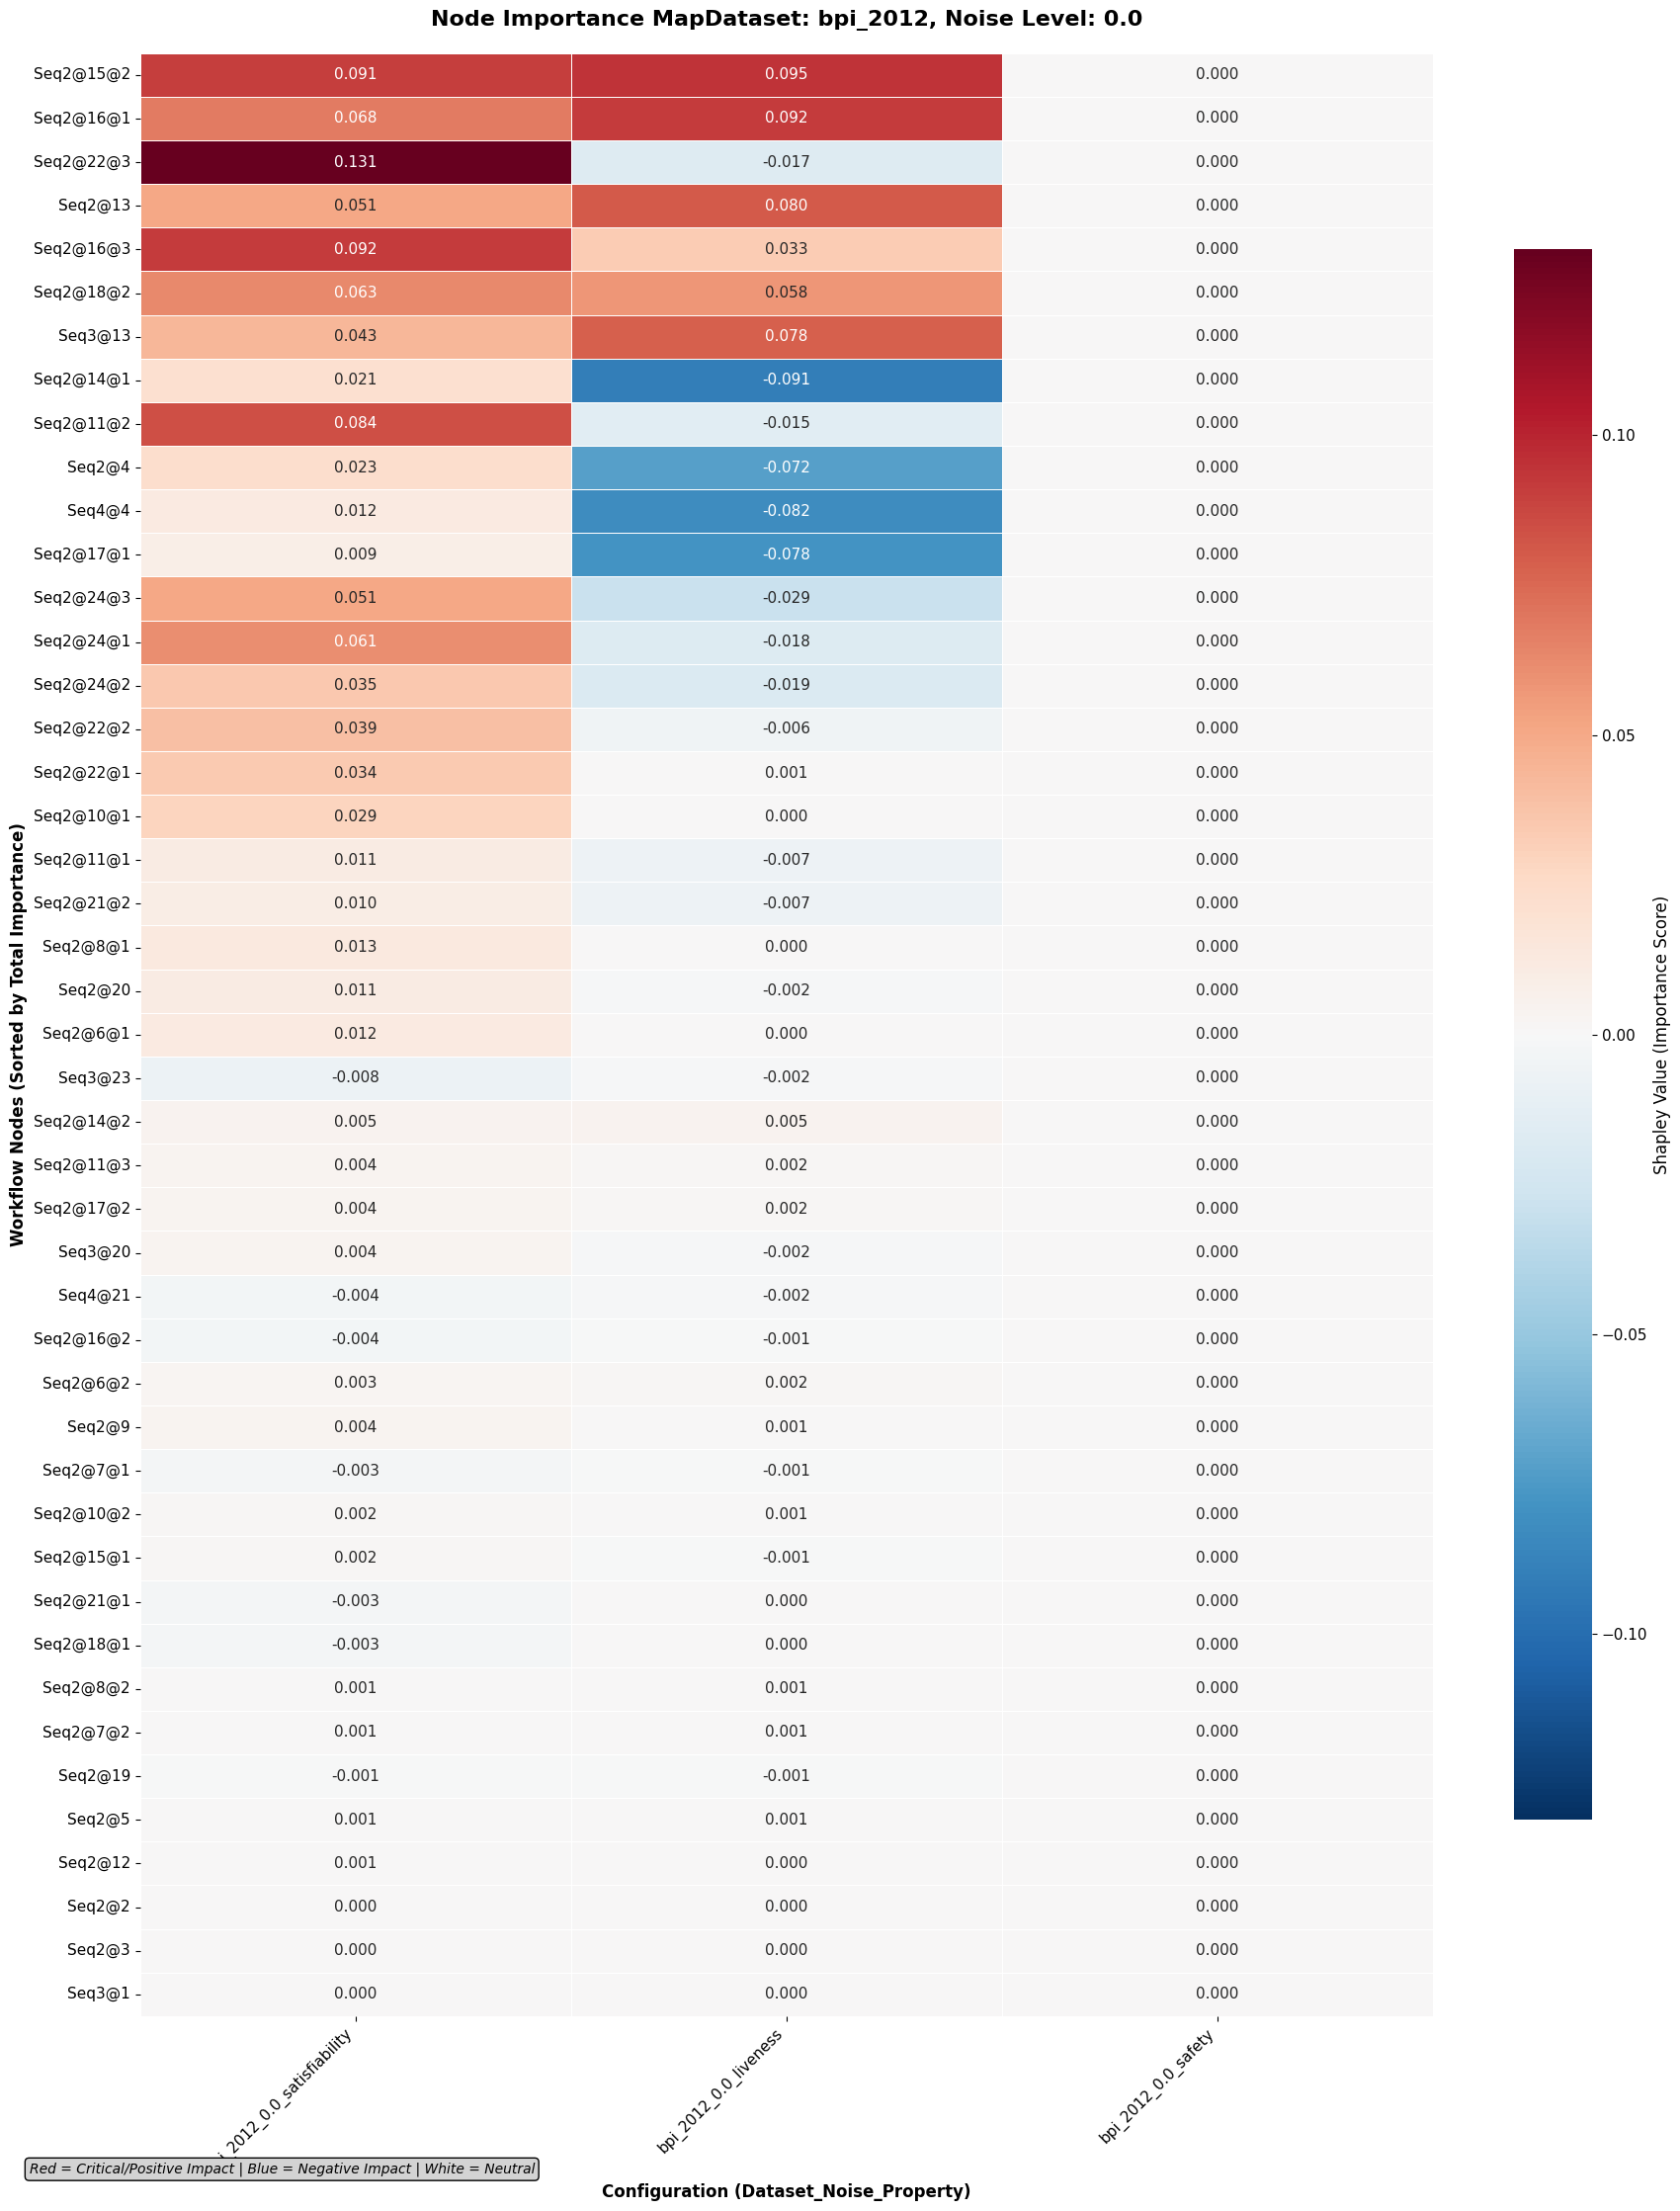

Analysis summary:
Nodes analyzed: 45
Configurations: 3
Most critical node: Seq2@15@2
Least critical node: Seq2@2
Importance -> spec:
   • satisfiability: 0.023 (Medium importance)
   • liveness: 0.020 (Medium importance)
   • safety: 0.000 (Medium importance)
\nAnalysis for dataset: HOSPITAL_BILLING
Importance map - hospital_billing (no noise)


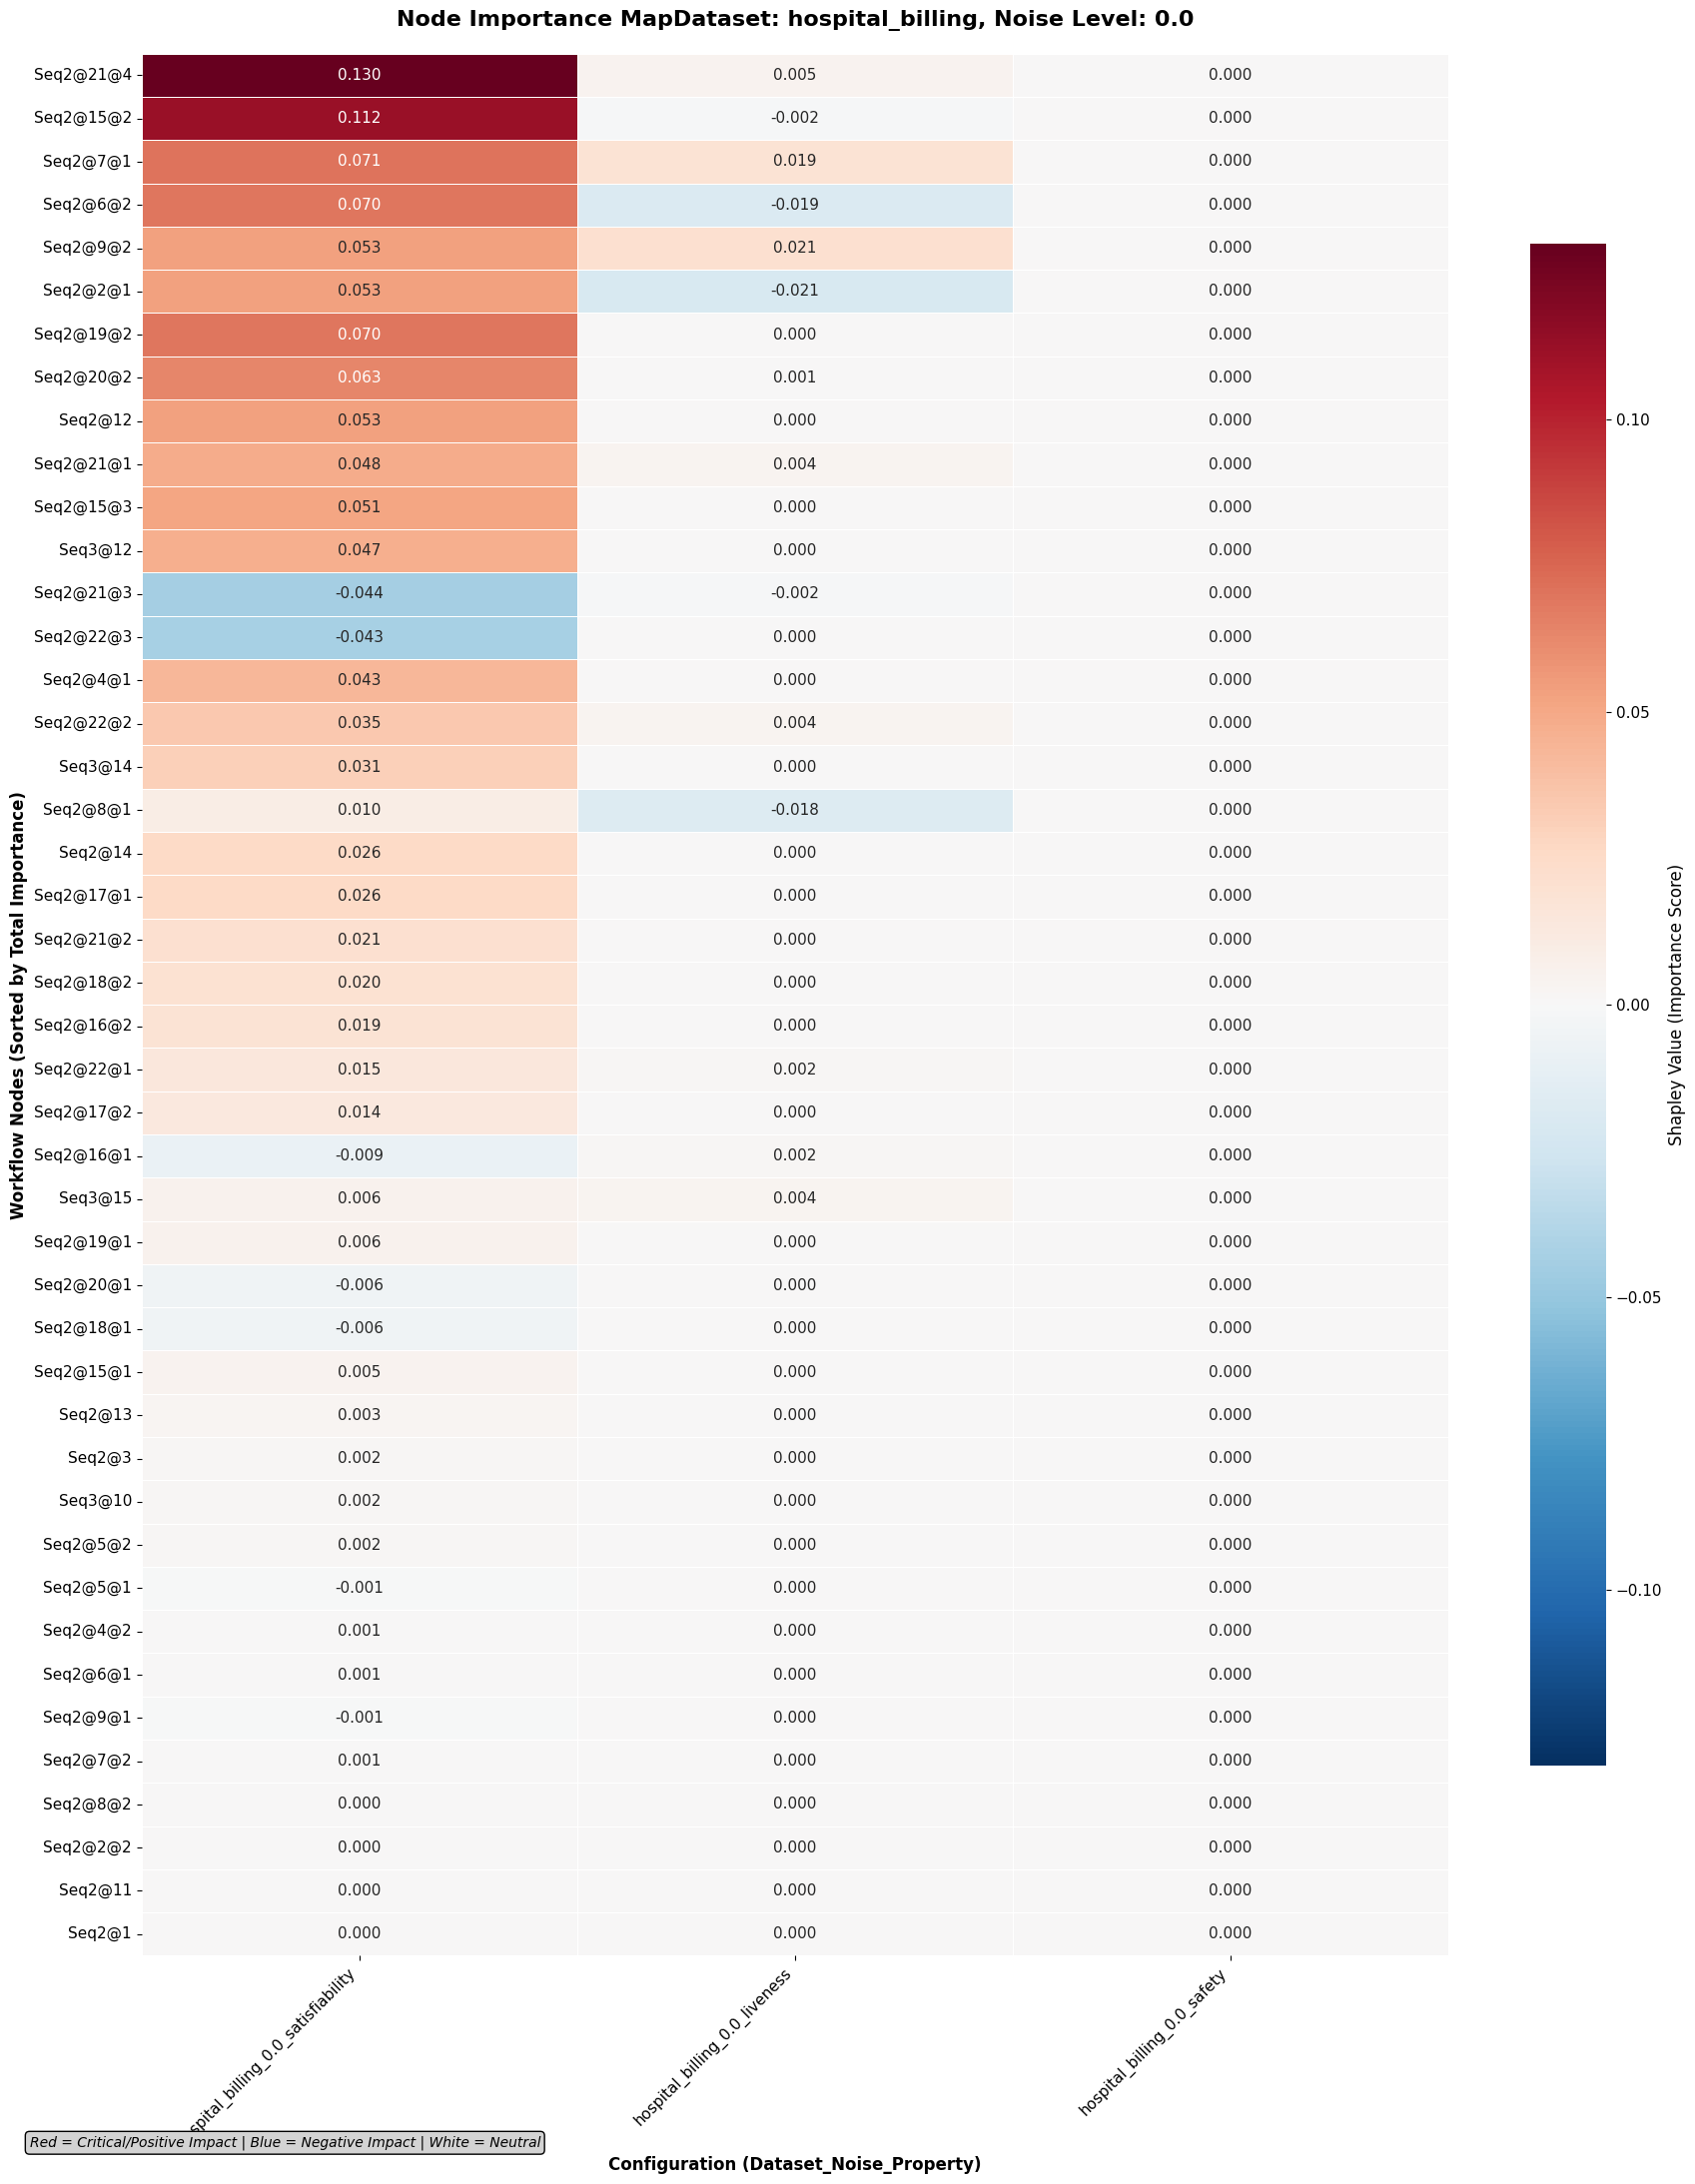

Analysis summary:
Nodes analyzed: 44
Configurations: 3
Most critical node: Seq2@21@4
Least critical node: Seq2@8@2
Importance -> spec:
   • satisfiability: 0.028 (Medium importance)
   • liveness: 0.003 (Medium importance)
   • safety: 0.000 (Medium importance)
\nAnalysis for dataset: RUNNING_EXAMPLE
Importance map - running_example (no noise)


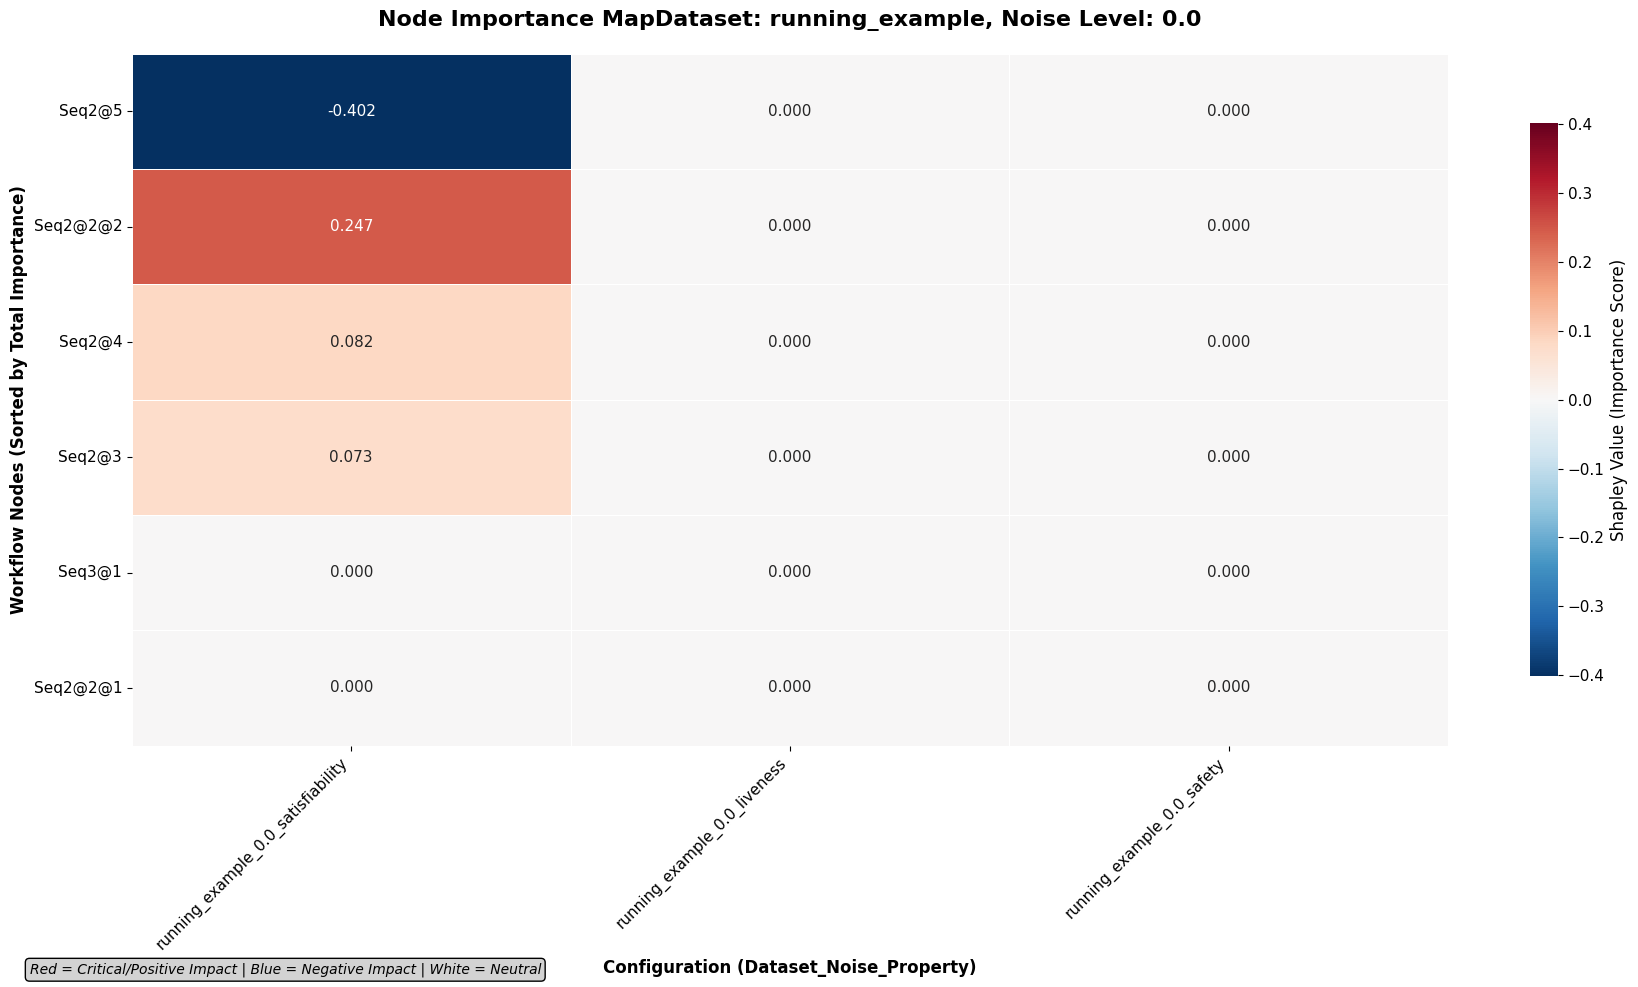

Analysis summary:
Nodes analyzed: 6
Configurations: 3
Most critical node: Seq2@5
Least critical node: Seq3@1
Importance -> spec:
   • satisfiability: 0.134 (Medium importance)
   • liveness: 0.000 (Medium importance)
   • safety: 0.000 (Medium importance)
Importance maps - noise impact
------------------------------------------------------------
\nAnalysis for noise level: 0.0
Importance map - all datasets (noise = 0.0)


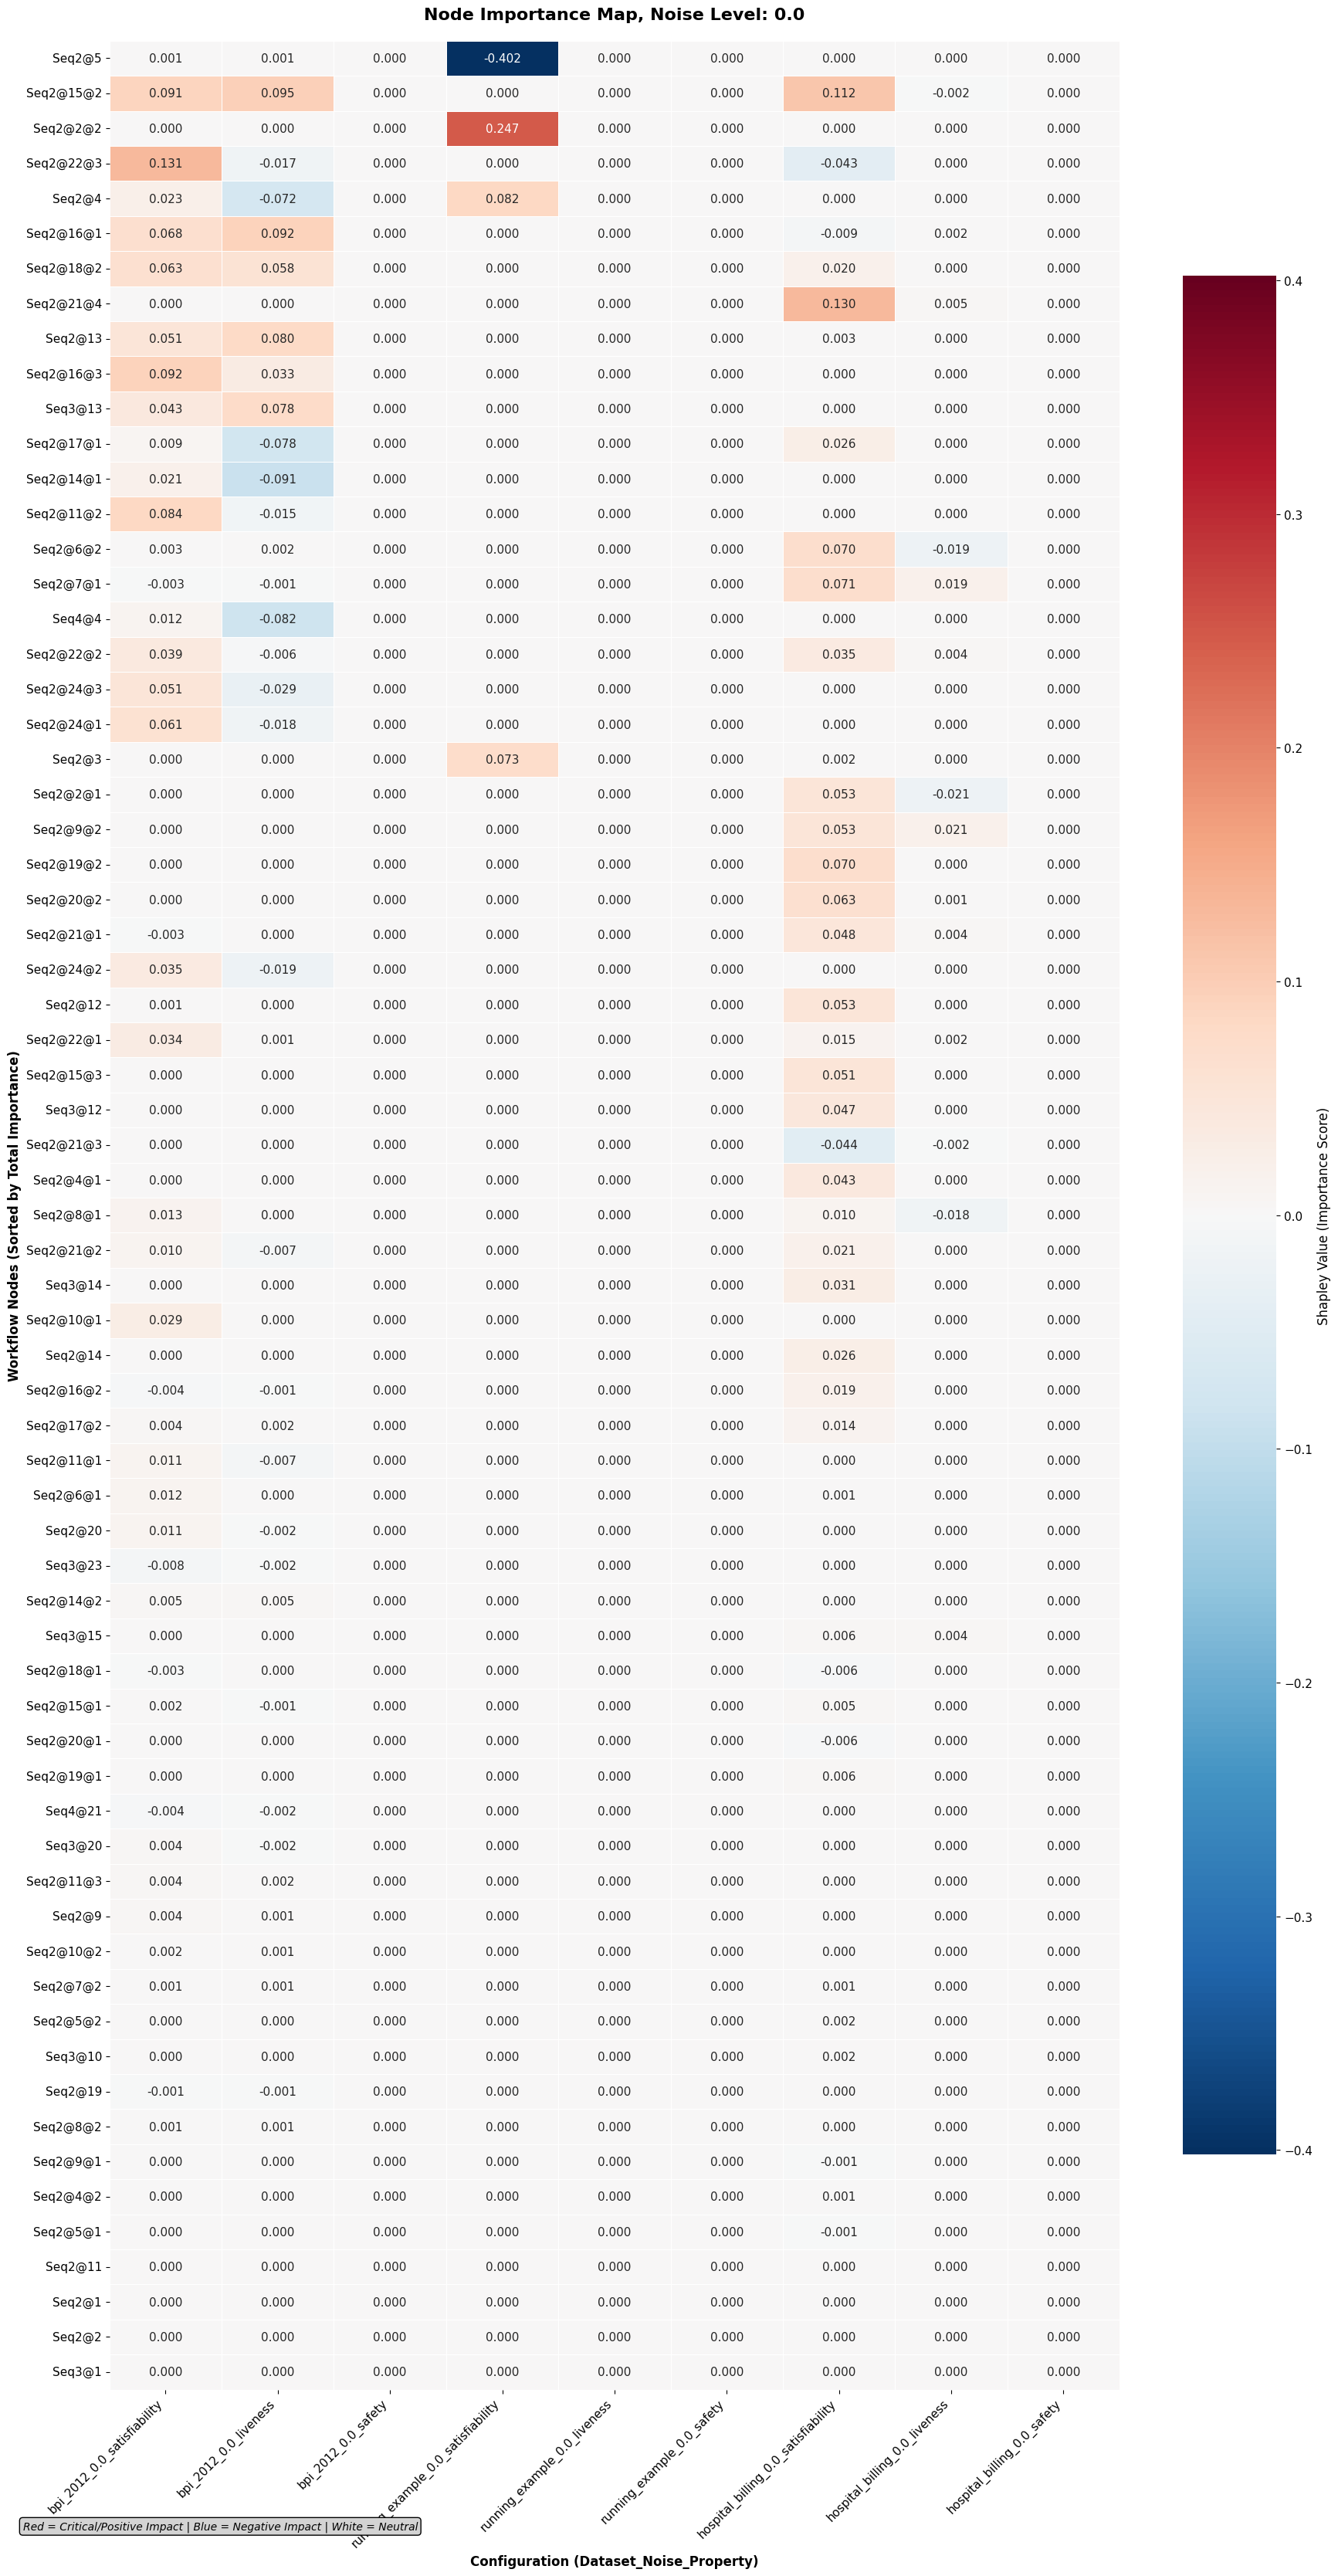

Analysis summary:
Nodes analyzed: 67
Configurations: 9
Most critical node: Seq2@5
Least critical node: Seq2@11
Importance -> spec:
   • satisfiability: 0.015 (Medium importance)
   • liveness: 0.005 (Medium importance)
   • safety: 0.000 (Medium importance)
\nAnalysis for noise level: 0.25
Importance map - all datasets (noise = 0.25)


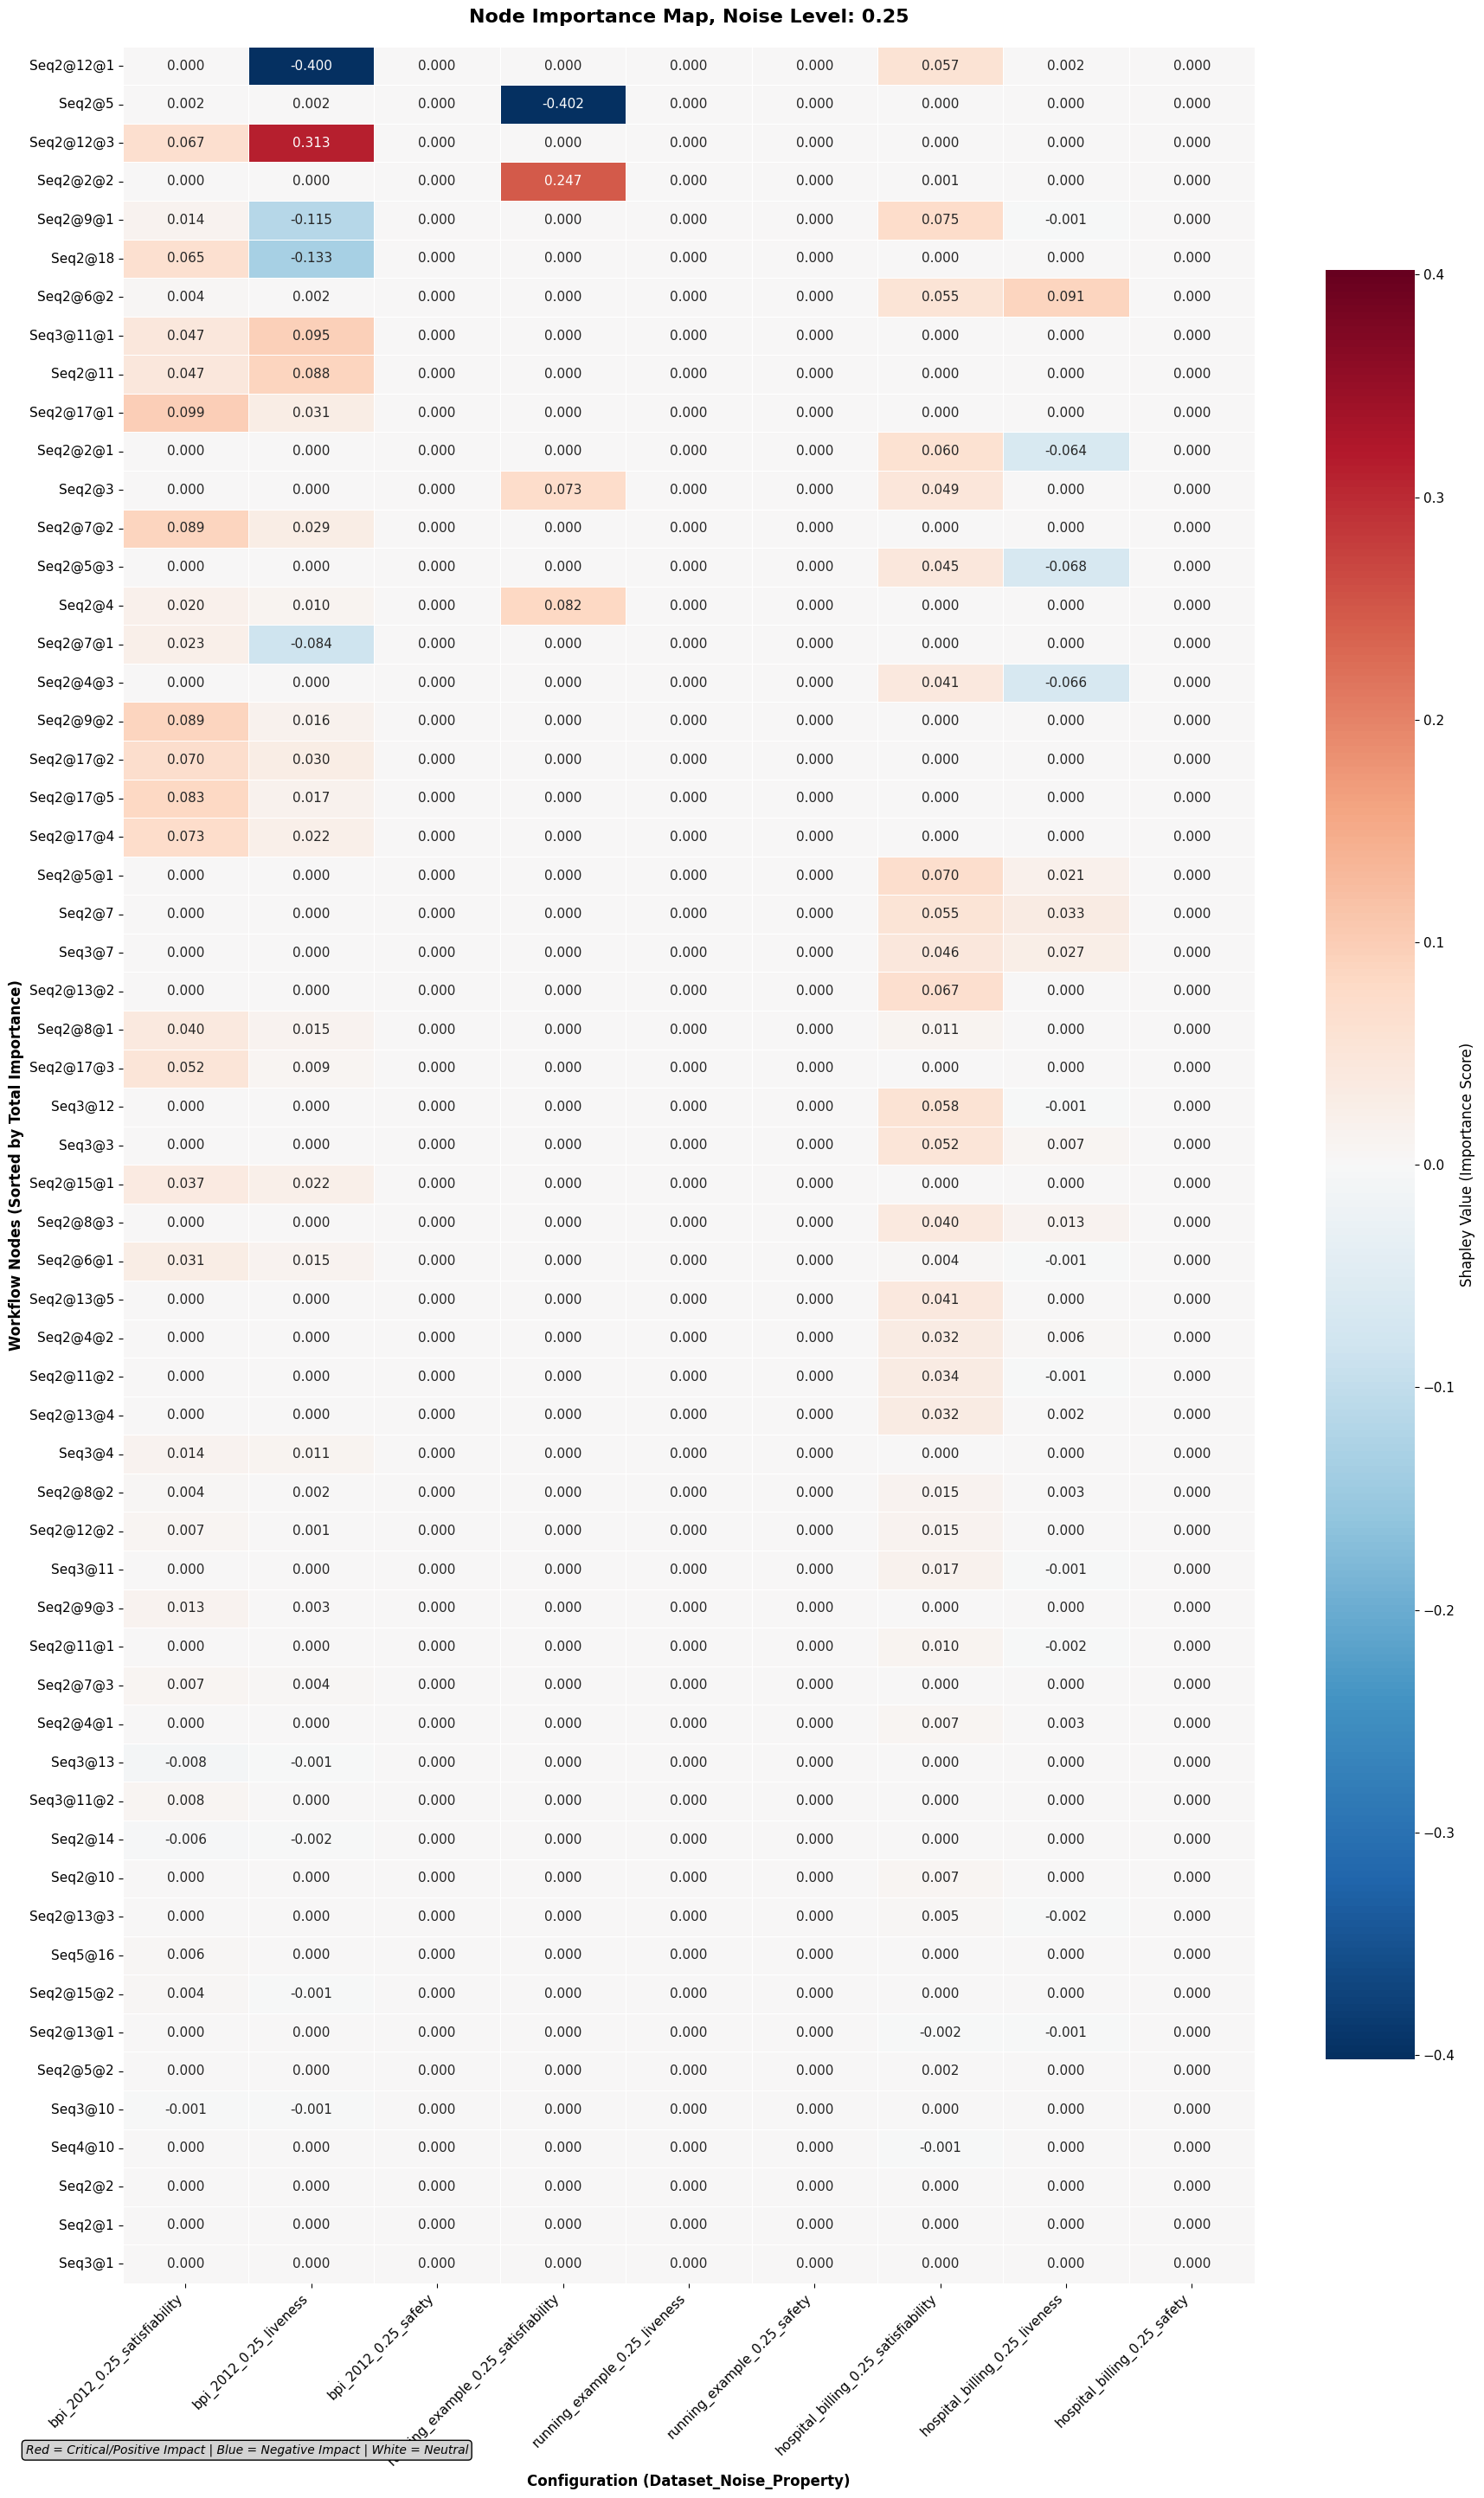

Analysis summary:
Nodes analyzed: 58
Configurations: 9
Most critical node: Seq2@12@1
Least critical node: Seq2@2
Importance -> spec:
   • satisfiability: 0.016 (Medium importance)
   • liveness: 0.011 (Medium importance)
   • safety: 0.000 (Medium importance)
\nAnalysis for noise level: 0.5
Importance map - all datasets (noise = 0.5)


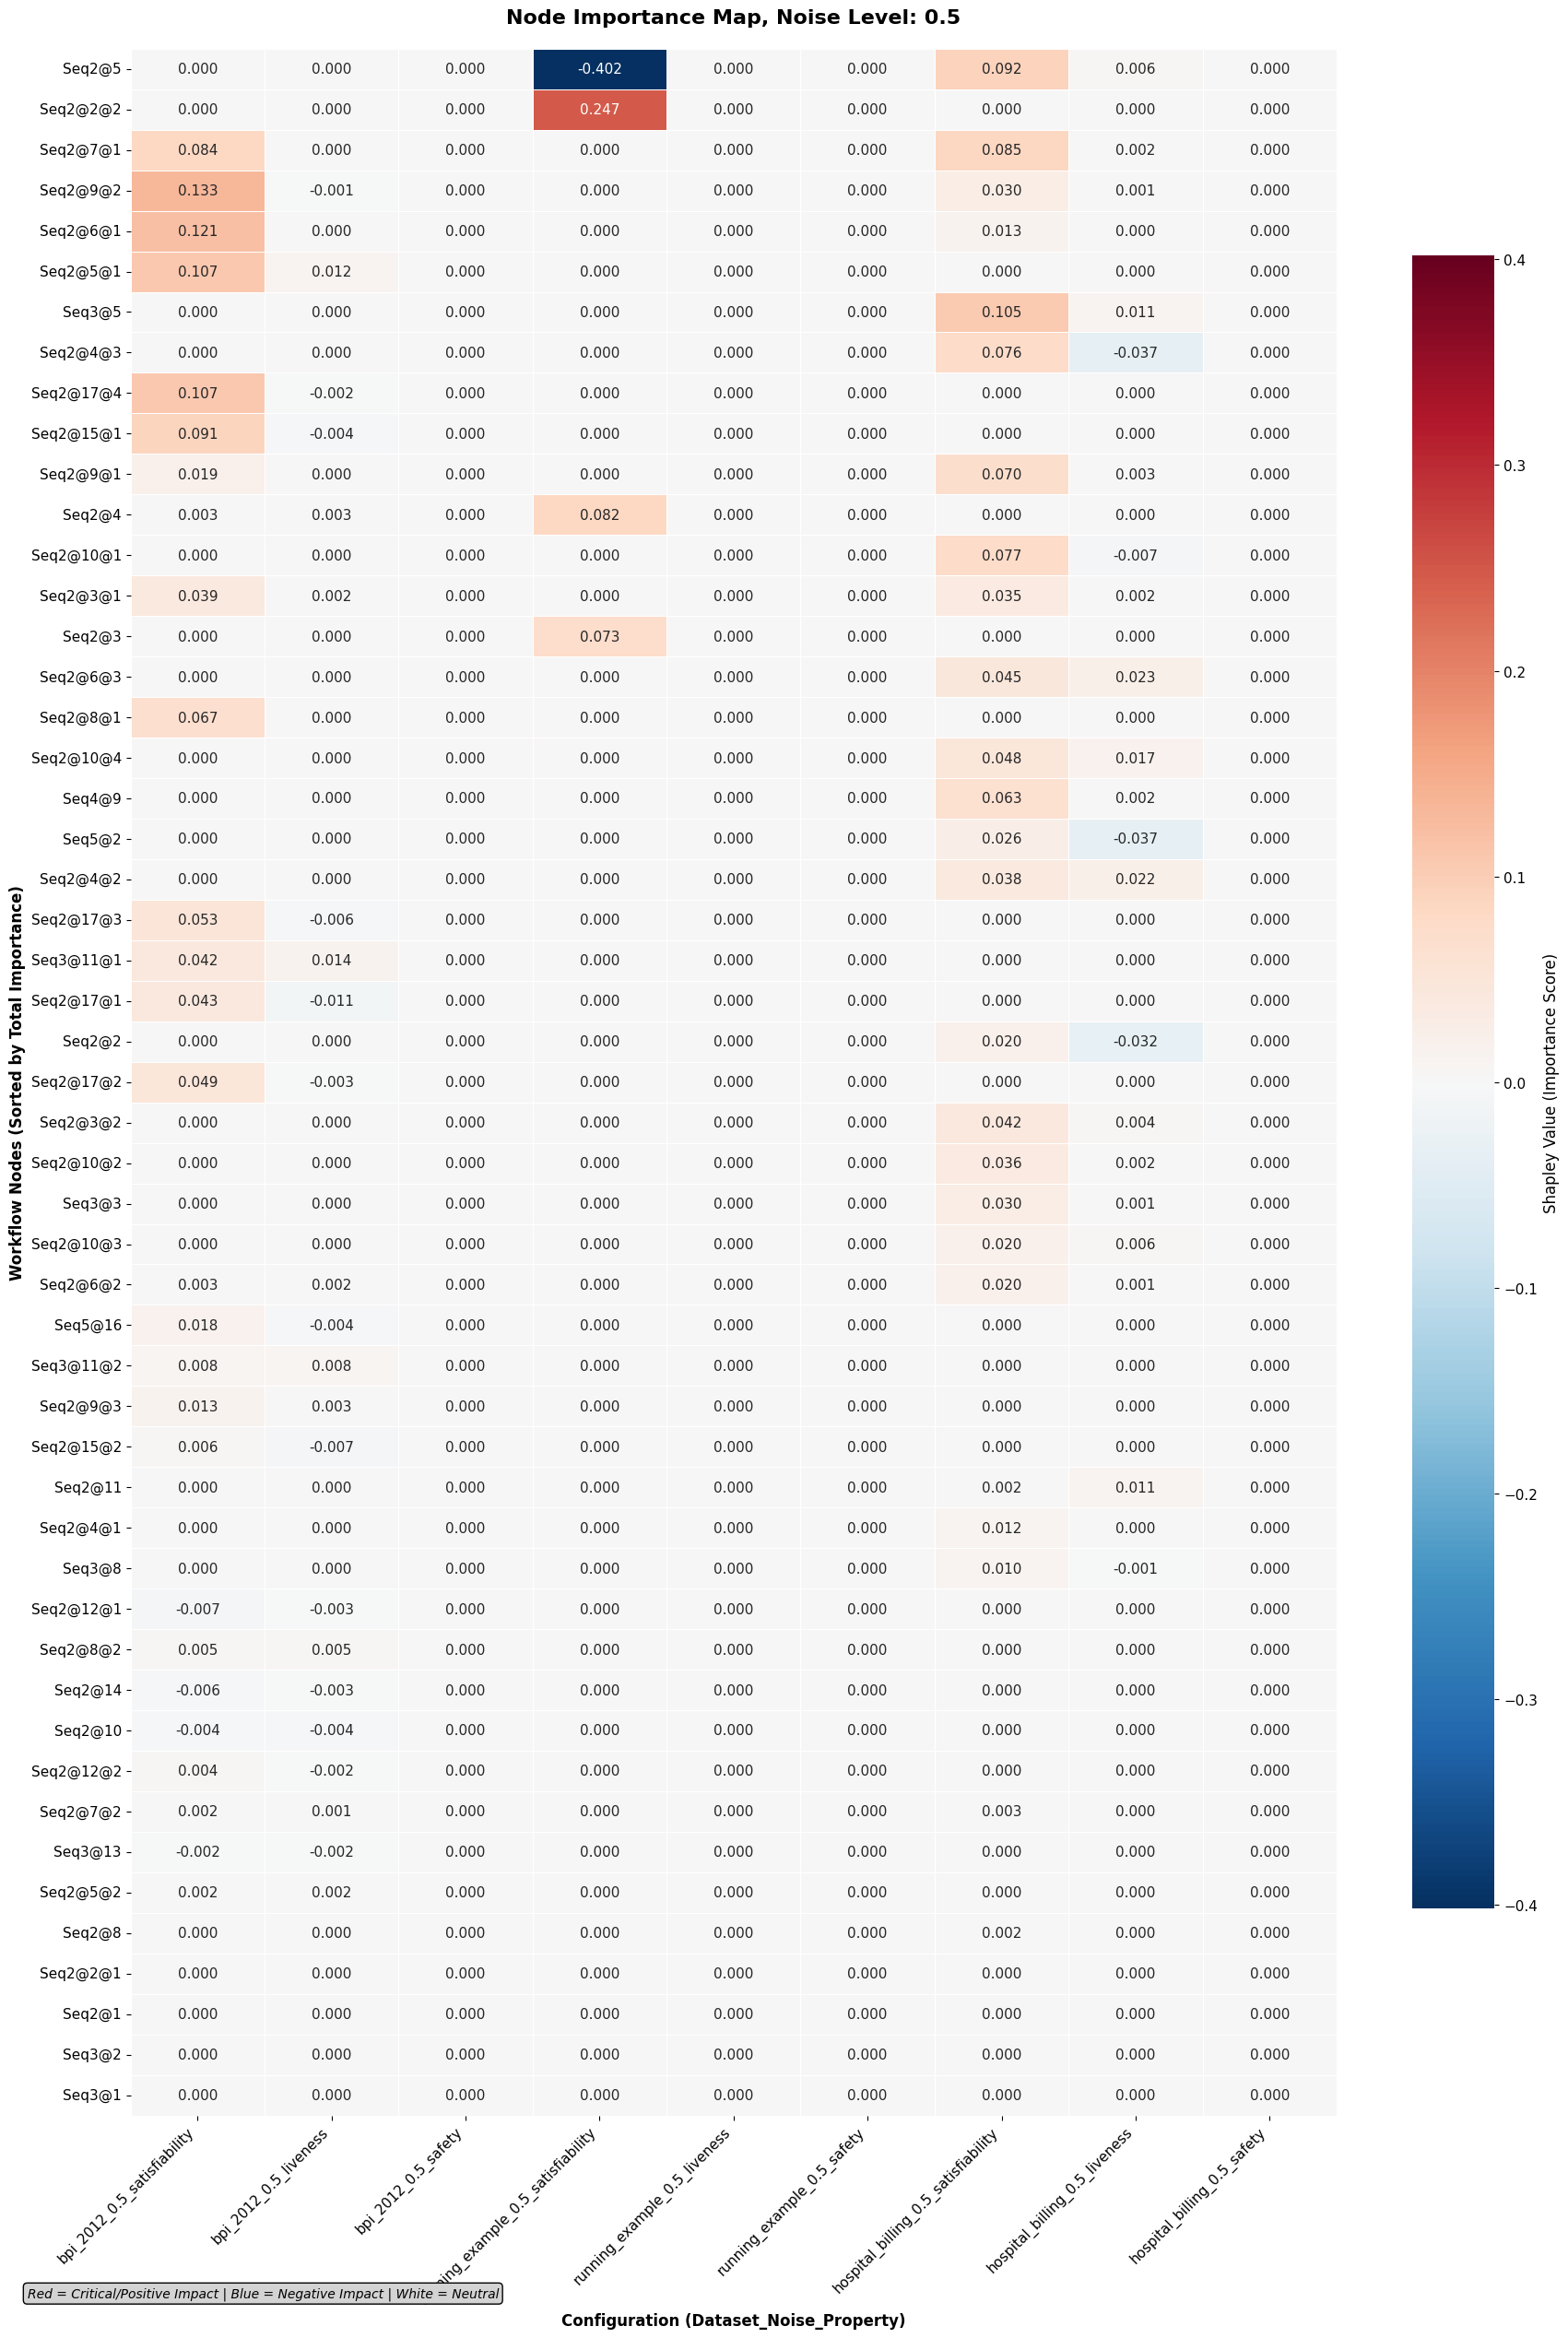

Analysis summary:
Nodes analyzed: 51
Configurations: 9
Most critical node: Seq2@5
Least critical node: Seq2@2@1
Importance -> spec:
   • satisfiability: 0.019 (Medium importance)
   • liveness: 0.002 (Medium importance)
   • safety: 0.000 (Medium importance)
\nAnalysis for noise level: 1.0
Importance map - all datasets (noise = 1.0)


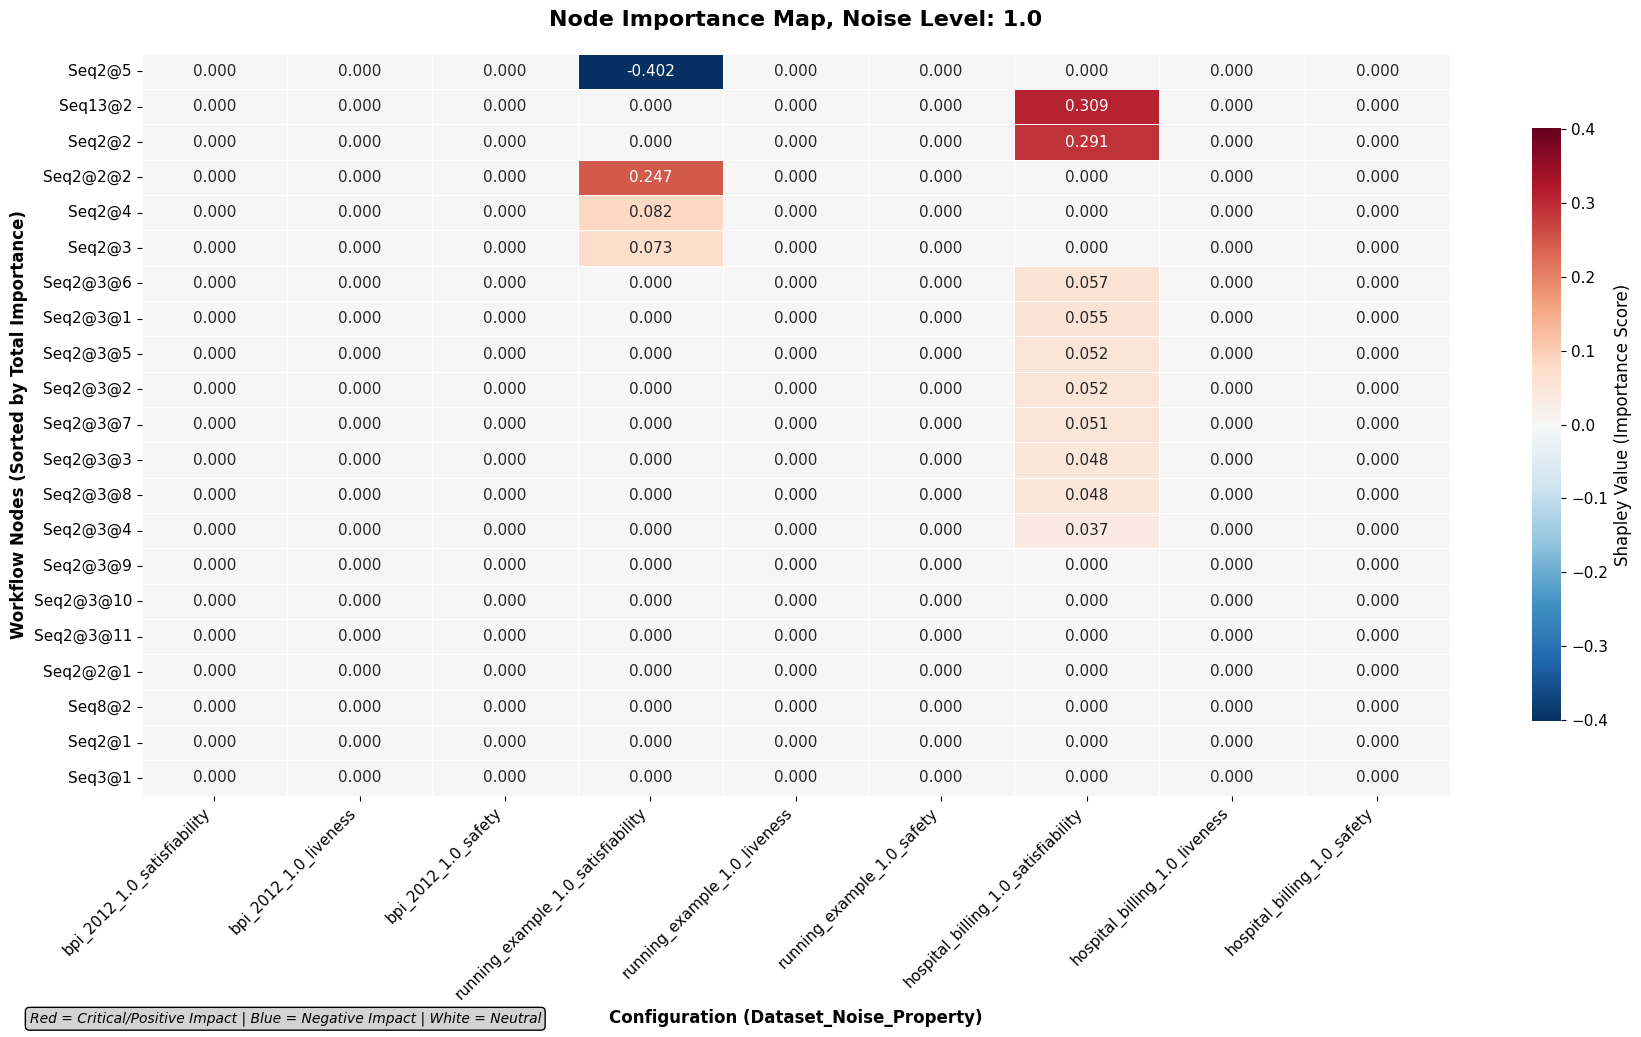

Analysis summary:
Nodes analyzed: 21
Configurations: 9
Most critical node: Seq2@5
Least critical node: Seq2@3@9
Importance -> spec:
   • satisfiability: 0.029 (Medium importance)
   • liveness: 0.000 (Medium importance)
   • safety: 0.000 (Medium importance)
Importance maps - all combinations
------------------------------------------------------------
\nCombination 1: BPI_2012 + NOISE 0.0
Detailed importance map - bpi_2012 (noise = 0.0)


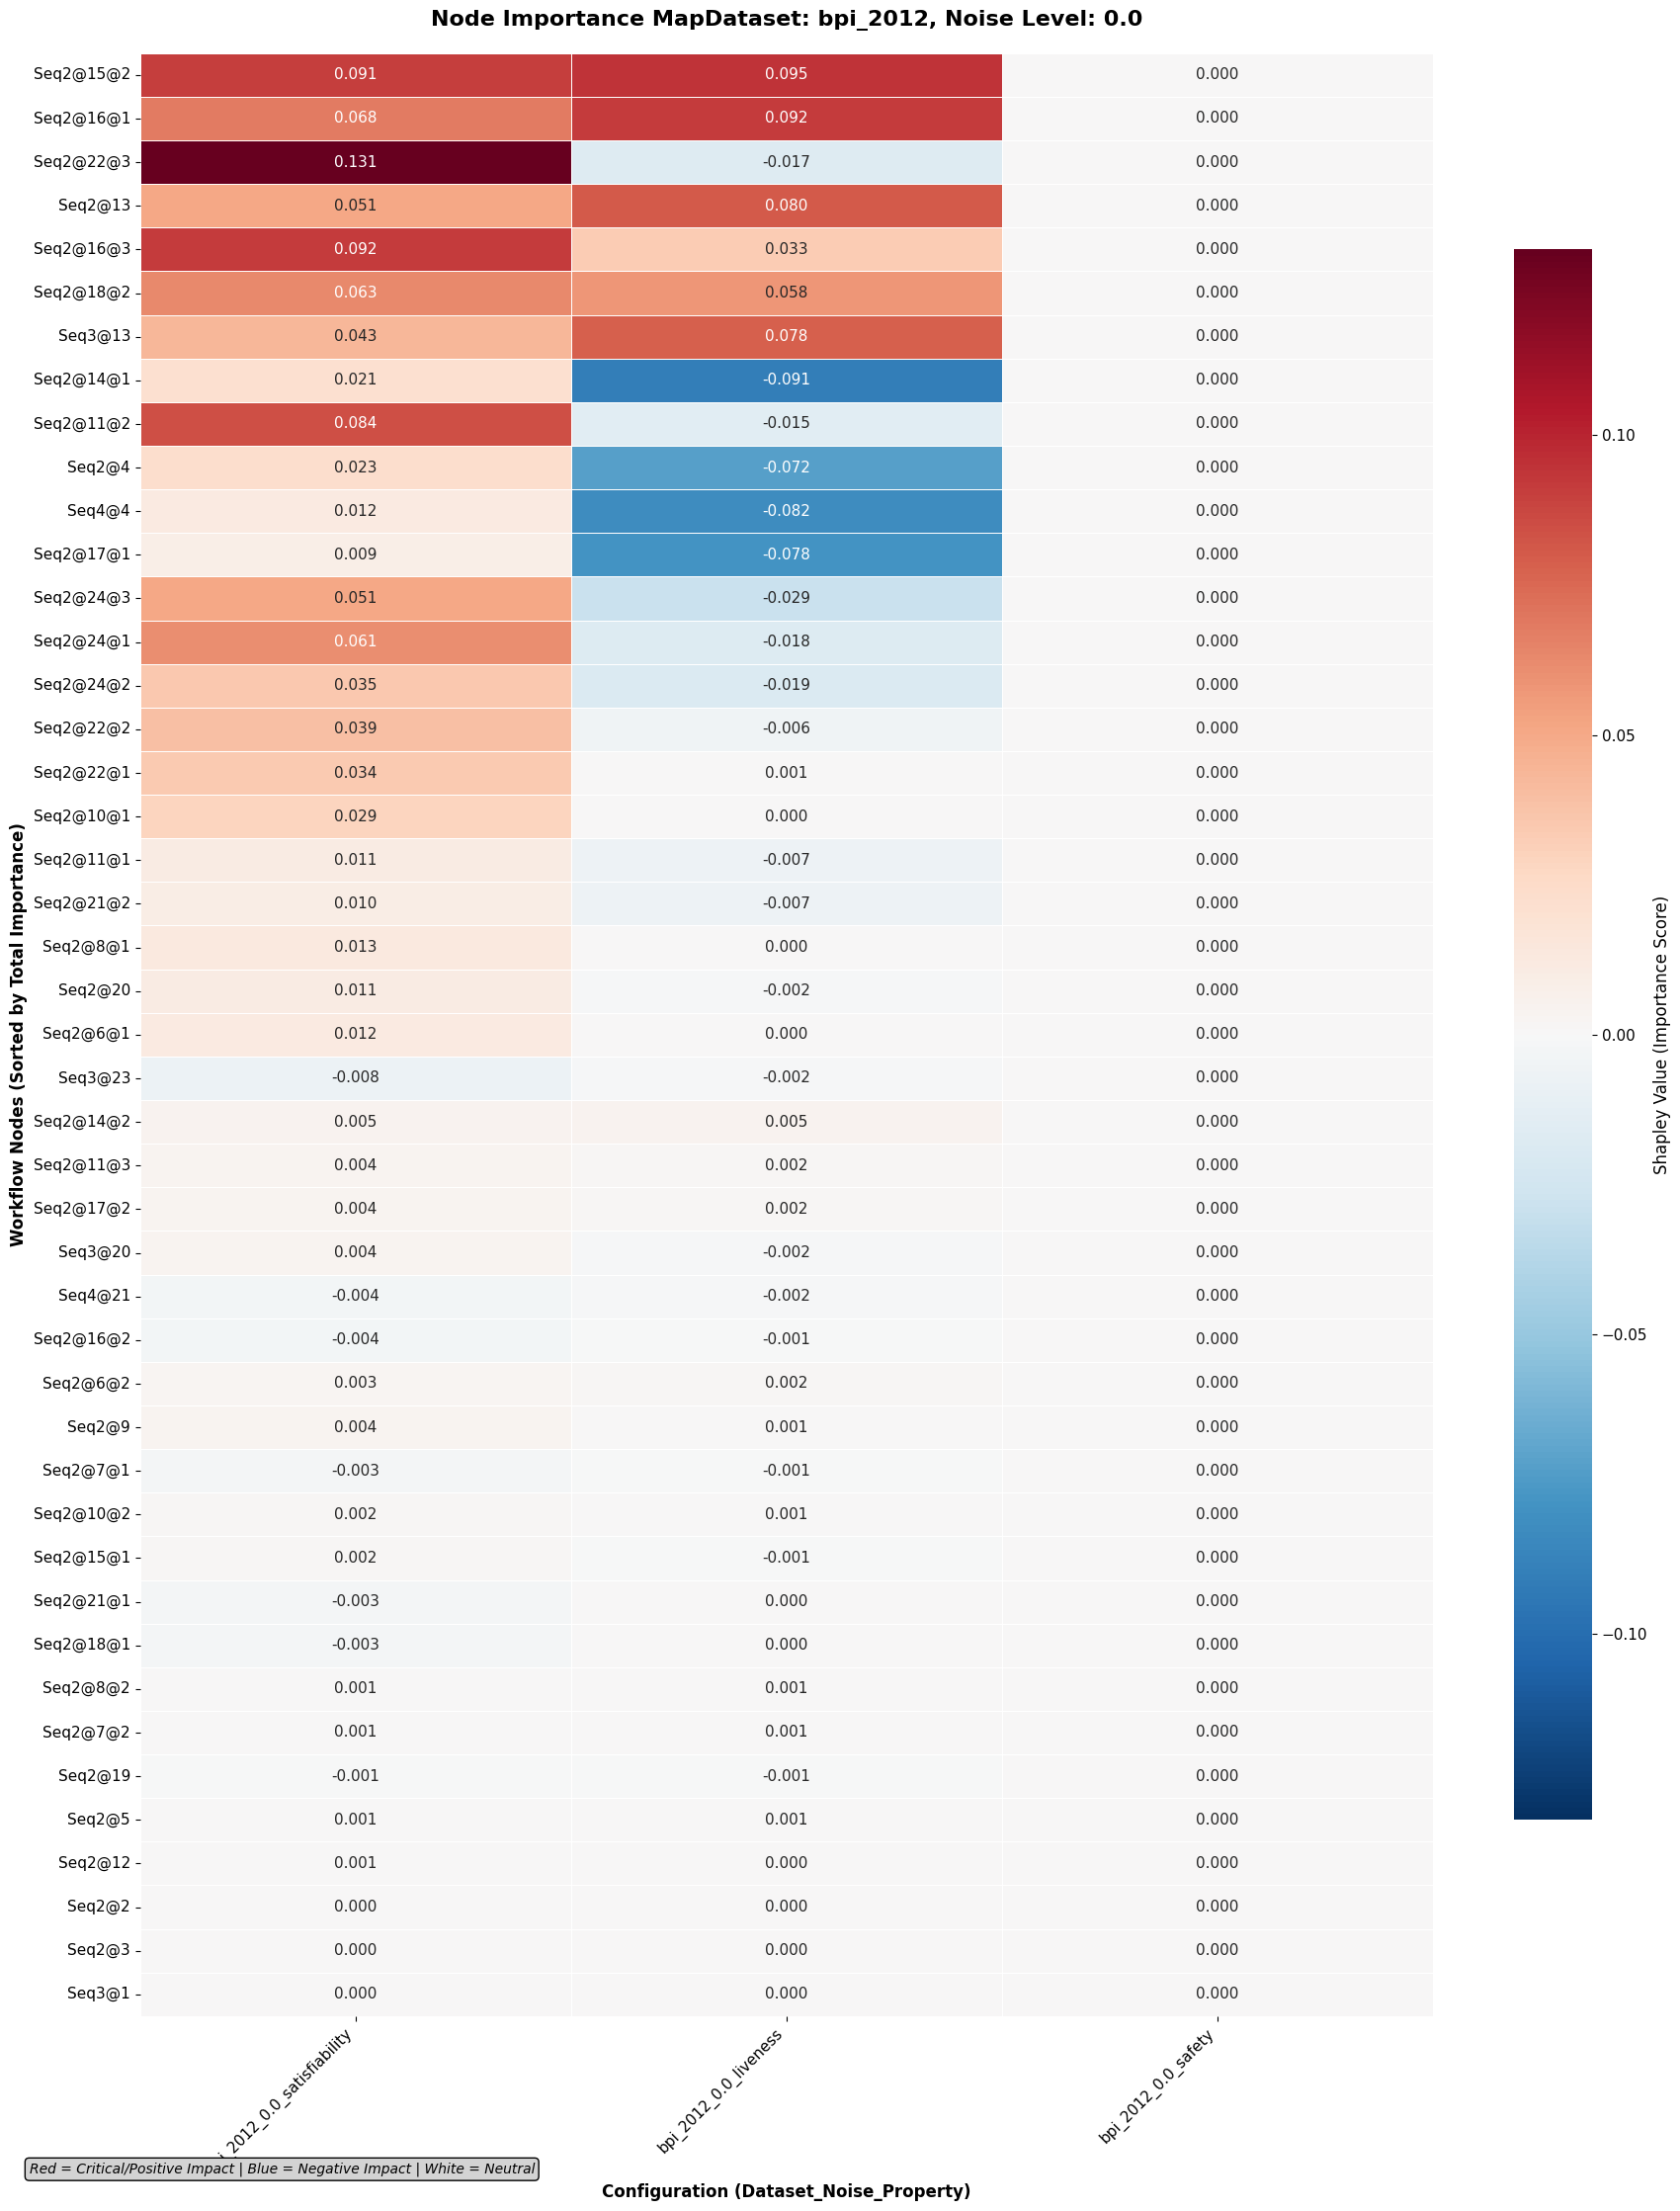

Analysis summary:
Nodes analyzed: 45
Configurations: 3
Most critical node: Seq2@15@2
Least critical node: Seq2@2
Importance -> spec:
   • satisfiability: 0.023 (Medium importance)
   • liveness: 0.020 (Medium importance)
   • safety: 0.000 (Medium importance)
\nCombination 2: BPI_2012 + NOISE 0.25
Detailed importance map - bpi_2012 (noise = 0.25)


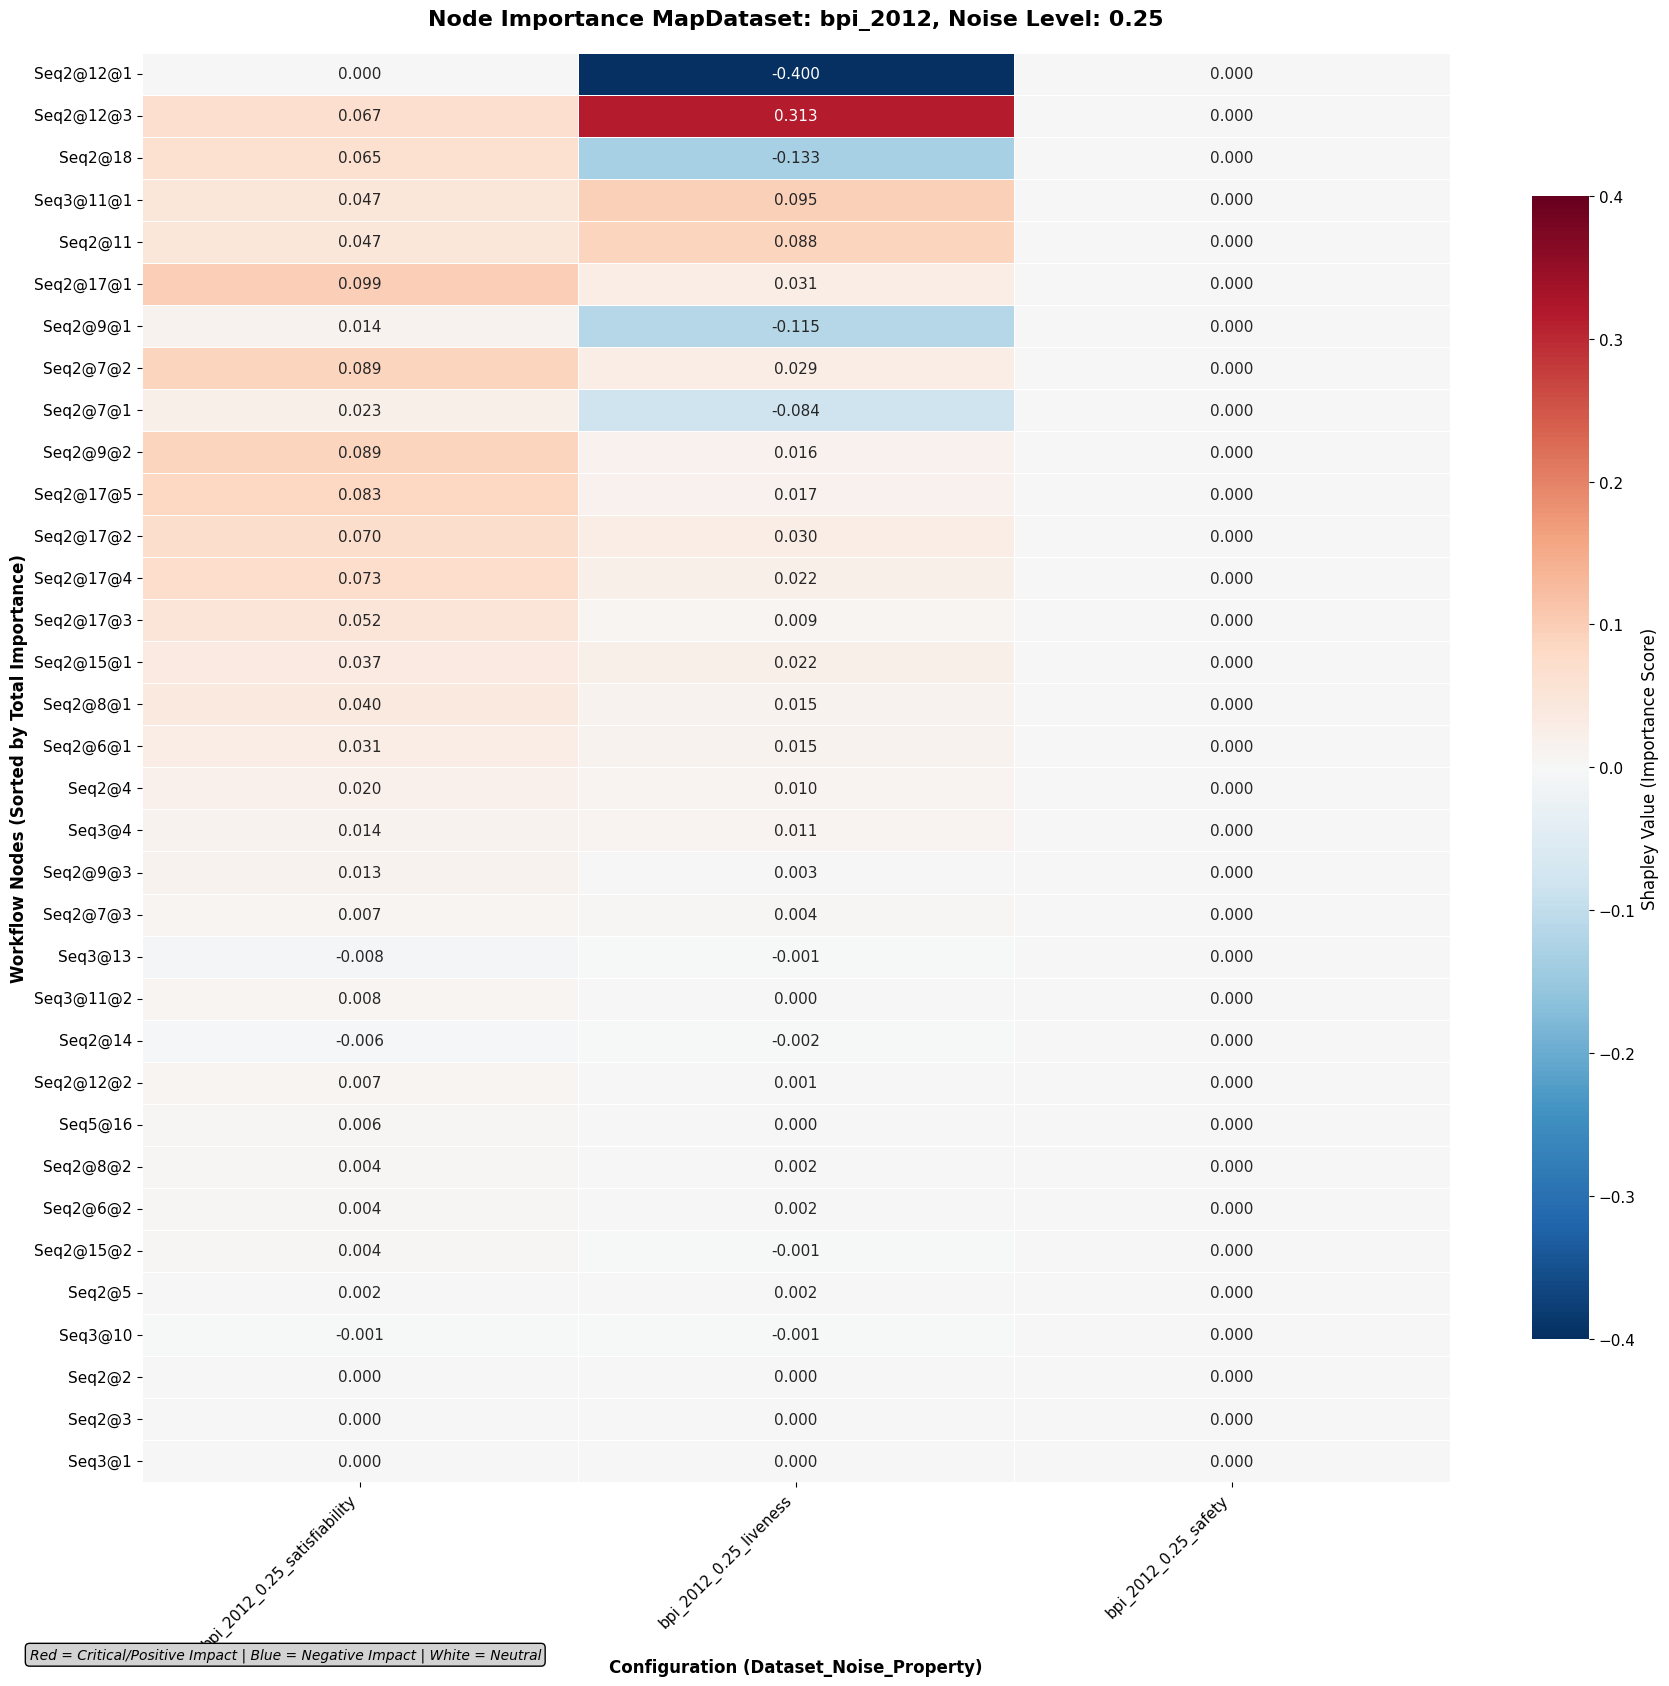

Analysis summary:
Nodes analyzed: 34
Configurations: 3
Most critical node: Seq2@12@1
Least critical node: Seq2@2
Importance -> spec:
   • satisfiability: 0.030 (Medium importance)
   • liveness: 0.043 (Medium importance)
   • safety: 0.000 (Medium importance)
\nCombination 3: BPI_2012 + NOISE 0.5
Detailed importance map - bpi_2012 (noise = 0.5)


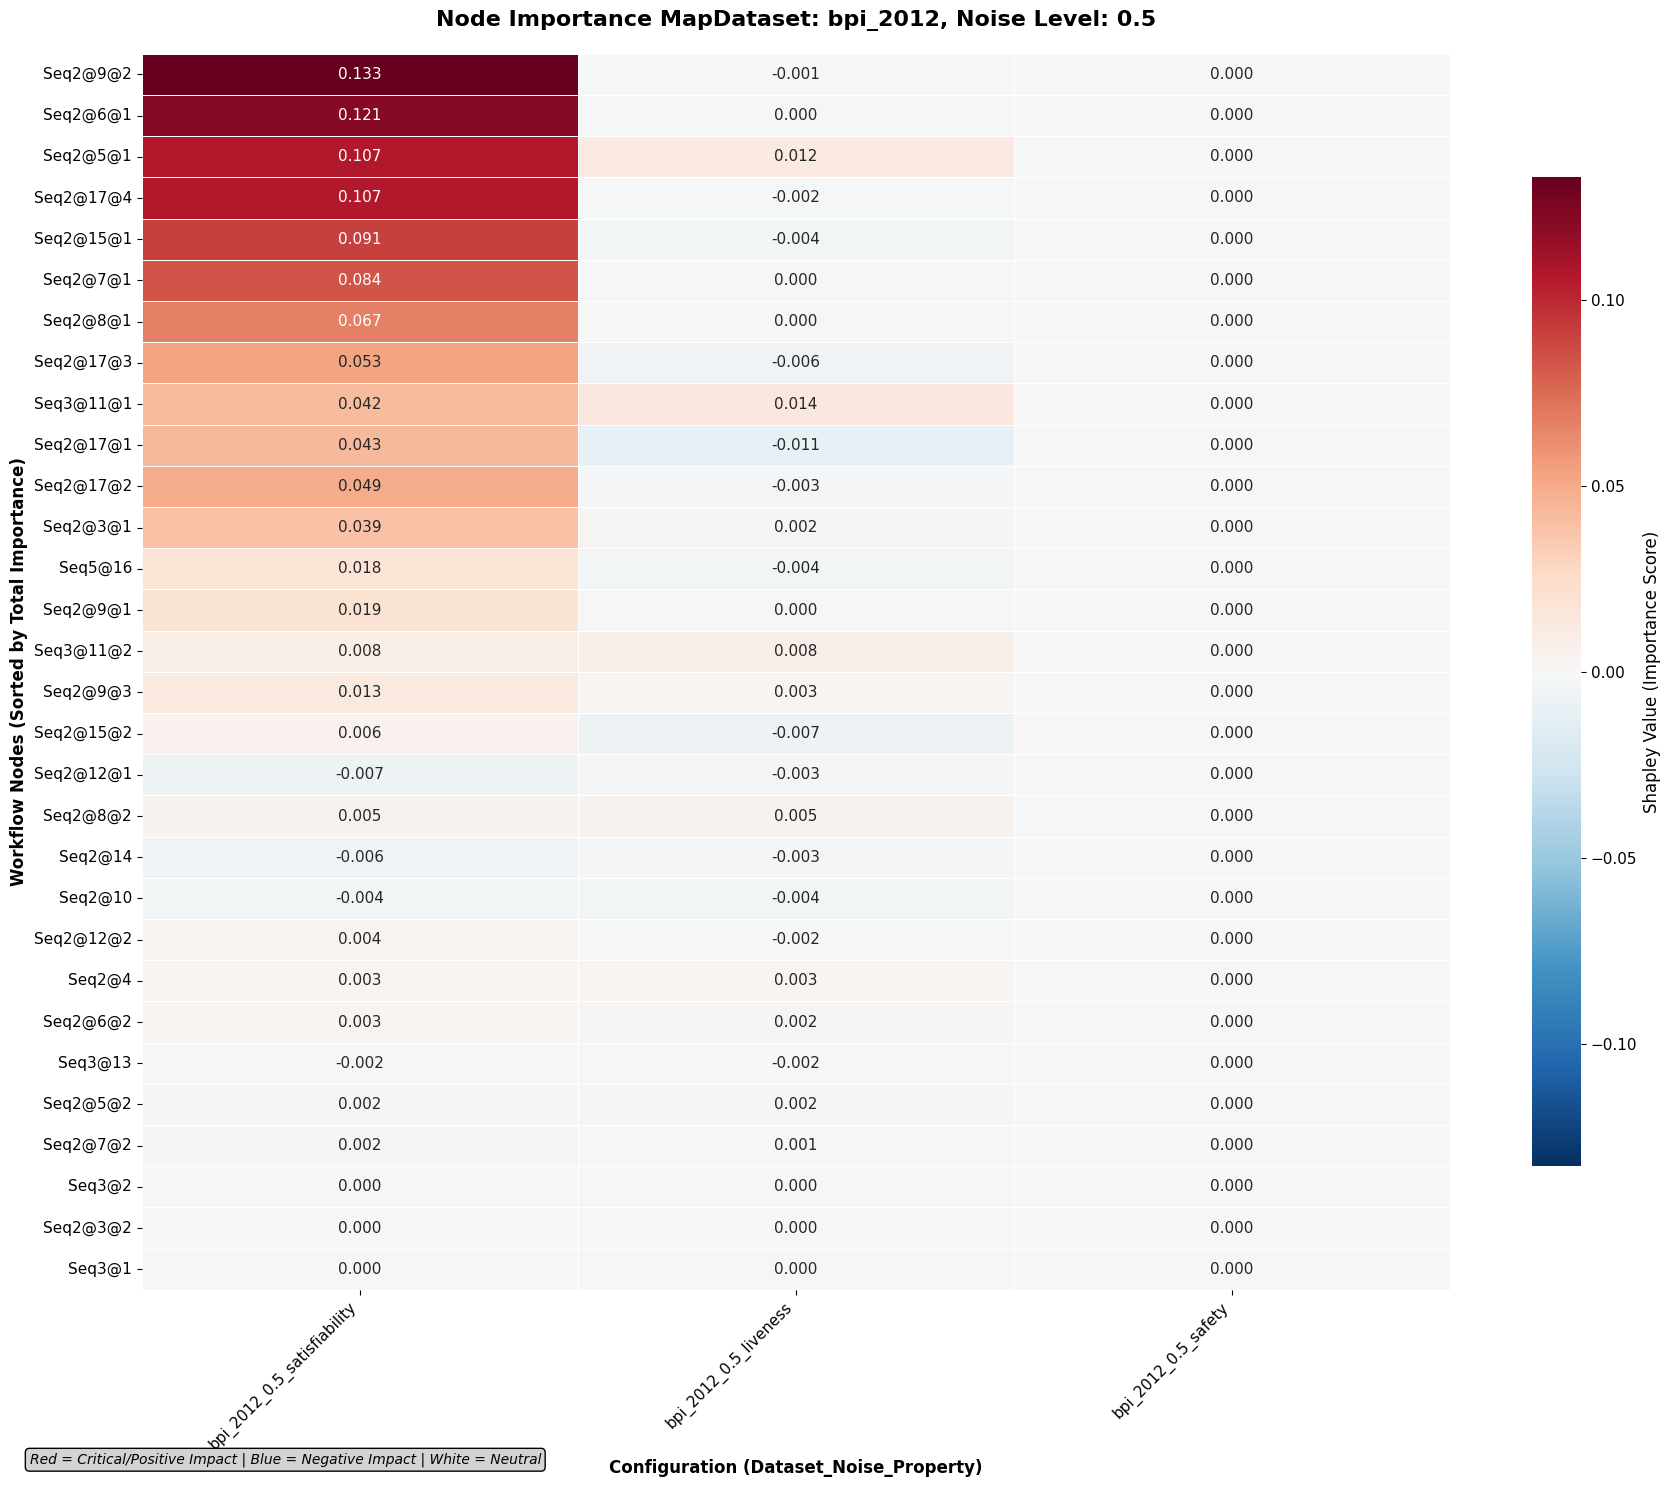

Analysis summary:
Nodes analyzed: 30
Configurations: 3
Most critical node: Seq2@9@2
Least critical node: Seq3@2
Importance -> spec:
   • satisfiability: 0.035 (Medium importance)
   • liveness: 0.003 (Medium importance)
   • safety: 0.000 (Medium importance)
\nCombination 4: BPI_2012 + NOISE 1.0
Detailed importance map - bpi_2012 (noise = 1.0)


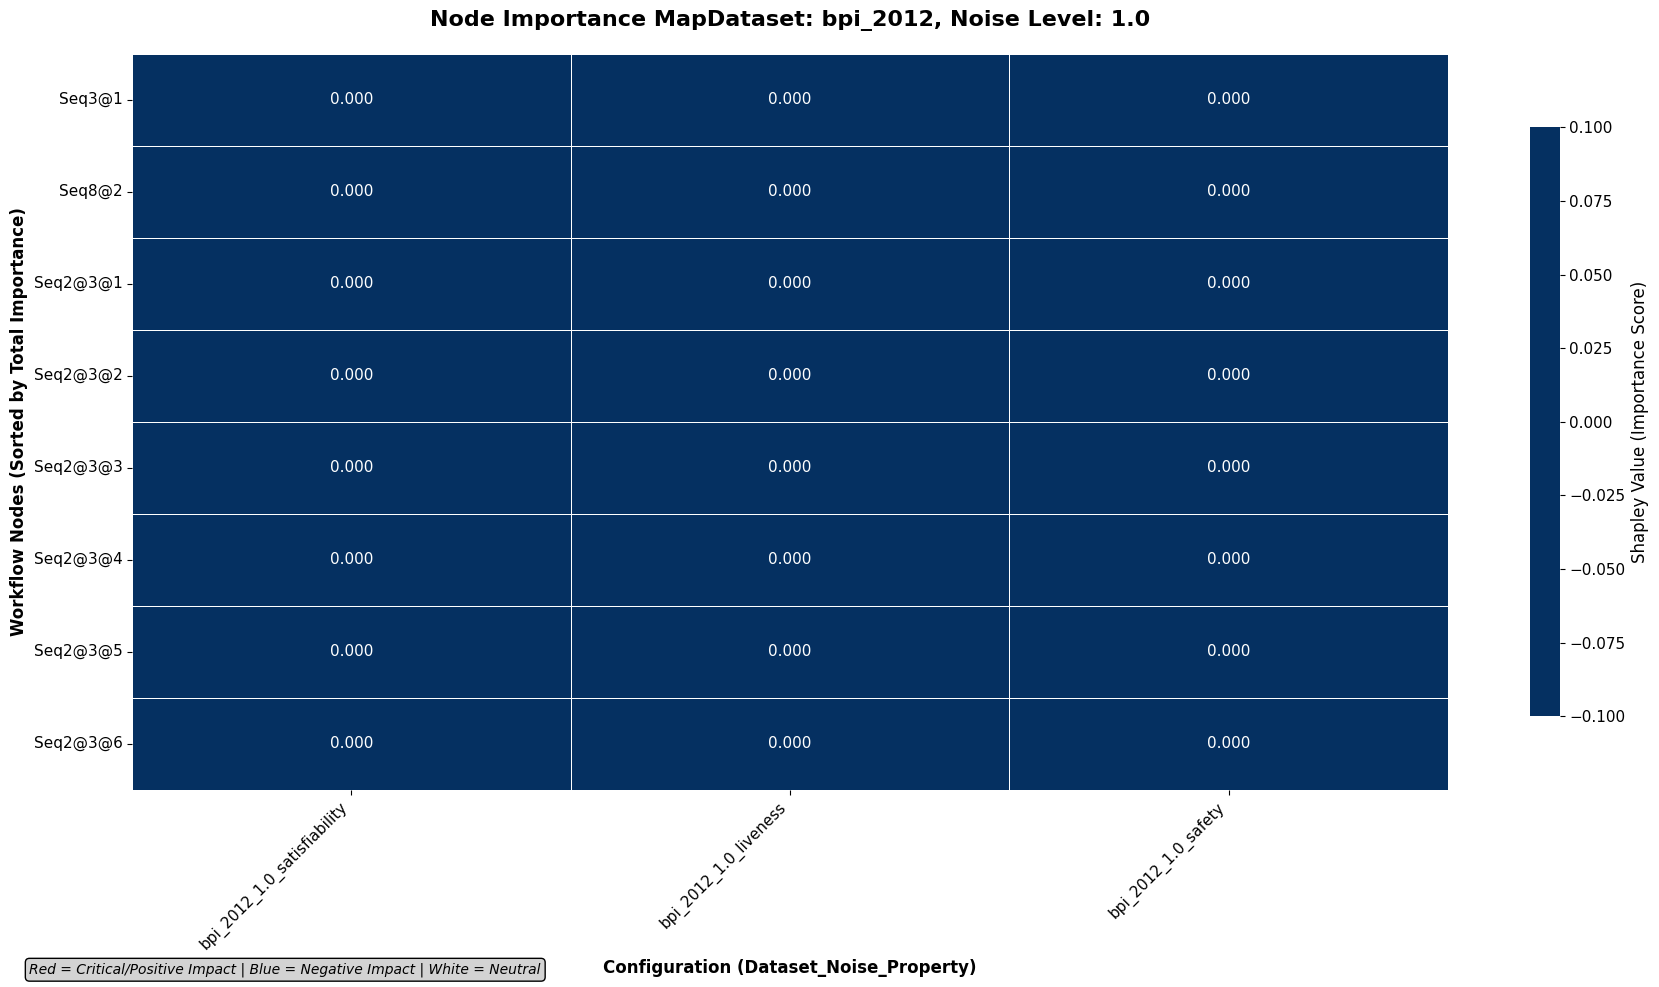

Analysis summary:
Nodes analyzed: 8
Configurations: 3
Most critical node: Seq3@1
Least critical node: Seq3@1
Importance -> spec:
   • satisfiability: 0.000 (Medium importance)
   • liveness: 0.000 (Medium importance)
   • safety: 0.000 (Medium importance)
\nCombination 5: HOSPITAL_BILLING + NOISE 0.0
Detailed importance map - hospital_billing (noise = 0.0)


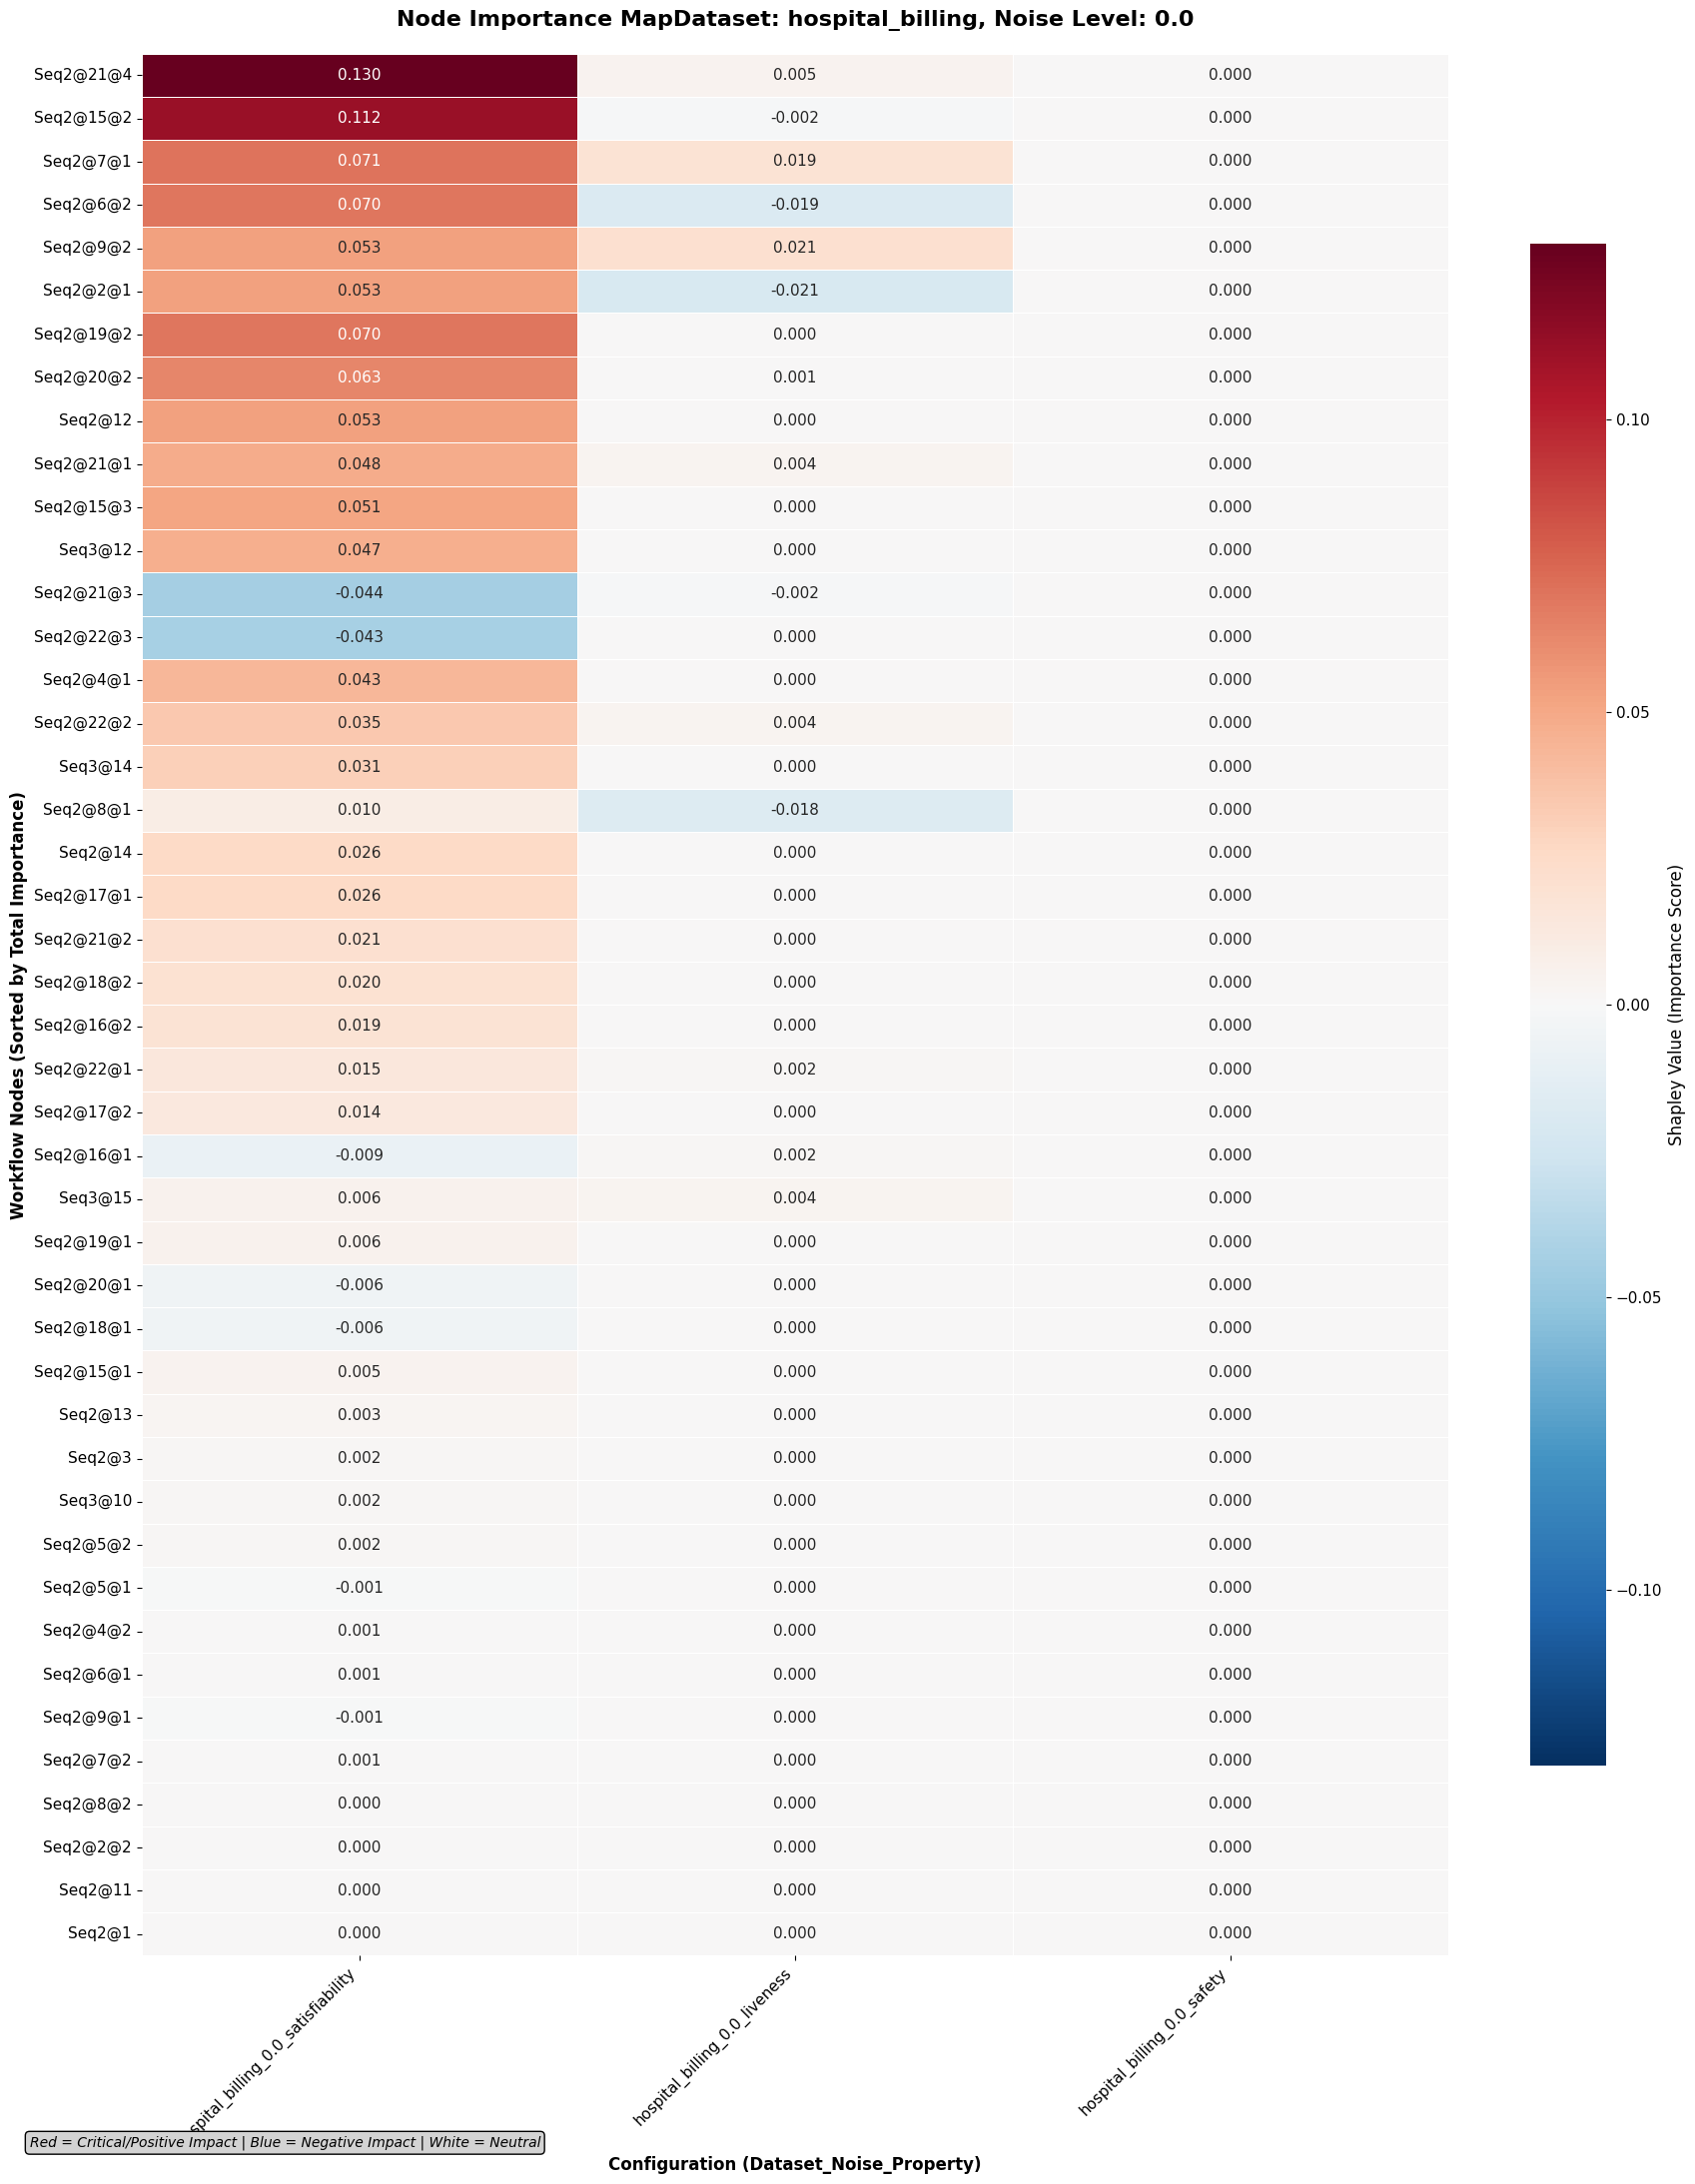

Analysis summary:
Nodes analyzed: 44
Configurations: 3
Most critical node: Seq2@21@4
Least critical node: Seq2@8@2
Importance -> spec:
   • satisfiability: 0.028 (Medium importance)
   • liveness: 0.003 (Medium importance)
   • safety: 0.000 (Medium importance)
\nCombination 6: HOSPITAL_BILLING + NOISE 0.25
Detailed importance map - hospital_billing (noise = 0.25)


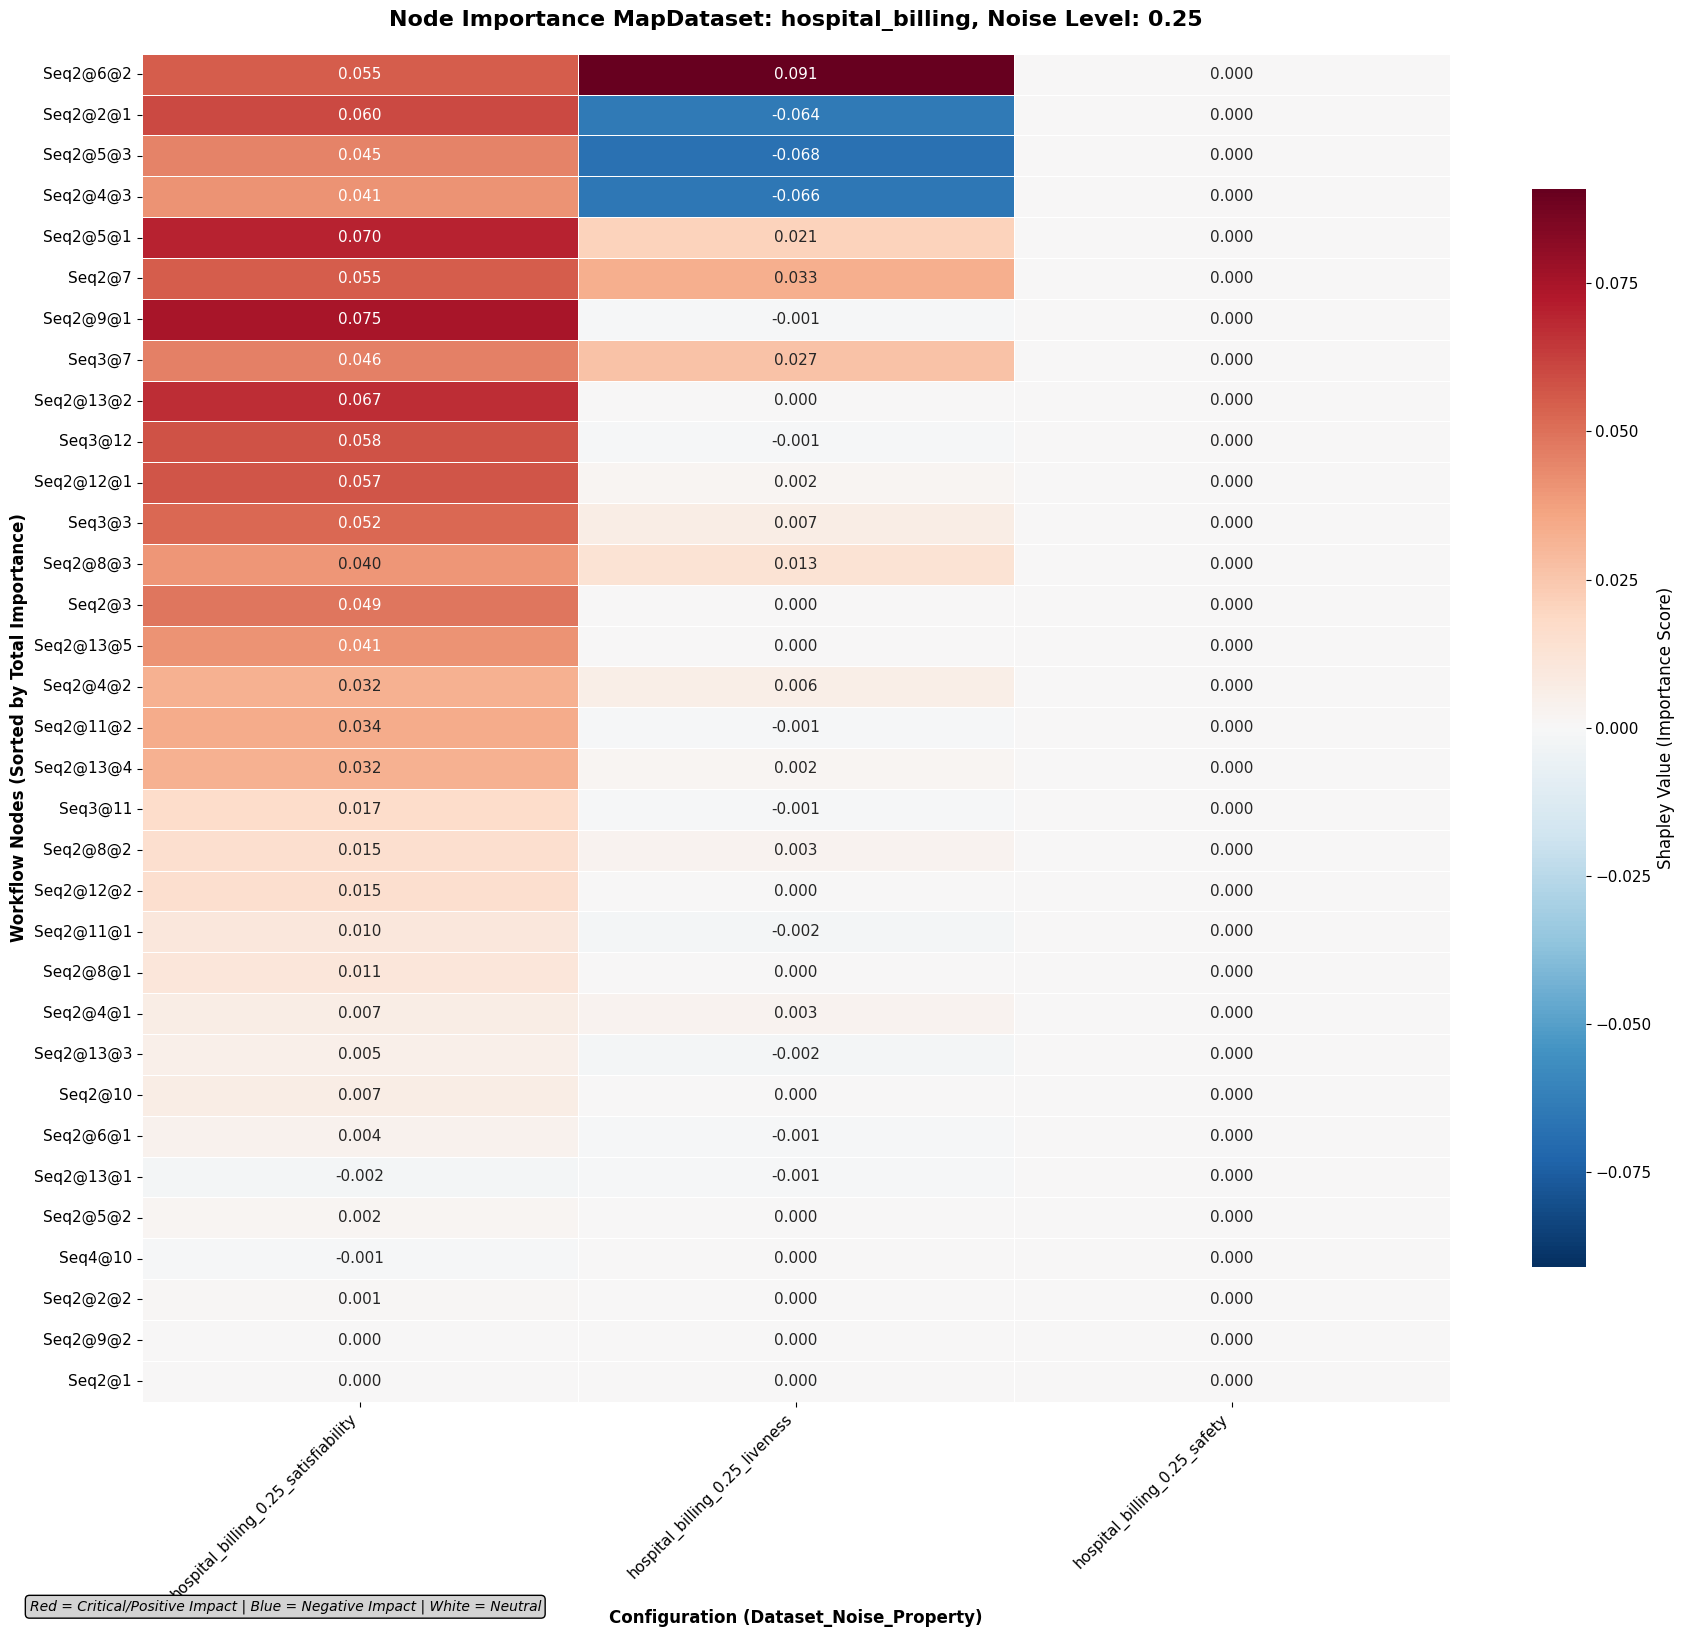

Analysis summary:
Nodes analyzed: 33
Configurations: 3
Most critical node: Seq2@6@2
Least critical node: Seq2@9@2
Importance -> spec:
   • satisfiability: 0.030 (Medium importance)
   • liveness: 0.013 (Medium importance)
   • safety: 0.000 (Medium importance)
\nCombination 7: HOSPITAL_BILLING + NOISE 0.5
Detailed importance map - hospital_billing (noise = 0.5)


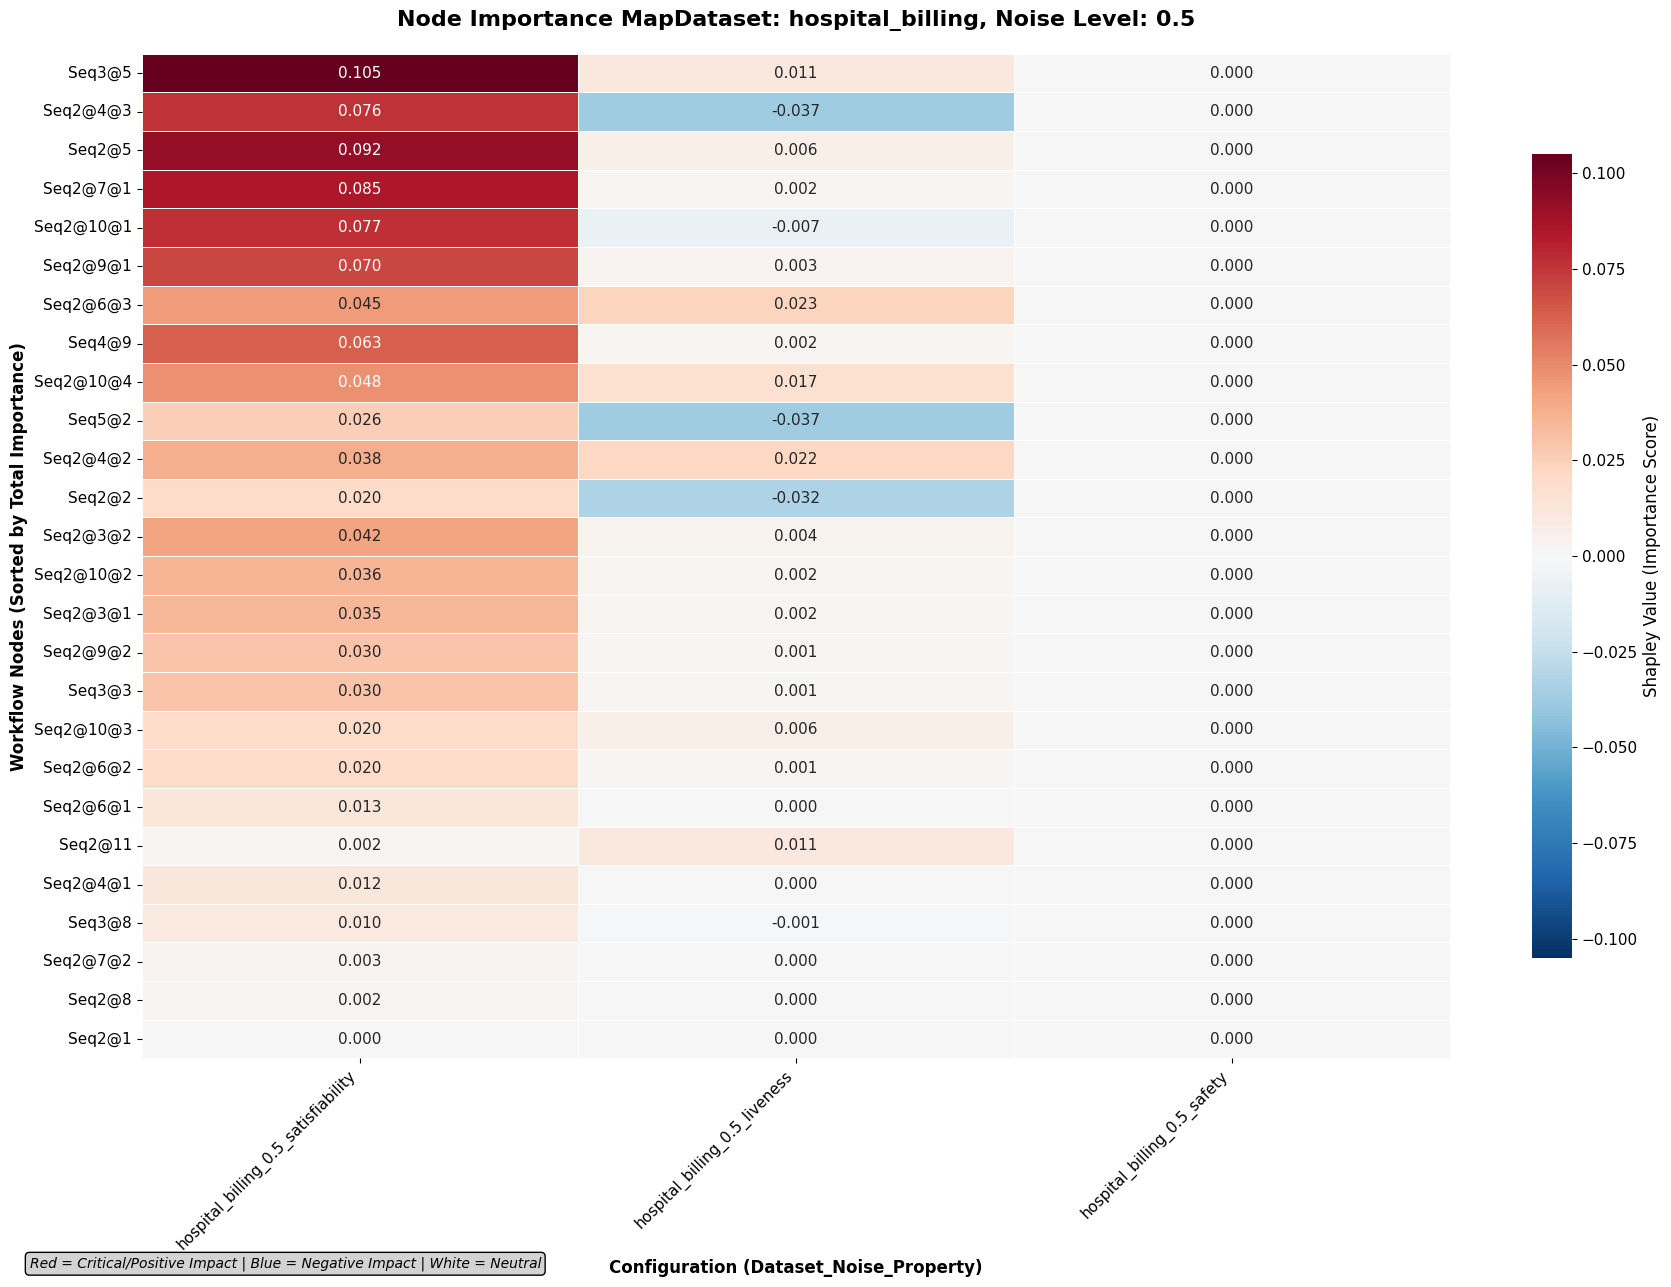

Analysis summary:
Nodes analyzed: 26
Configurations: 3
Most critical node: Seq3@5
Least critical node: Seq2@1
Importance -> spec:
   • satisfiability: 0.038 (Medium importance)
   • liveness: 0.009 (Medium importance)
   • safety: 0.000 (Medium importance)
\nCombination 8: HOSPITAL_BILLING + NOISE 1.0
Detailed importance map - hospital_billing (noise = 1.0)


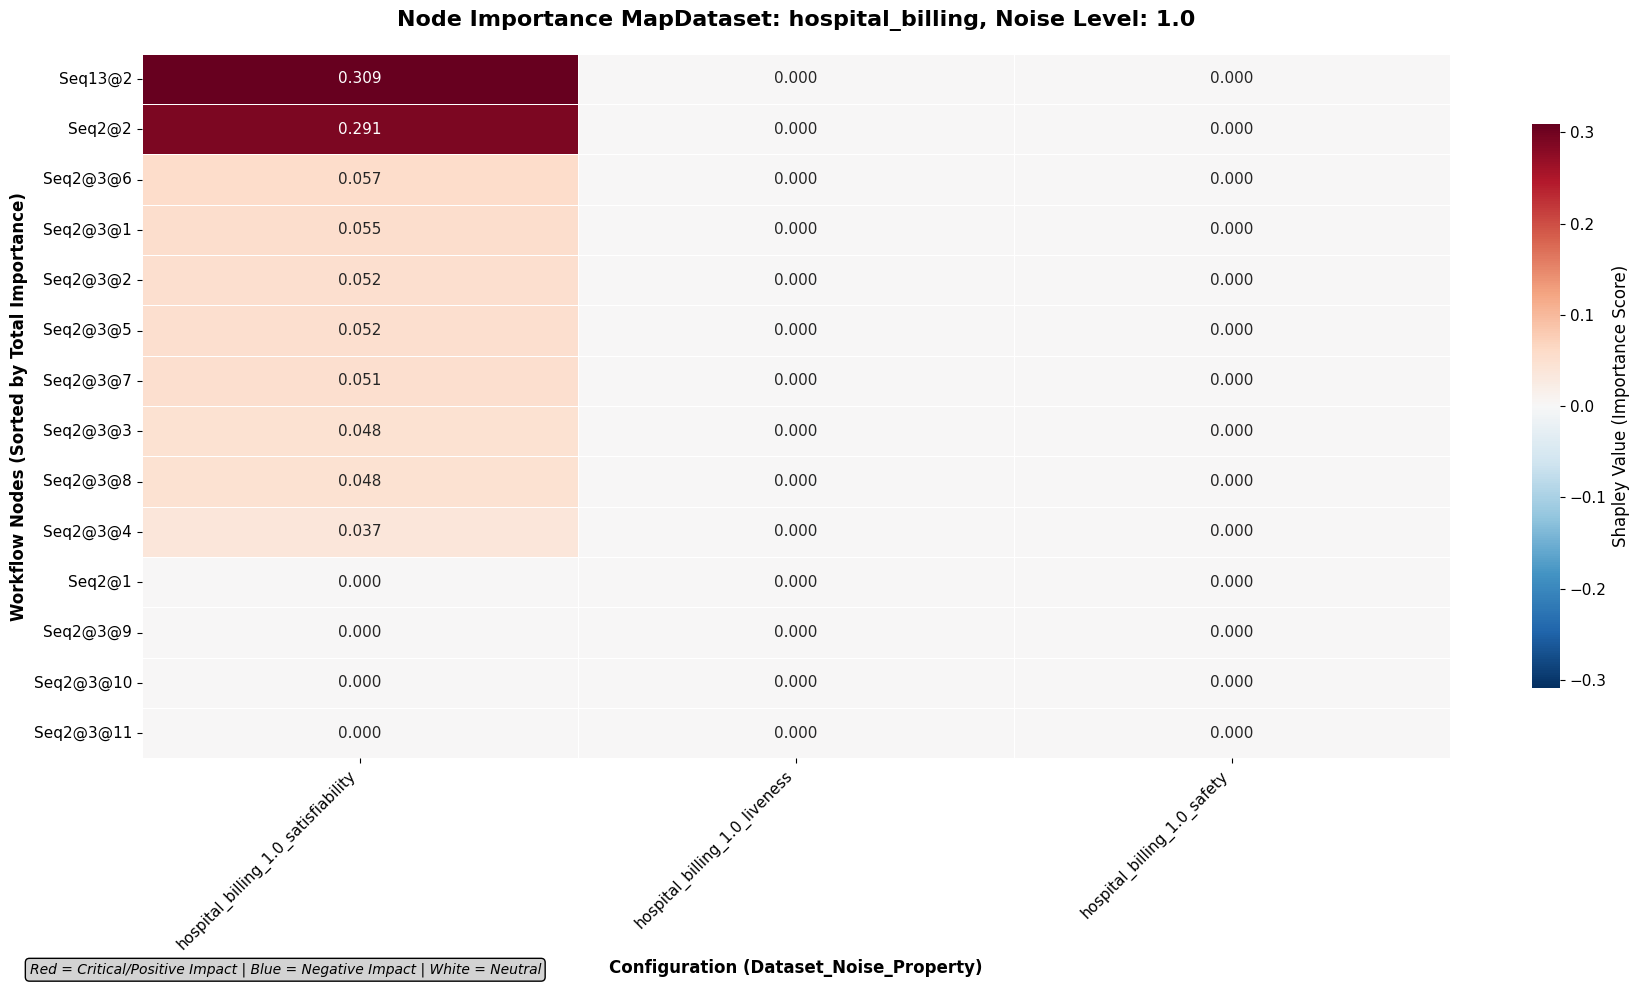

Analysis summary:
Nodes analyzed: 14
Configurations: 3
Most critical node: Seq13@2
Least critical node: Seq2@1
Importance -> spec:
   • satisfiability: 0.071 (Medium importance)
   • liveness: 0.000 (Medium importance)
   • safety: 0.000 (Medium importance)
\nCombination 9: RUNNING_EXAMPLE + NOISE 0.0
Detailed importance map - running_example (noise = 0.0)


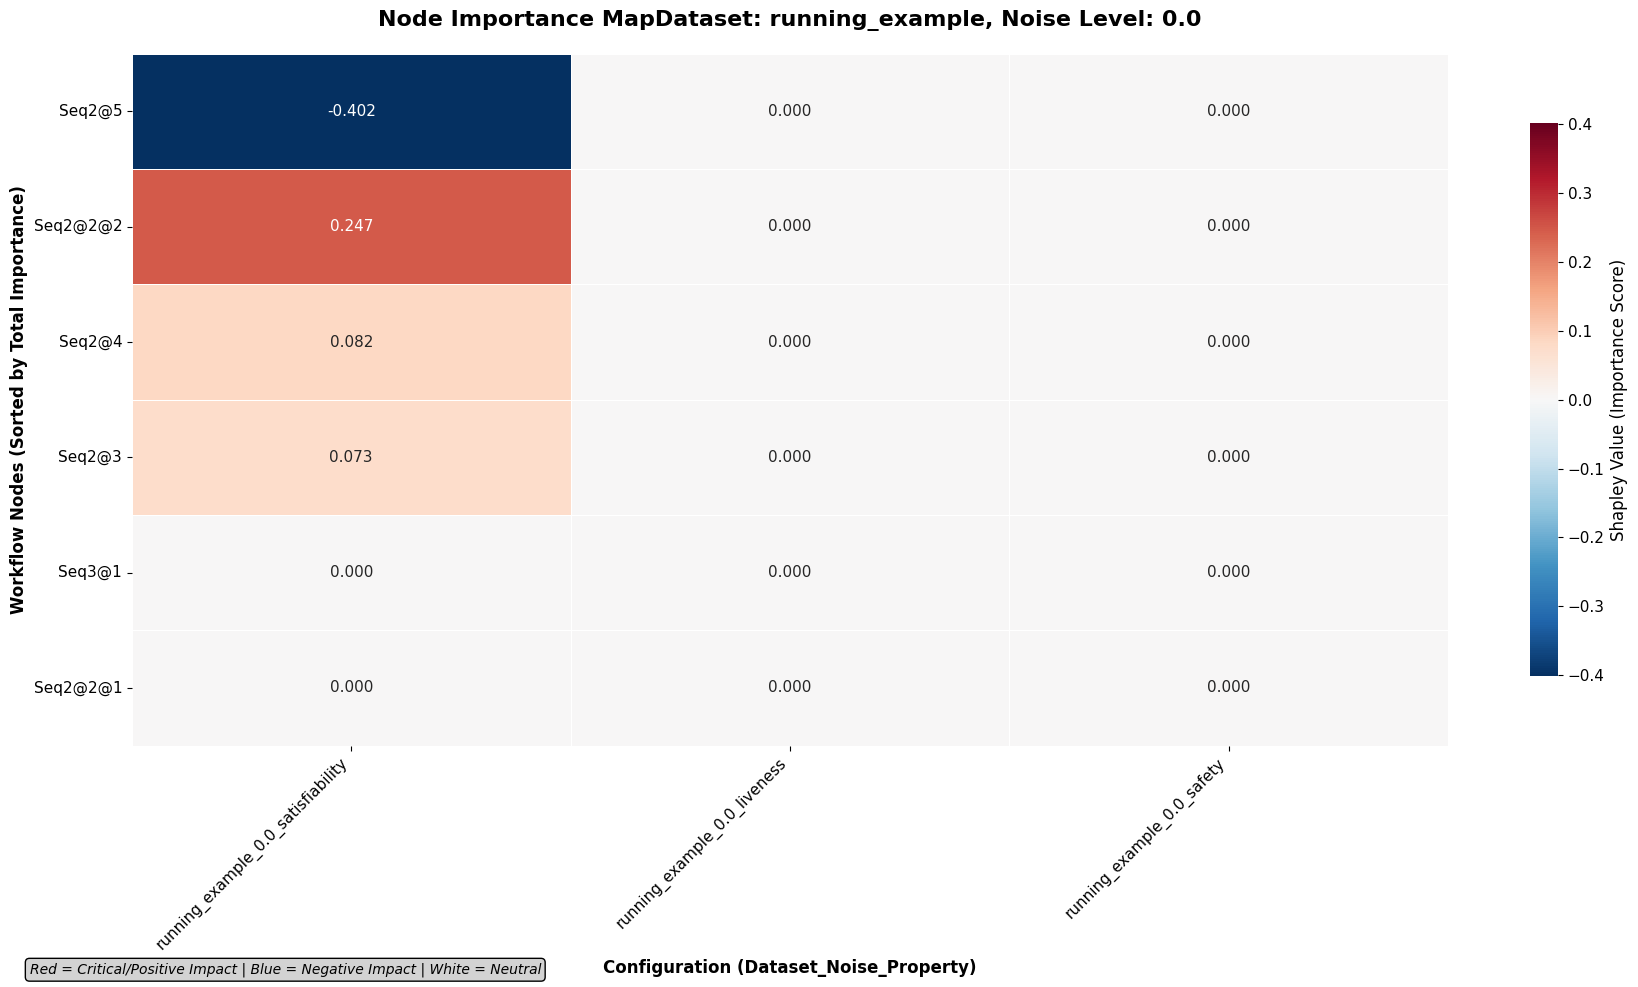

Analysis summary:
Nodes analyzed: 6
Configurations: 3
Most critical node: Seq2@5
Least critical node: Seq3@1
Importance -> spec:
   • satisfiability: 0.134 (Medium importance)
   • liveness: 0.000 (Medium importance)
   • safety: 0.000 (Medium importance)
\nCombination 10: RUNNING_EXAMPLE + NOISE 0.25
Detailed importance map - running_example (noise = 0.25)


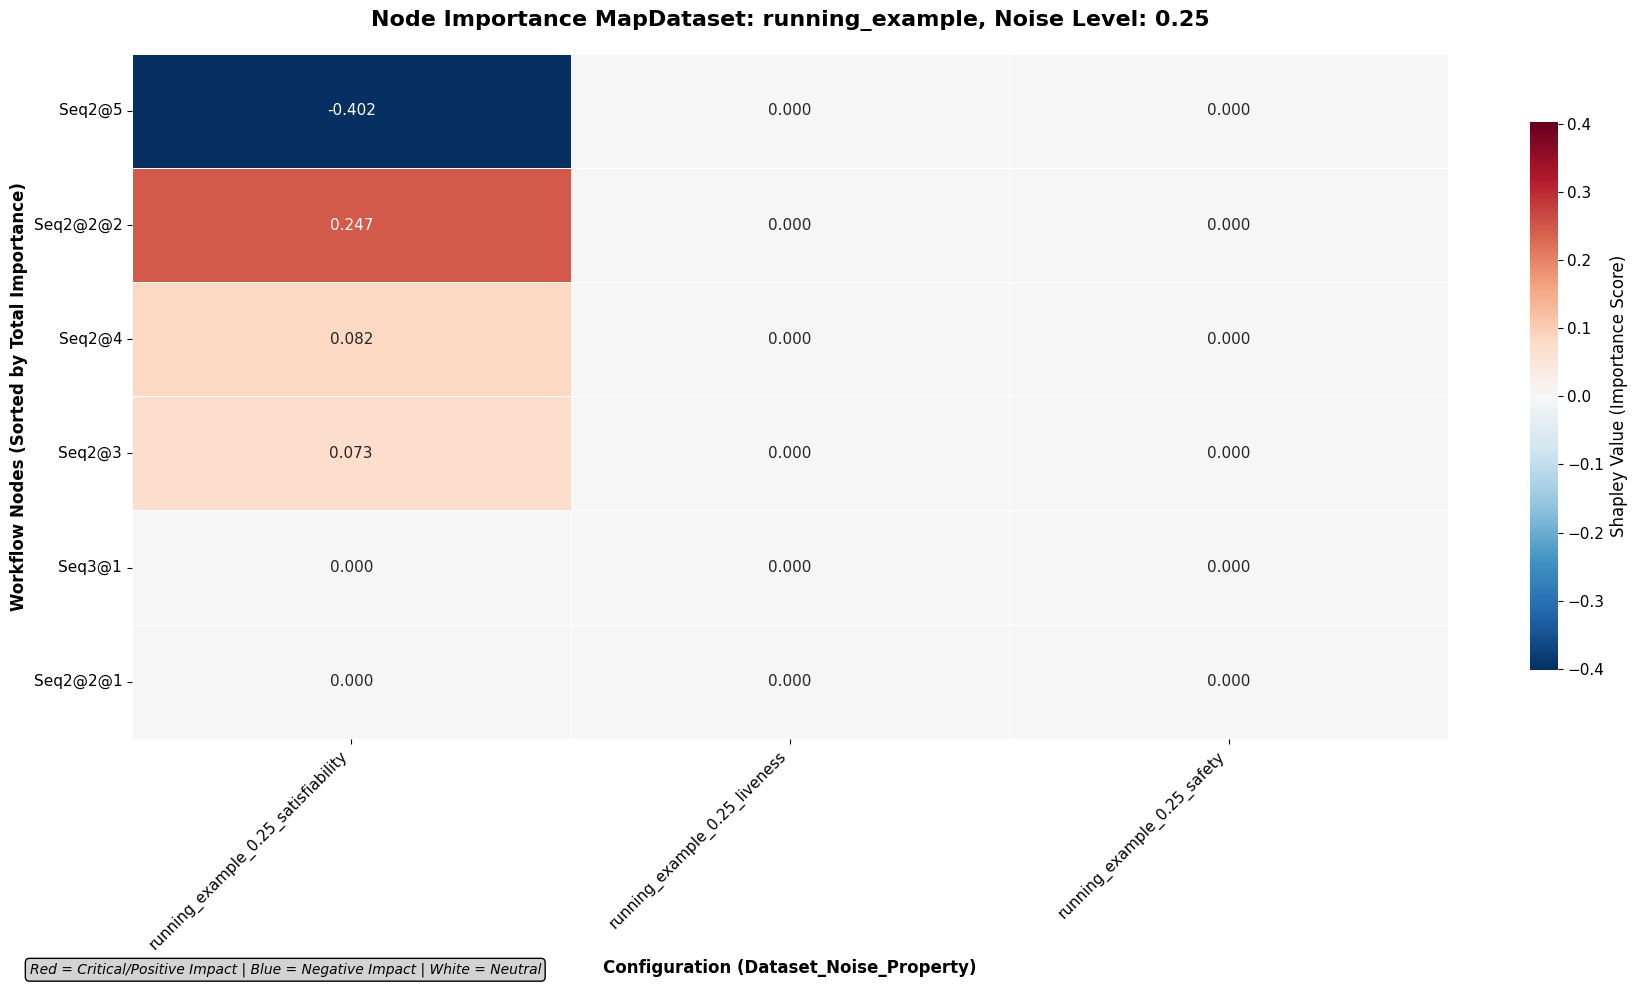

Analysis summary:
Nodes analyzed: 6
Configurations: 3
Most critical node: Seq2@5
Least critical node: Seq3@1
Importance -> spec:
   • satisfiability: 0.134 (Medium importance)
   • liveness: 0.000 (Medium importance)
   • safety: 0.000 (Medium importance)
\nCombination 11: RUNNING_EXAMPLE + NOISE 0.5
Detailed importance map - running_example (noise = 0.5)


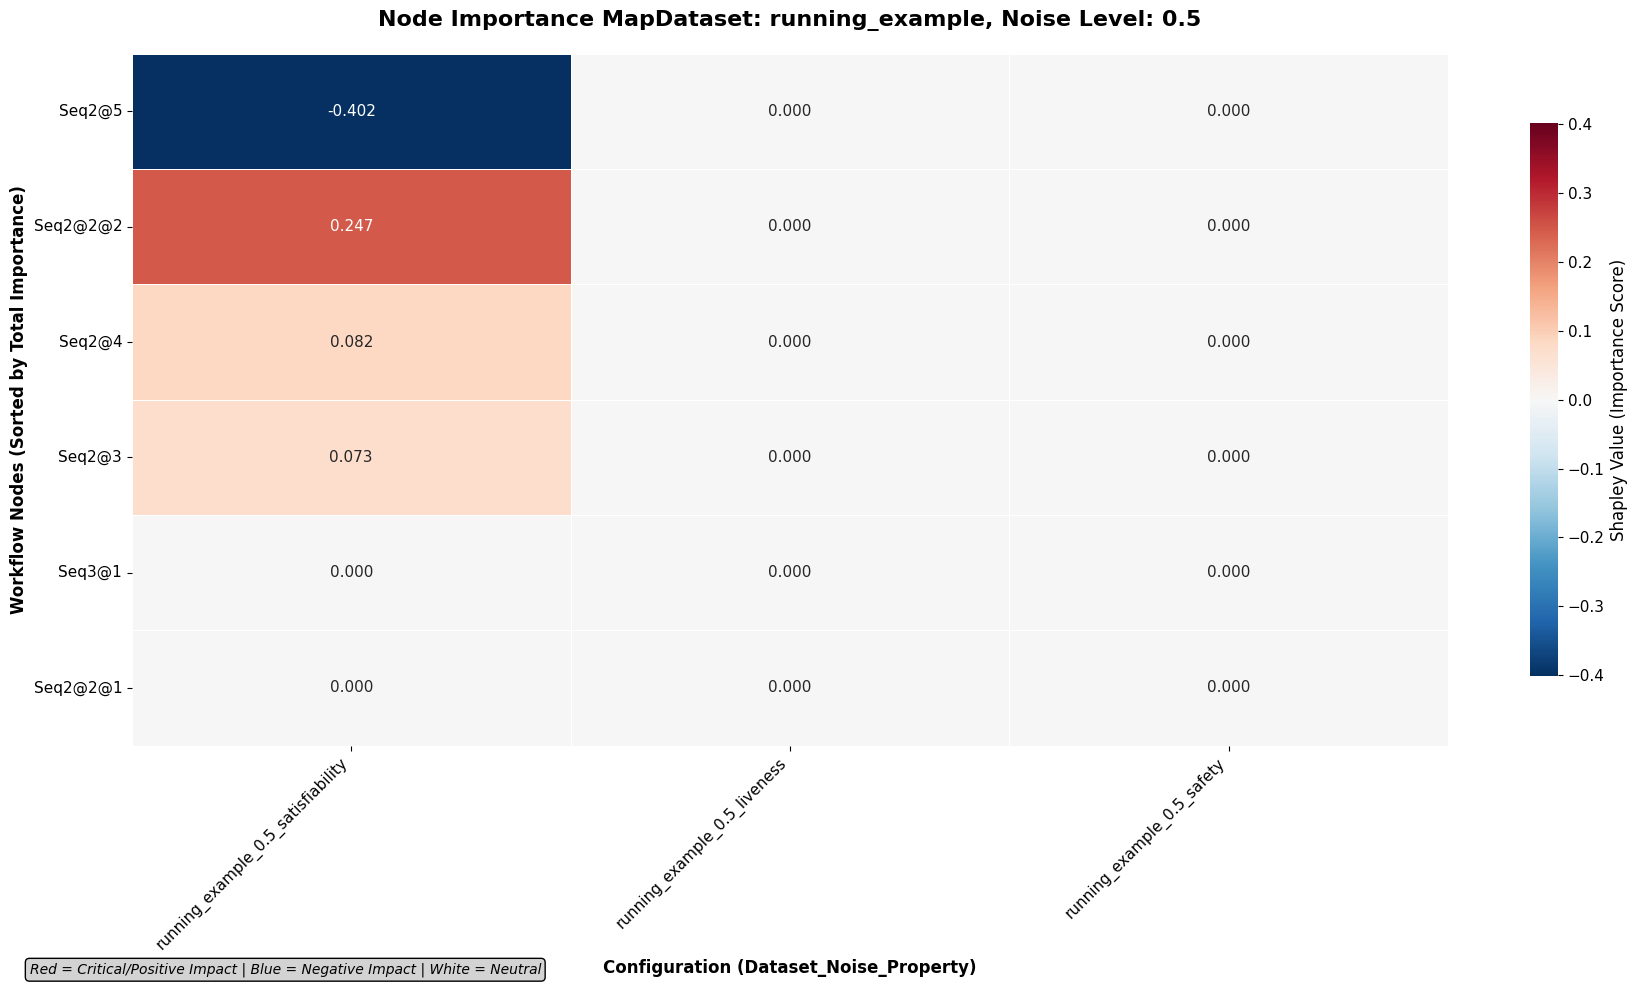

Analysis summary:
Nodes analyzed: 6
Configurations: 3
Most critical node: Seq2@5
Least critical node: Seq3@1
Importance -> spec:
   • satisfiability: 0.134 (Medium importance)
   • liveness: 0.000 (Medium importance)
   • safety: 0.000 (Medium importance)
\nCombination 12: RUNNING_EXAMPLE + NOISE 1.0
Detailed importance map - running_example (noise = 1.0)


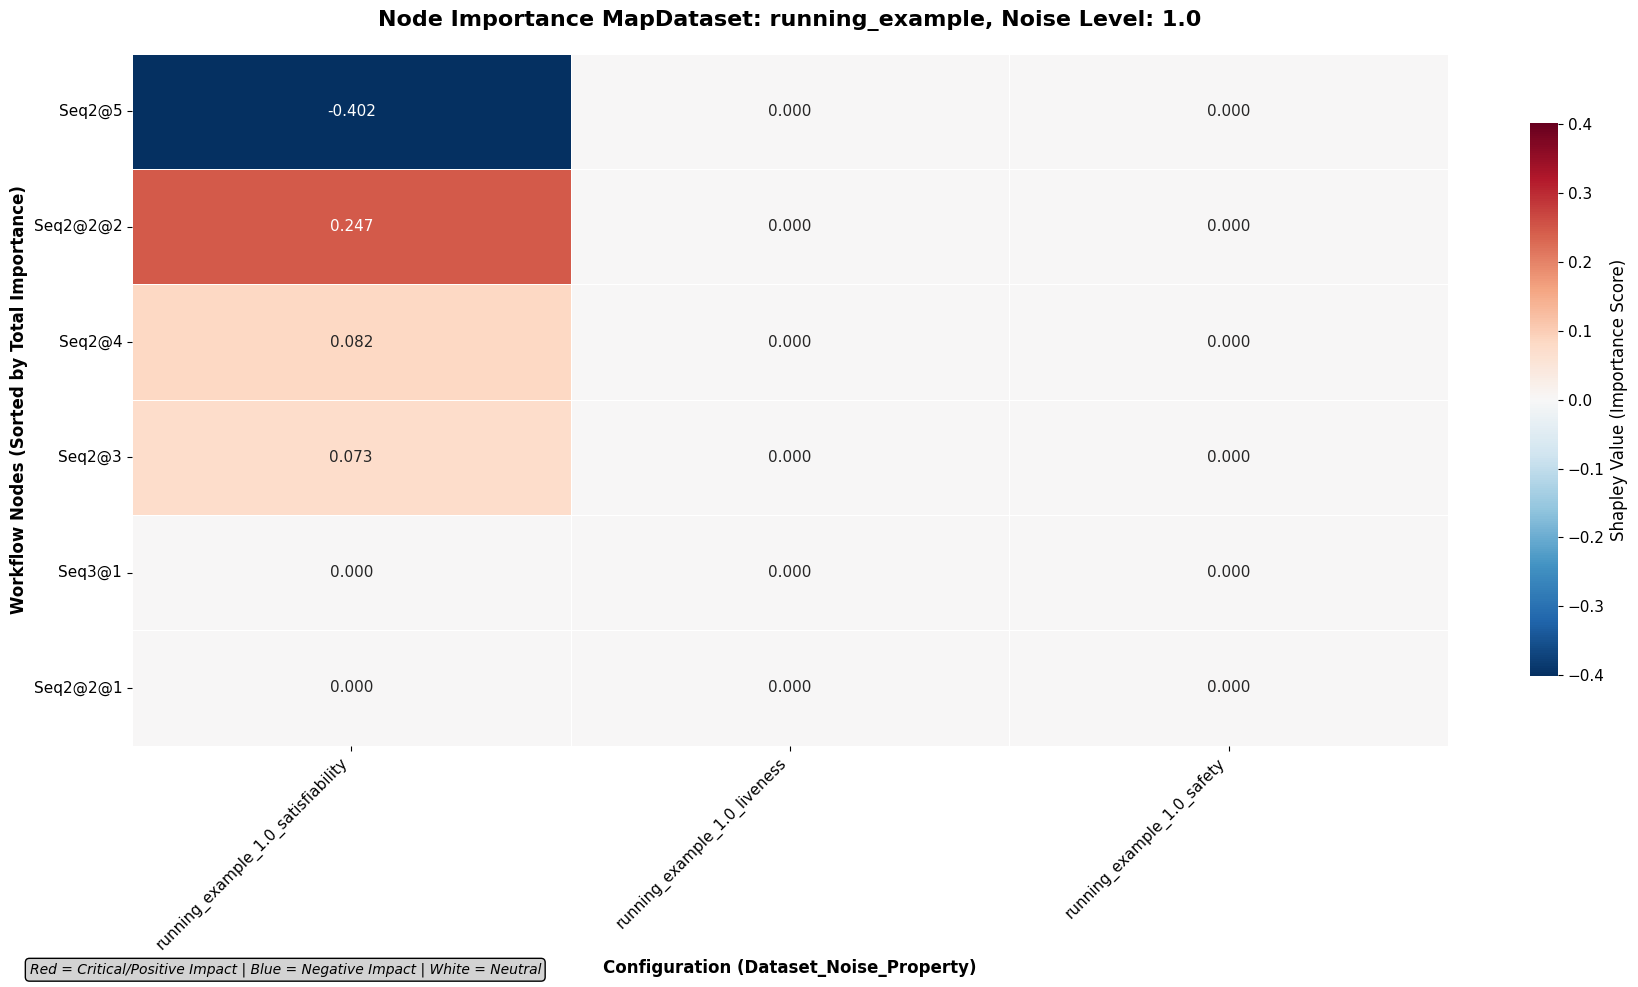

Analysis summary:
Nodes analyzed: 6
Configurations: 3
Most critical node: Seq2@5
Least critical node: Seq3@1
Importance -> spec:
   • satisfiability: 0.134 (Medium importance)
   • liveness: 0.000 (Medium importance)
   • safety: 0.000 (Medium importance)
Model quality diagnosis - comprehensive analysis
------------------------------------------------------------
Analysis of all datasets and noise levels
Thresholds: Critical ≥ 0.1, Redundant ≤ 0.01


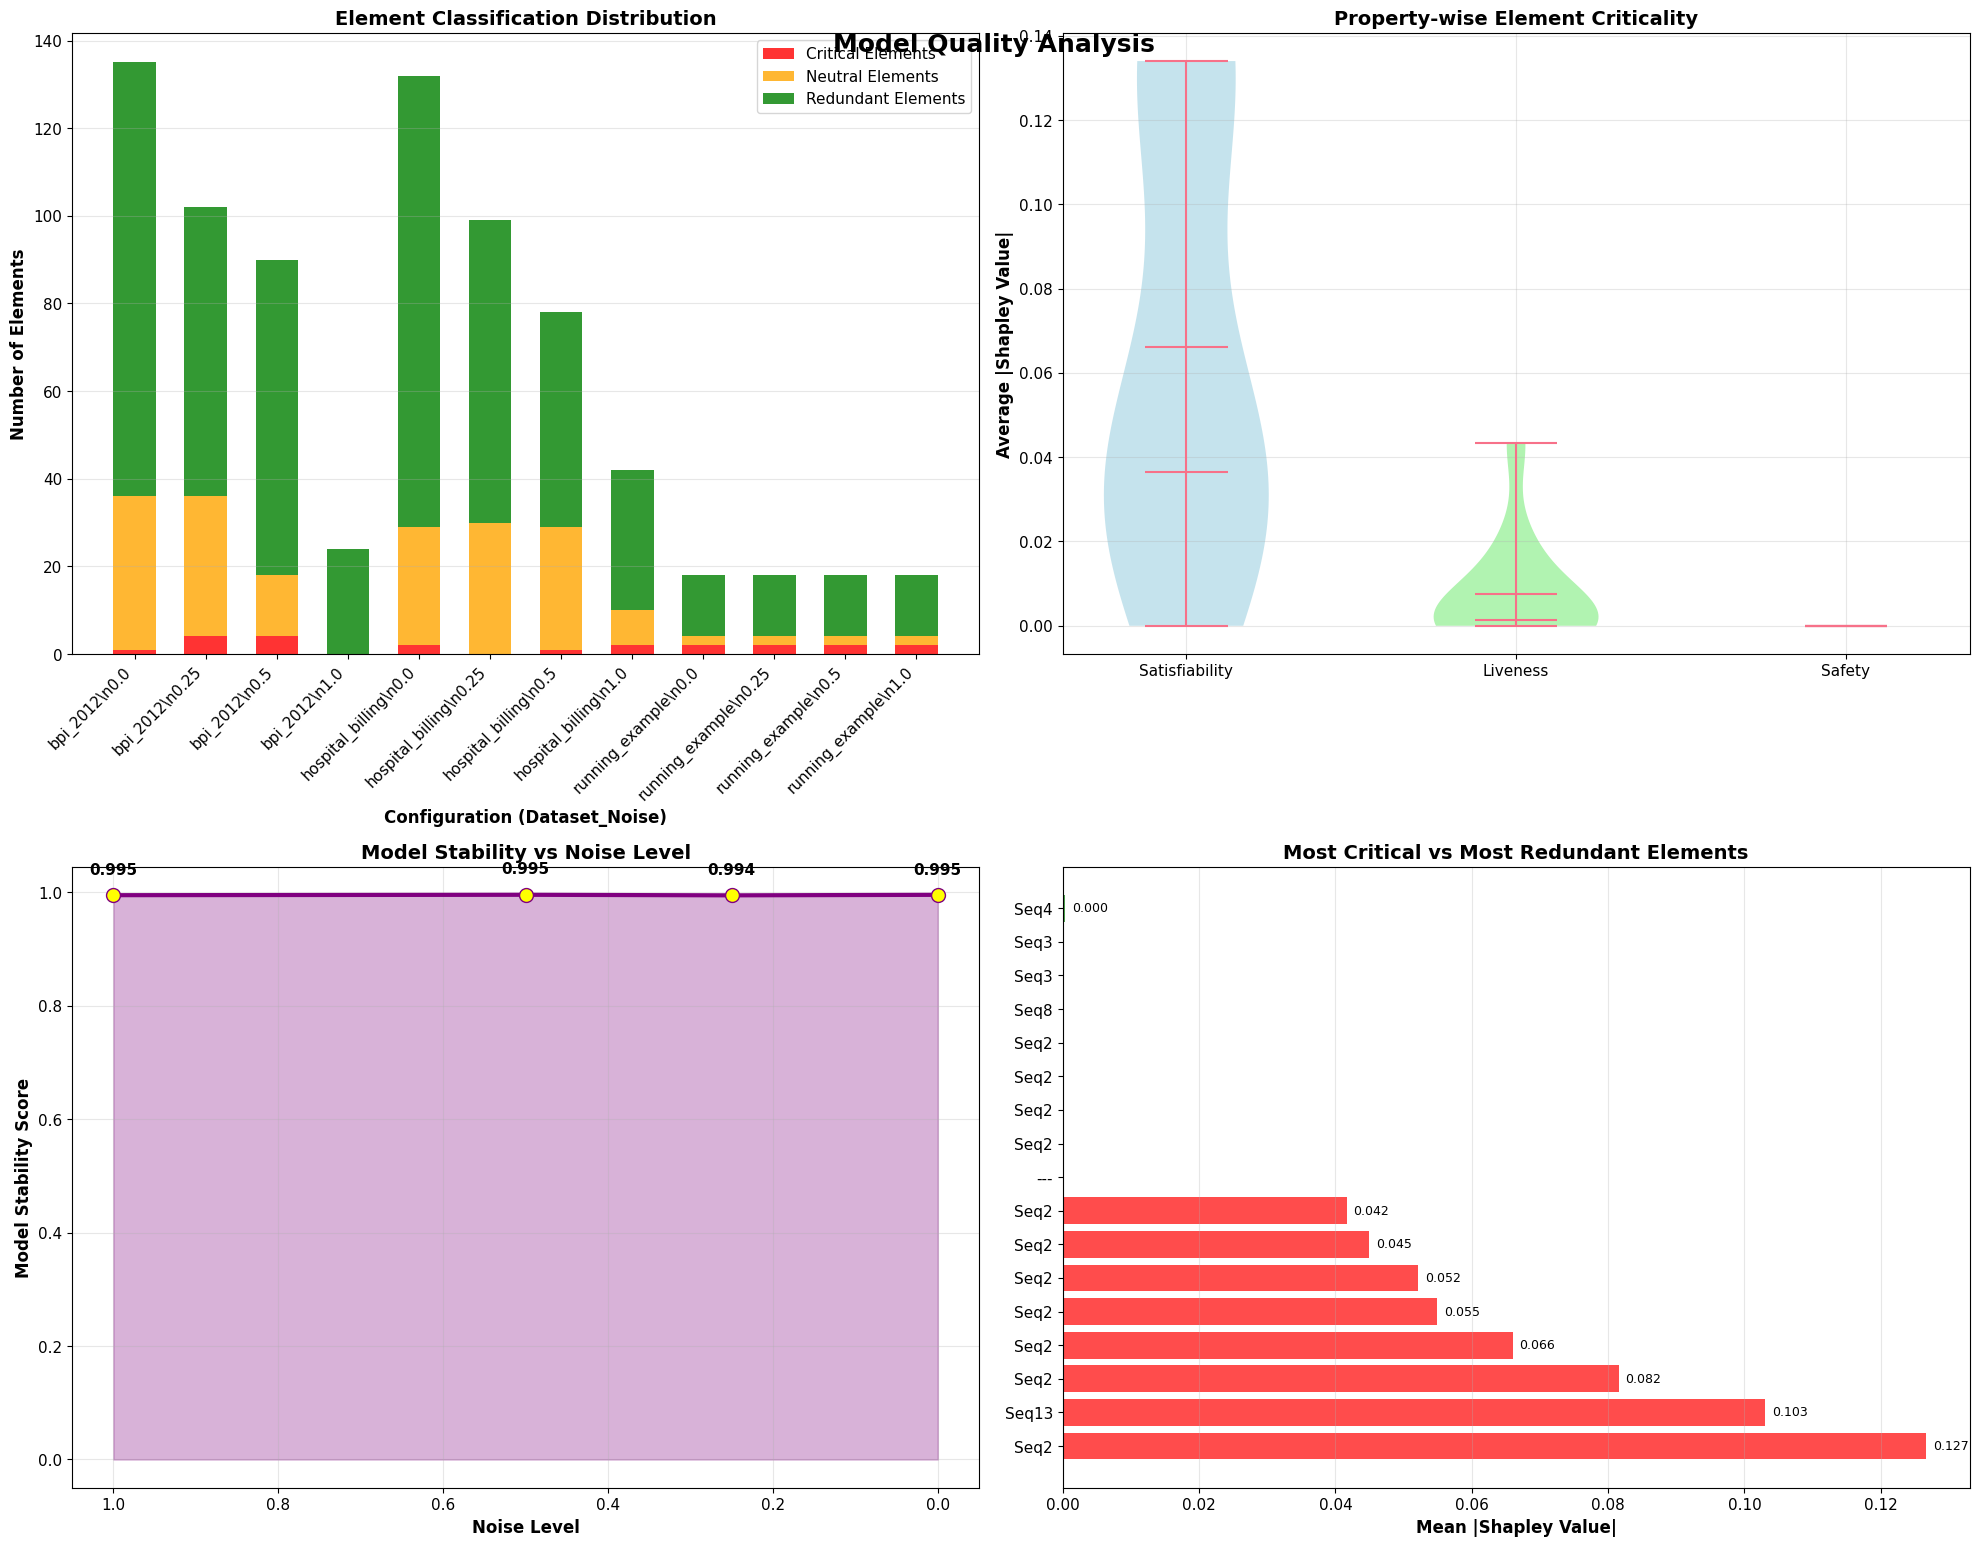

Detailed diagnosis report:
Elements classification:
Critical elements: 22 (2.8%)
Neutral elements: 182 (23.5%)
Redundant elements: 570 (73.6%)
Recommendations:
HIGH REDUNDANCY - consider simplifying the model
LOW CRITICALITY - model is stable
MOST IMPORTANT ELEMENTS:
   1. Seq2@12@3: 0.127
   2. Seq13@2: 0.103
   3. Seq2@5: 0.082
CANDIDATES FOR DELETION:
   1. Seq4@10: 0.000
   2. Seq3@1: 0.000
   3. Seq3@2: 0.000
Model quality diagnosis - high sensitivity
------------------------------------------------------------
Analysis with stricter thresholds
Thresholds: Critical ≥ 0.05, Redundant ≤ 0.005


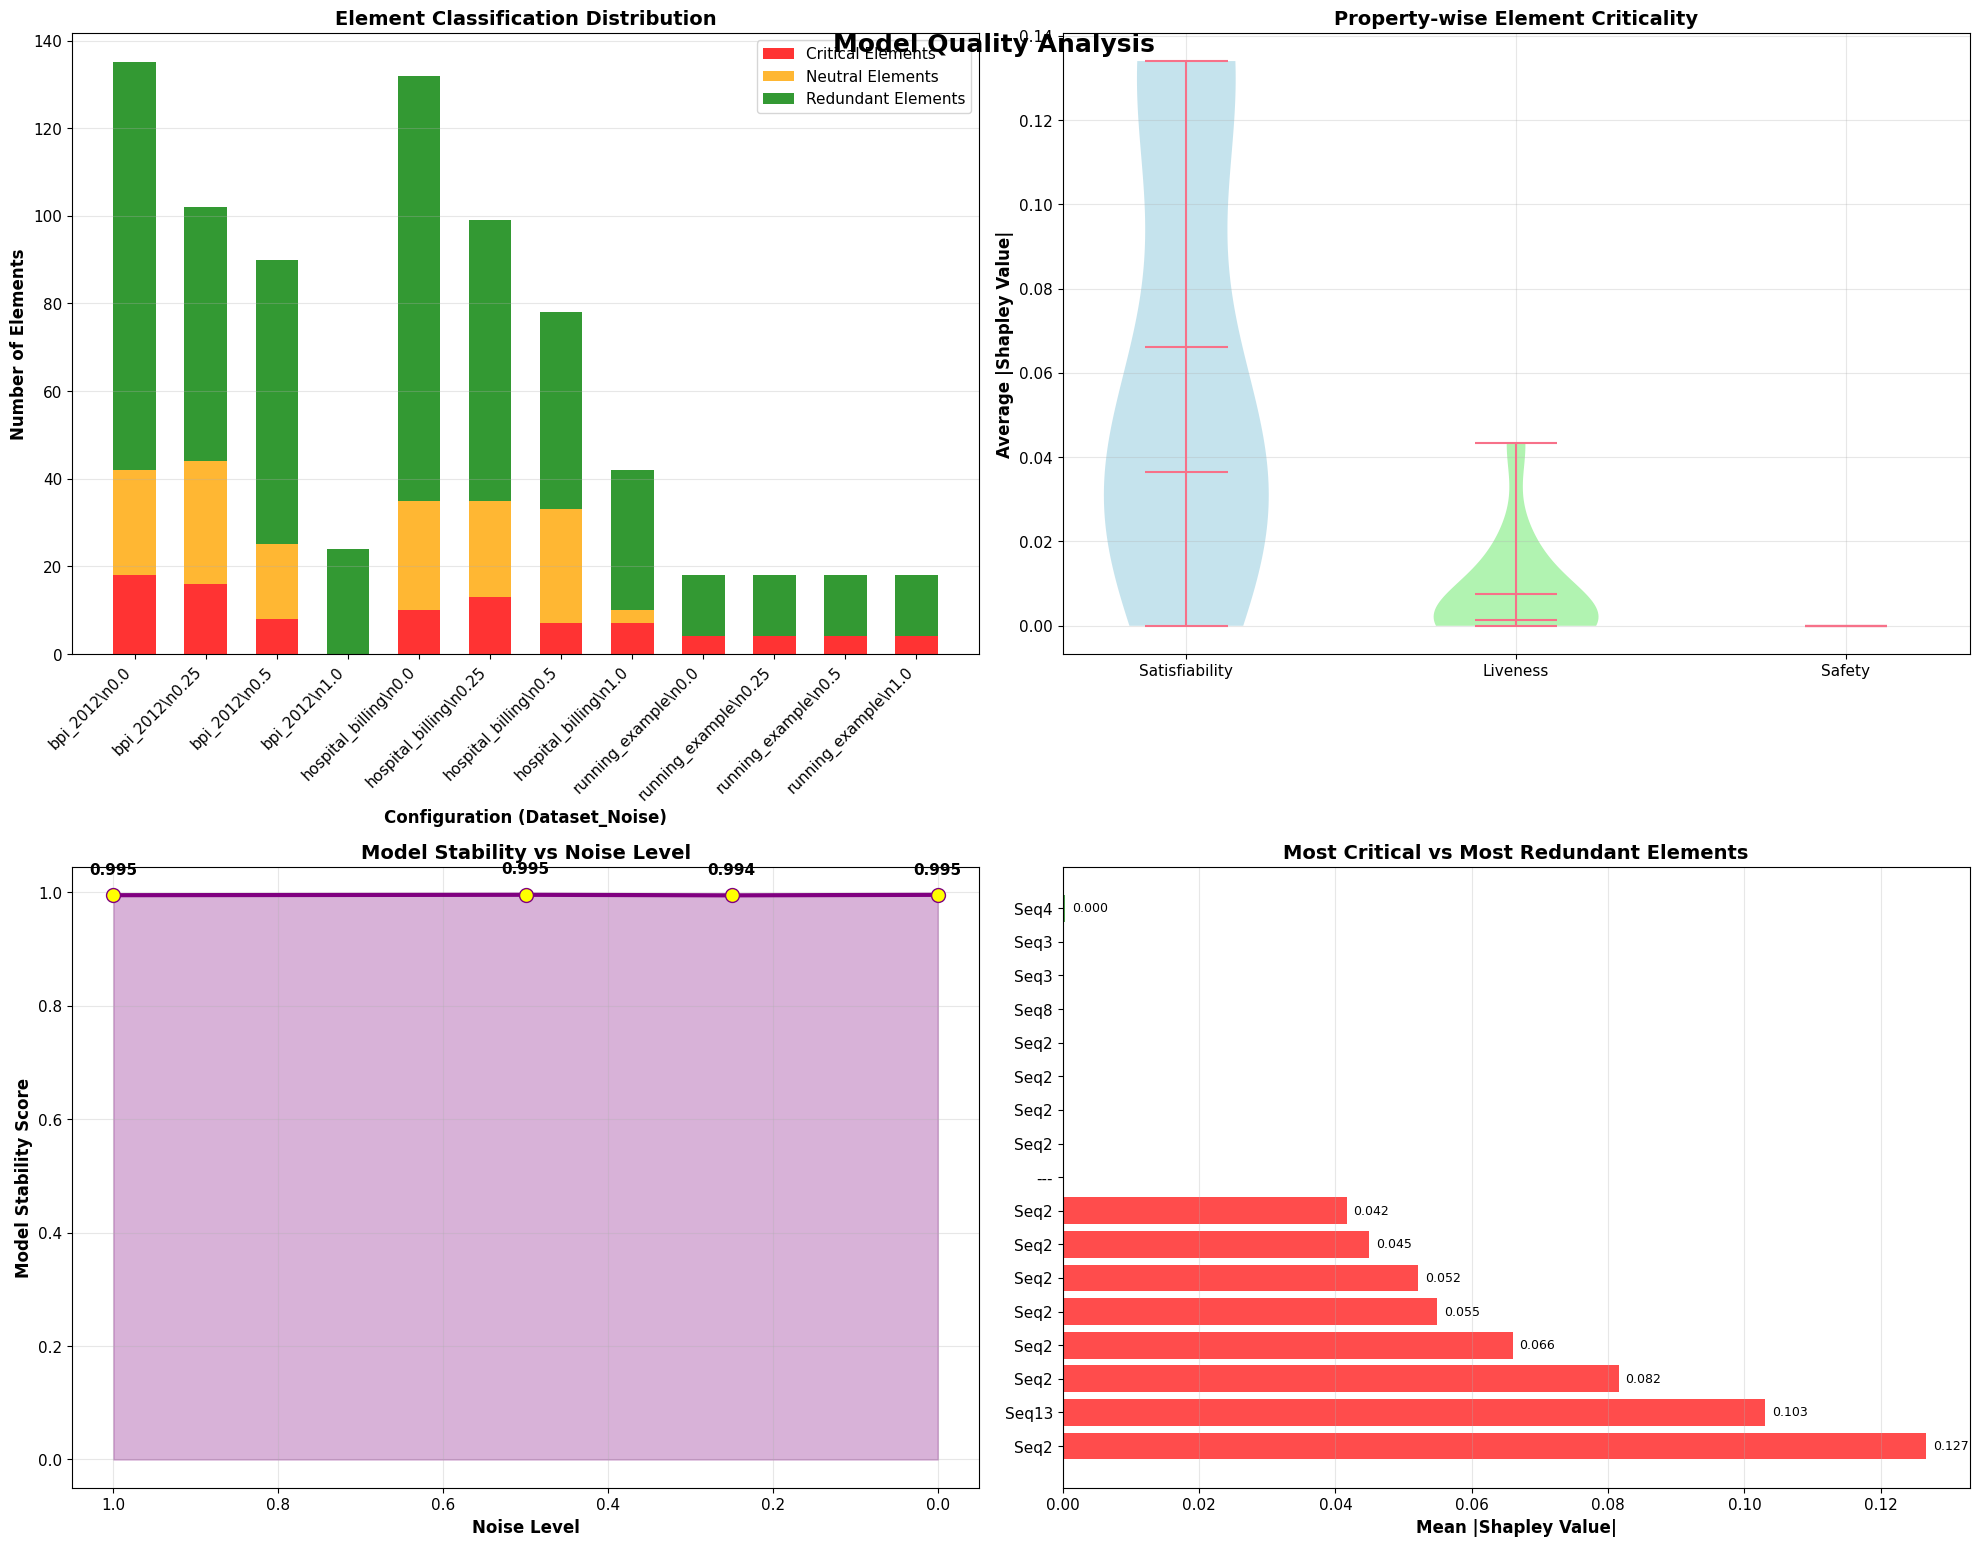

Detailed diagnosis report:
Elements classification:
Critical elements: 95 (12.3%)
Neutral elements: 145 (18.7%)
Redundant elements: 534 (69.0%)
Recommendations:
HIGH REDUNDANCY - consider simplifying the model
MOST IMPORTANT ELEMENTS:
   1. Seq2@12@3: 0.127
   2. Seq13@2: 0.103
   3. Seq2@5: 0.082
CANDIDATES FOR DELETION:
   1. Seq4@10: 0.000
   2. Seq3@1: 0.000
   3. Seq3@2: 0.000
Model quality diagnosis - low sensitivity
------------------------------------------------------------
Analysis with milder thresholds
Thresholds: Critical ≥ 0.2, Redundant ≤ 0.02


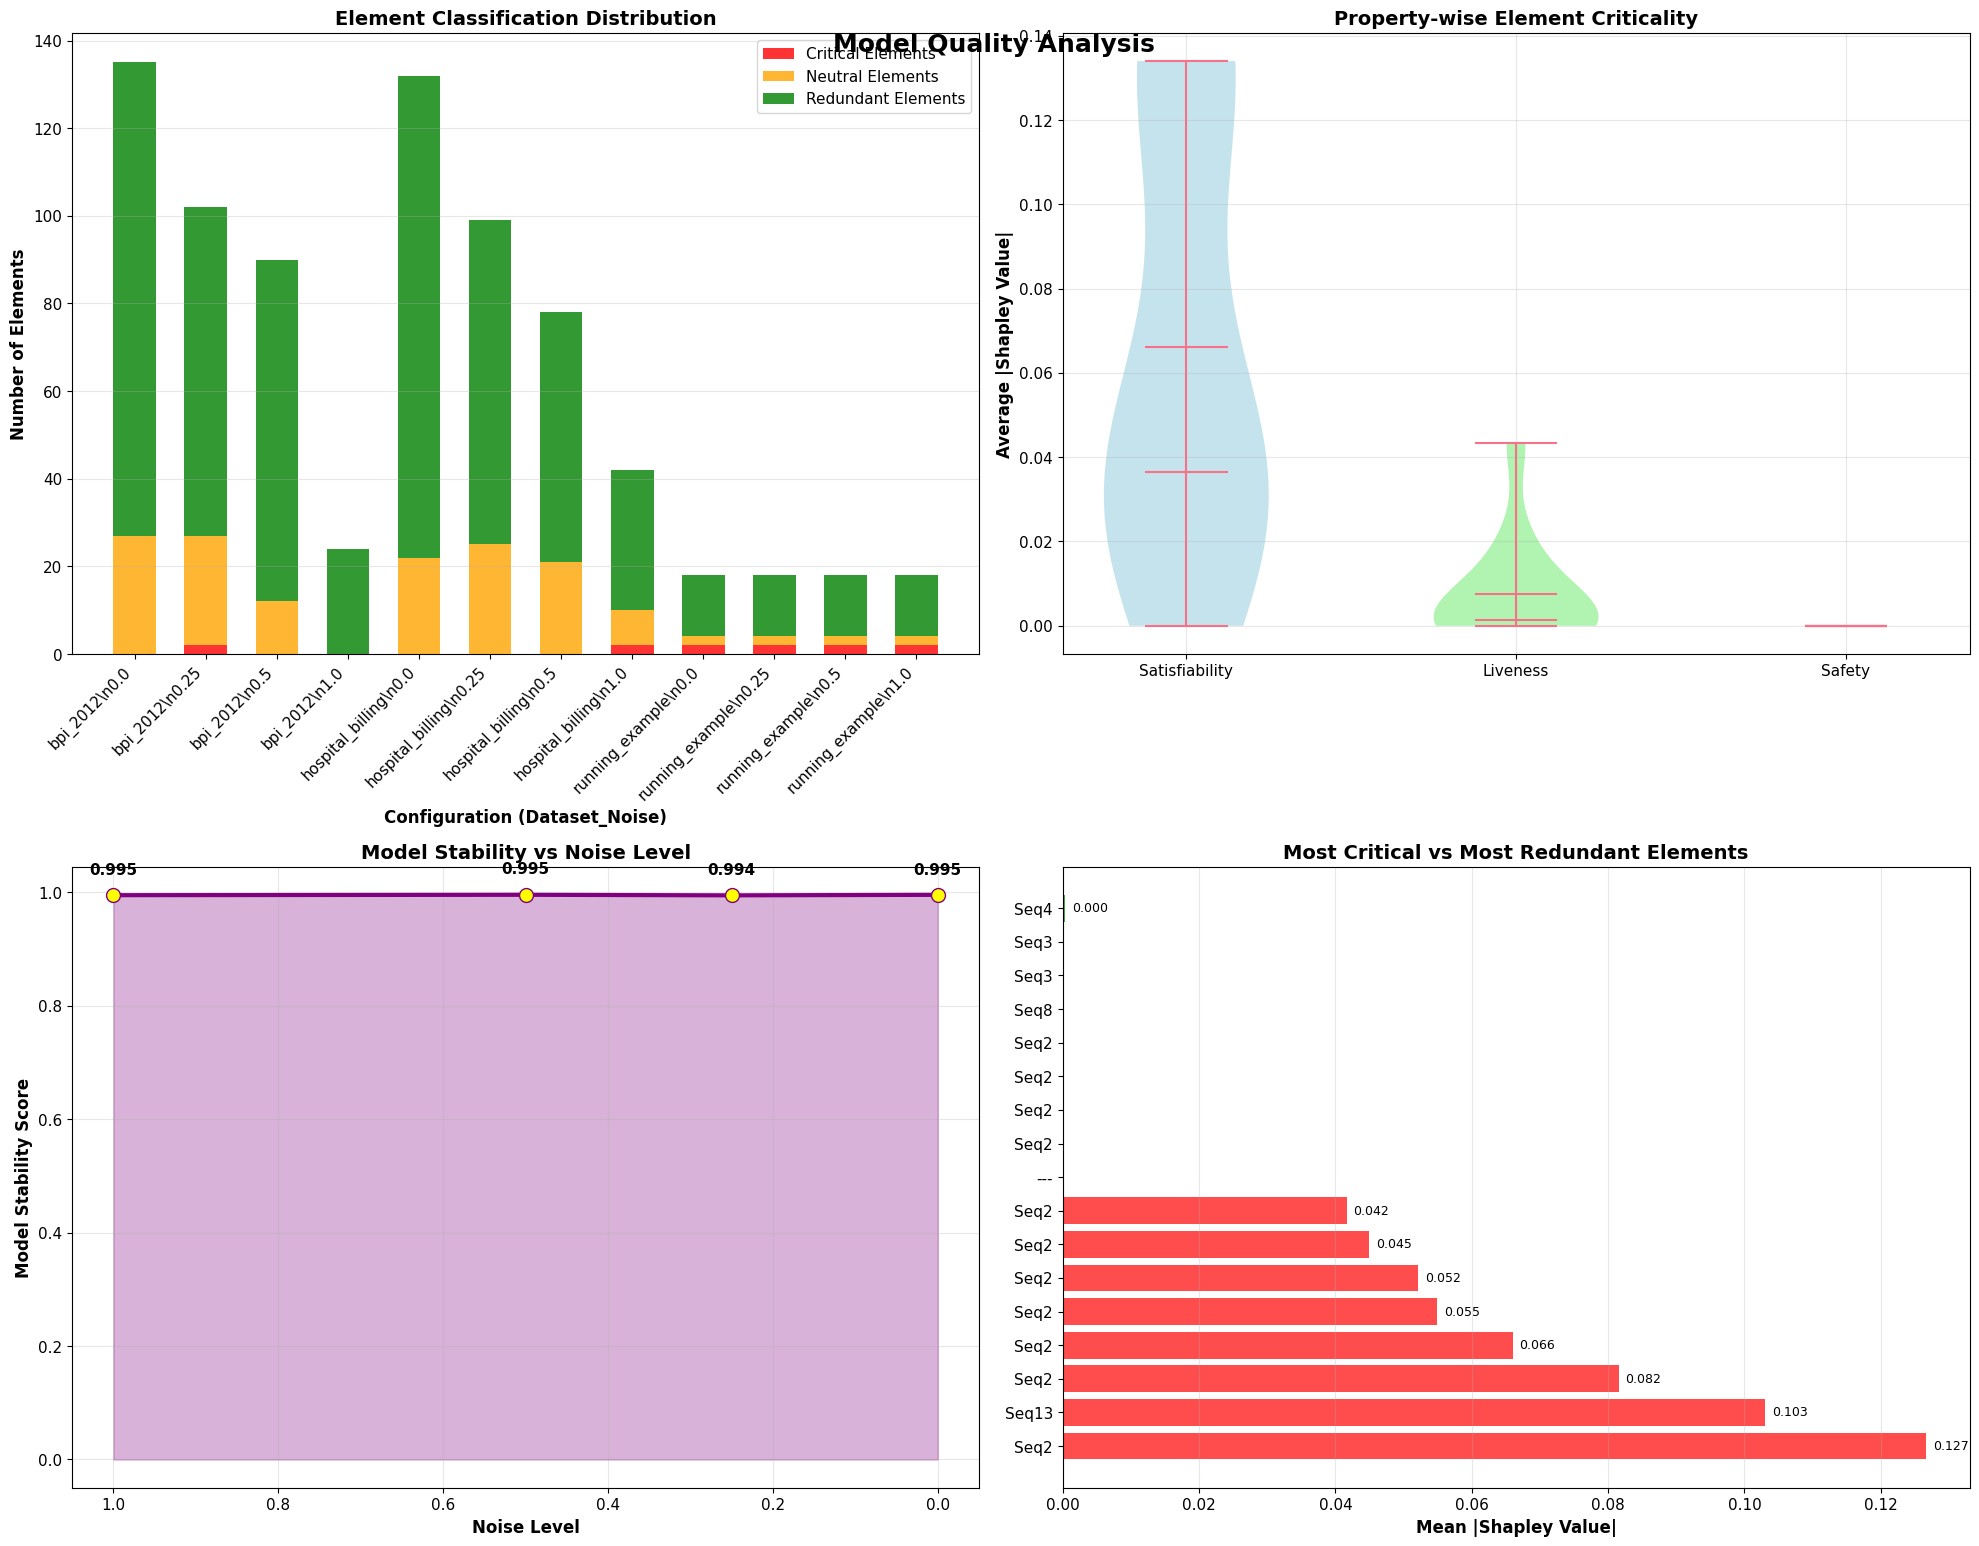

Detailed diagnosis report:
Elements classification:
Critical elements: 12 (1.6%)
Neutral elements: 148 (19.1%)
Redundant elements: 614 (79.3%)
Recommendations:
HIGH REDUNDANCY - consider simplifying the model
LOW CRITICALITY - model is stable
MOST IMPORTANT ELEMENTS:
   1. Seq2@12@3: 0.127
   2. Seq13@2: 0.103
   3. Seq2@5: 0.082
CANDIDATES FOR DELETION:
   1. Seq4@10: 0.000
   2. Seq3@1: 0.000
   3. Seq3@2: 0.000
SUMMARY OF COMPLETED ANALYSES:
    Node importance maps: 19
       • By dataset (noise=0.0): 3
       • By noise levels: 4
       • All combinations: 12
    Model quality diagnoses: 3
       • Standard thresholds (0.1 / 0.01): 1
       • High thresholds (0.05 / 0.005): 1
       • Low thresholds (0.2 / 0.02): 1
PRACTICAL APPLICATIONS OF RESULTS:
   • Identification of most critical nodes in workflow
   • Detection of redundant elements for optimization
   • Evaluation of noise impact on model stability
   • Comparison of quality of different datasets
   • Support for decision 

In [85]:
if 'SHAPLEY_RESULTS' not in globals() or not SHAPLEY_RESULTS:
    print("SHAPLEY_RESULTS are not available!")
    print("Run the main analysis loop first")
    print("Example: SHAPLEY_RESULTS = run_shapley_all_configs(...)")
else:
    print(f"SHAPLEY_RESULTS are available: {len(SHAPLEY_RESULTS)} configurations")

    available_logs = sorted(list(set(r['log'] for r in SHAPLEY_RESULTS)))
    available_noises = sorted(list(set(r['noise'] for r in SHAPLEY_RESULTS)))
    
    print(f"Available datasets: {available_logs}")
    print(f"Available noise levels: {available_noises}")
    
    print("="*80)
    print("Importance maps for all combinations")
    print("="*80)
    
    print("Importance maps - best quality (noise = 0.0)")
    print("-" * 60)
    
    for log_name in available_logs:
        print(f"\\nAnalysis for dataset: {log_name.upper()}")
        print(f"Importance map - {log_name} (no noise)")
        create_node_importance_map(SHAPLEY_RESULTS, dataset_name=log_name, noise_level=0.0)
    
    print("Importance maps - noise impact")
    print("-" * 60)
    
    for noise in available_noises:
        print(f"\\nAnalysis for noise level: {noise}")
        print(f"Importance map - all datasets (noise = {noise})")
        create_node_importance_map(SHAPLEY_RESULTS, dataset_name=None, noise_level=noise)
    
    print("Importance maps - all combinations")
    print("-" * 60)
    
    combination_count = 0
    for log_name in available_logs:
        for noise in available_noises:
            combination_count += 1
            print(f"\\nCombination {combination_count}: {log_name.upper()} + NOISE {noise}")
            print(f"Detailed importance map - {log_name} (noise = {noise})")
            create_node_importance_map(SHAPLEY_RESULTS, dataset_name=log_name, noise_level=noise)
    
    print("="*80)
    print("Model quality diagnosis - comprehensive analysis")
    print("-" * 60)
    print("Analysis of all datasets and noise levels")
    print("Thresholds: Critical ≥ 0.1, Redundant ≤ 0.01")
    
    diagnose_model_quality(SHAPLEY_RESULTS, critical_threshold=0.1, redundant_threshold=0.01)
    
    print("Model quality diagnosis - high sensitivity")
    print("-" * 60)
    print("Analysis with stricter thresholds")
    print("Thresholds: Critical ≥ 0.05, Redundant ≤ 0.005")
    
    diagnose_model_quality(SHAPLEY_RESULTS, critical_threshold=0.05, redundant_threshold=0.005)
    
    print("Model quality diagnosis - low sensitivity")
    print("-" * 60)
    print("Analysis with milder thresholds")
    print("Thresholds: Critical ≥ 0.2, Redundant ≤ 0.02")
    
    diagnose_model_quality(SHAPLEY_RESULTS, critical_threshold=0.2, redundant_threshold=0.02)
    
    print("="*90)
    
    total_maps = len(available_logs) + len(available_noises) + (len(available_logs) * len(available_noises))
    total_diagnoses = 3
    
    print(f"SUMMARY OF COMPLETED ANALYSES:")
    print(f"    Node importance maps: {total_maps}")
    print(f"       • By dataset (noise=0.0): {len(available_logs)}")
    print(f"       • By noise levels: {len(available_noises)}")
    print(f"       • All combinations: {len(available_logs) * len(available_noises)}")
    print(f"    Model quality diagnoses: {total_diagnoses}")
    print(f"       • Standard thresholds (0.1 / 0.01): 1")
    print(f"       • High thresholds (0.05 / 0.005): 1")
    print(f"       • Low thresholds (0.2 / 0.02): 1")
    
    print(f"PRACTICAL APPLICATIONS OF RESULTS:")
    print(f"   • Identification of most critical nodes in workflow")
    print(f"   • Detection of redundant elements for optimization")
    print(f"   • Evaluation of noise impact on model stability")
    print(f"   • Comparison of quality of different datasets")
    print(f"   • Support for decision to modify business processes")
    
    print(f"INTERPRETATION OF COLOR KEY IN IMPORTANCE MAPS:")
    print(f"   RED = Critical elements (positive impact on property)")
    print(f"   BLUE = Harmful elements (negative impact on property)")
    print(f"   WHITE = Neutral elements (minimal impact)")
    
    print(f"INTERPRETATION OF DIAGNOSTIC CHARTS:")
    print(f"   Chart 1: Distribution of elements (critical/neutral/redundant)")
    print(f"   Chart 2: Importance by property type (violin plots)")
    print(f"   Chart 3: Model stability vs noise level")
    print(f"   Chart 4: Ranking of most and least important elements")


### Tree vizualization of named patterns

Builds a tree directly from the named, bracket-labelled expression and renders with Graphviz. Each operator node is annotated as "Name@Label" (e.g., Seq2@26), leaves show literal labels (activities/tau).

--------------------------------------------------------------------------------
Tree: log=bpi_2012, noise=0.0


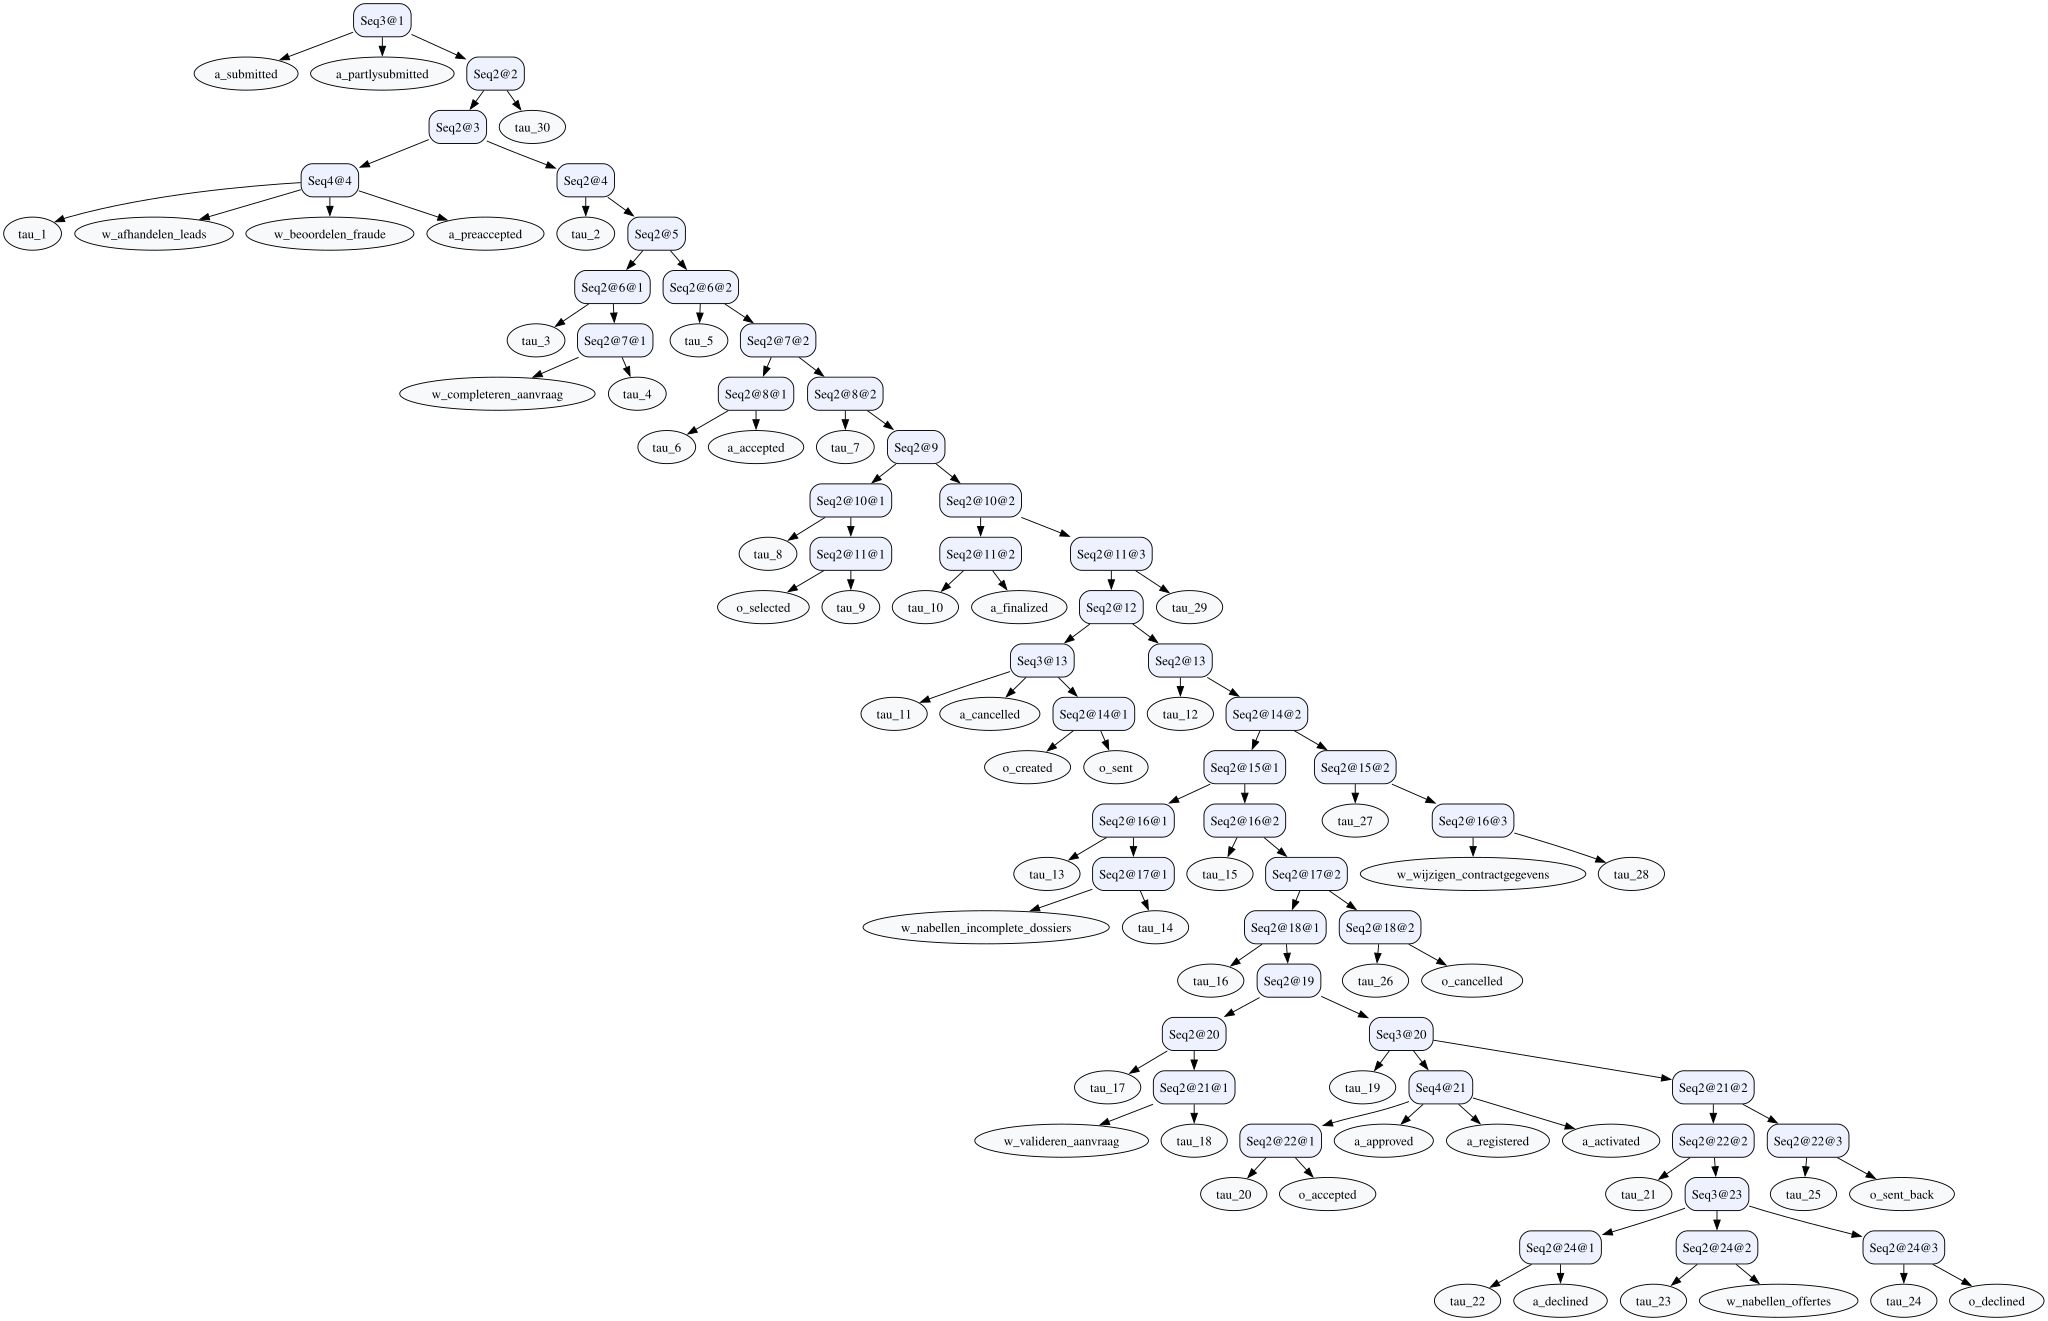

--------------------------------------------------------------------------------
Tree: log=bpi_2012, noise=0.25


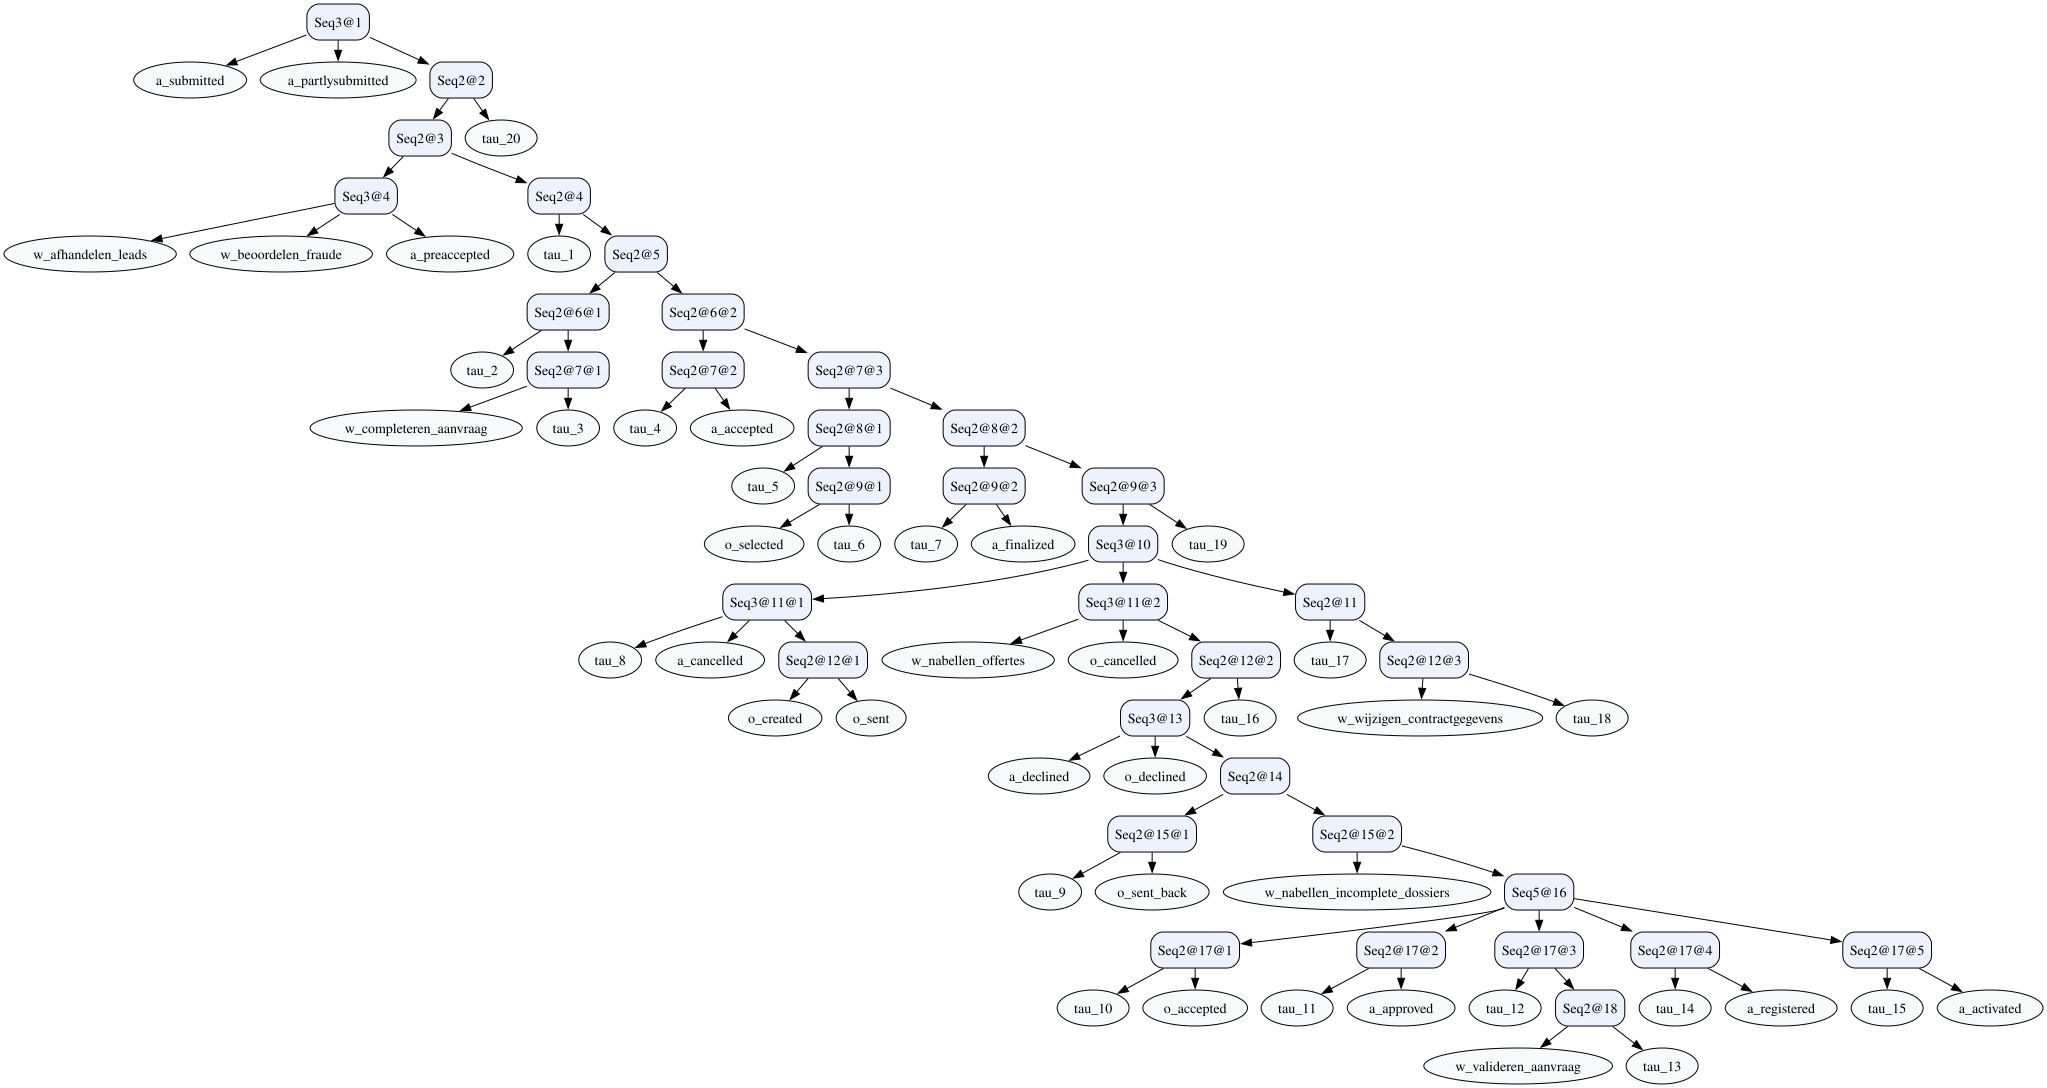

--------------------------------------------------------------------------------
Tree: log=bpi_2012, noise=0.5


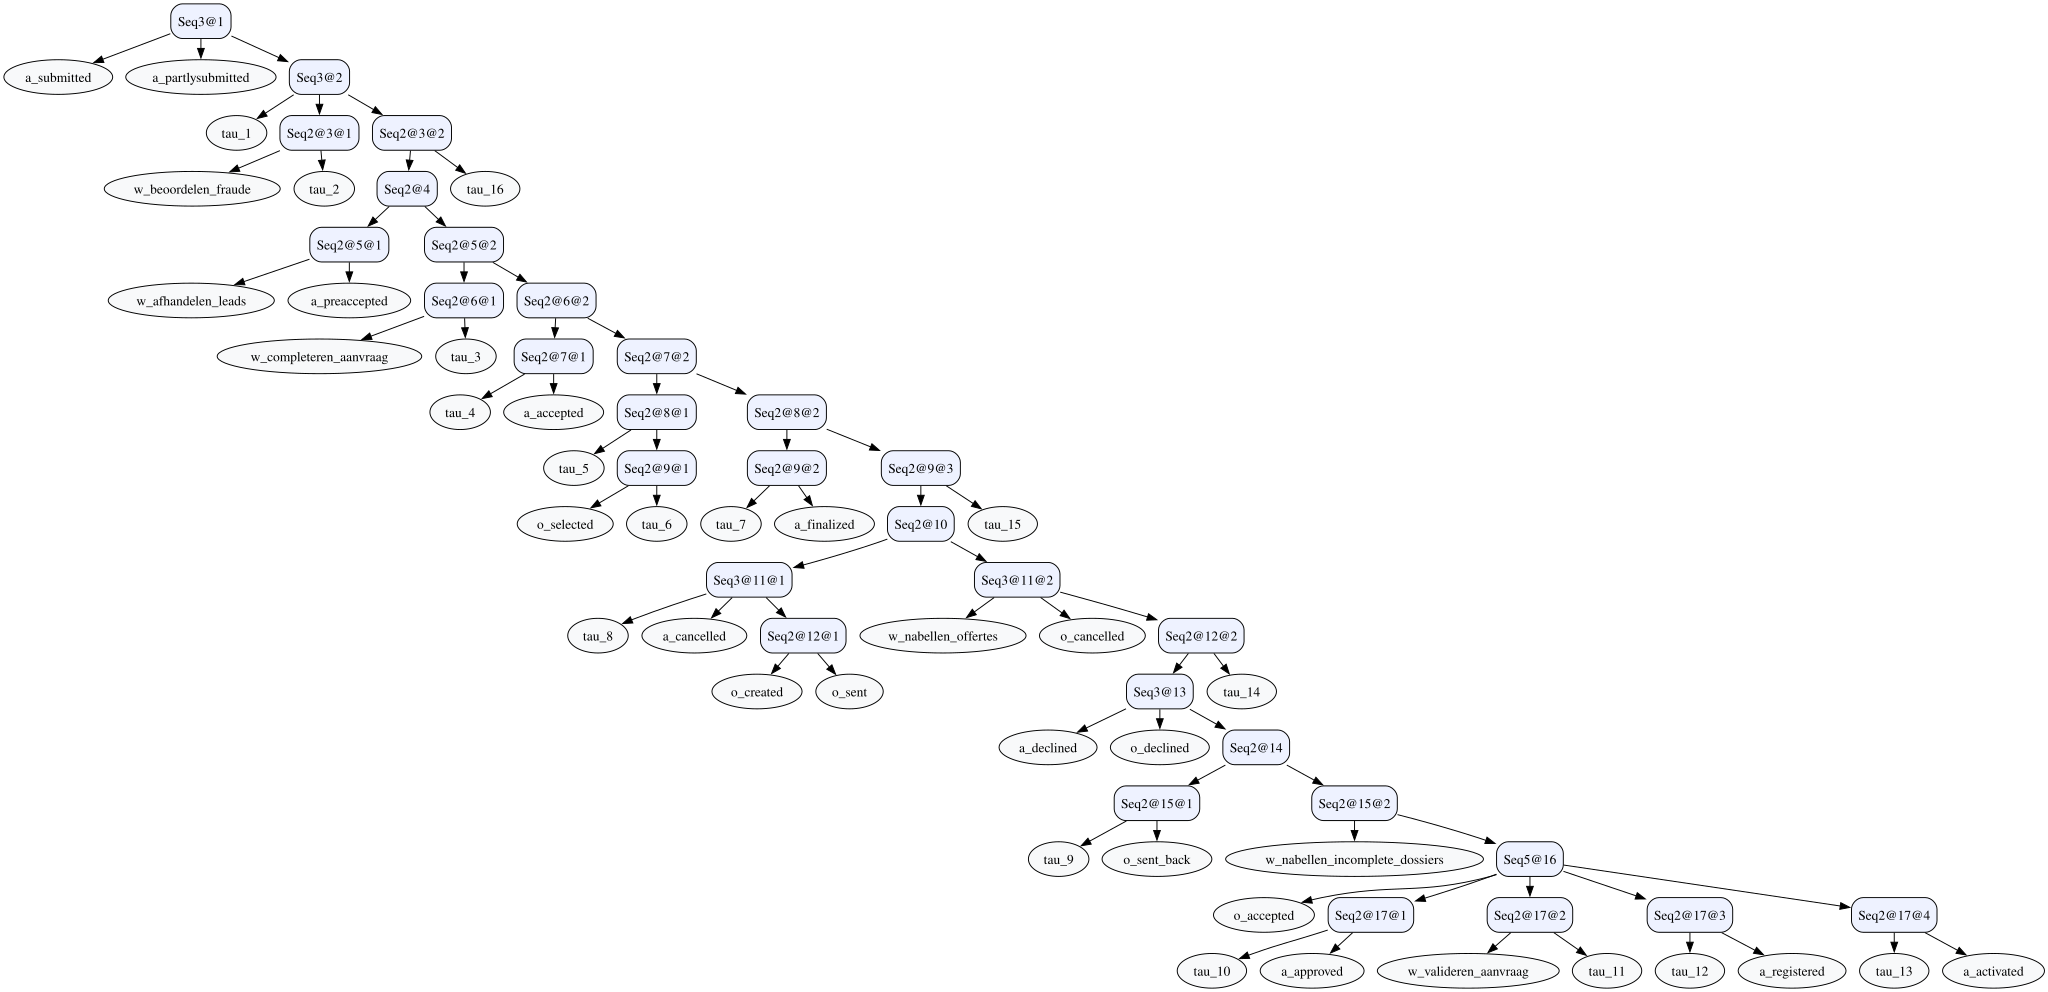

--------------------------------------------------------------------------------
Tree: log=bpi_2012, noise=1.0


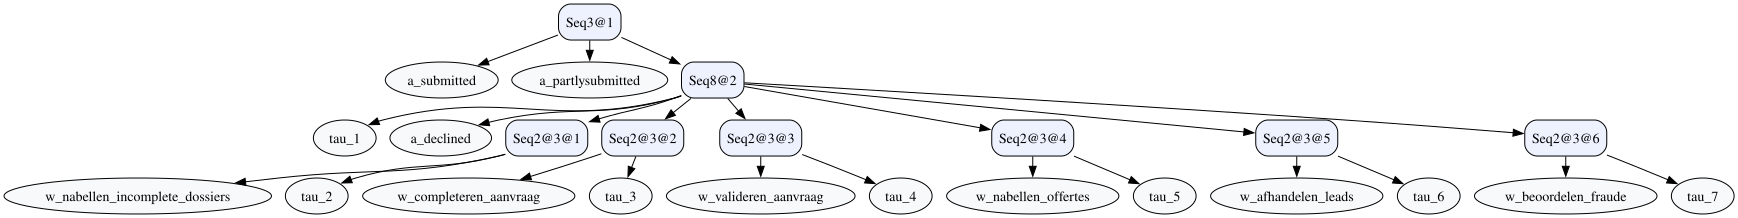

--------------------------------------------------------------------------------
Tree: log=hospital_billing, noise=0.0


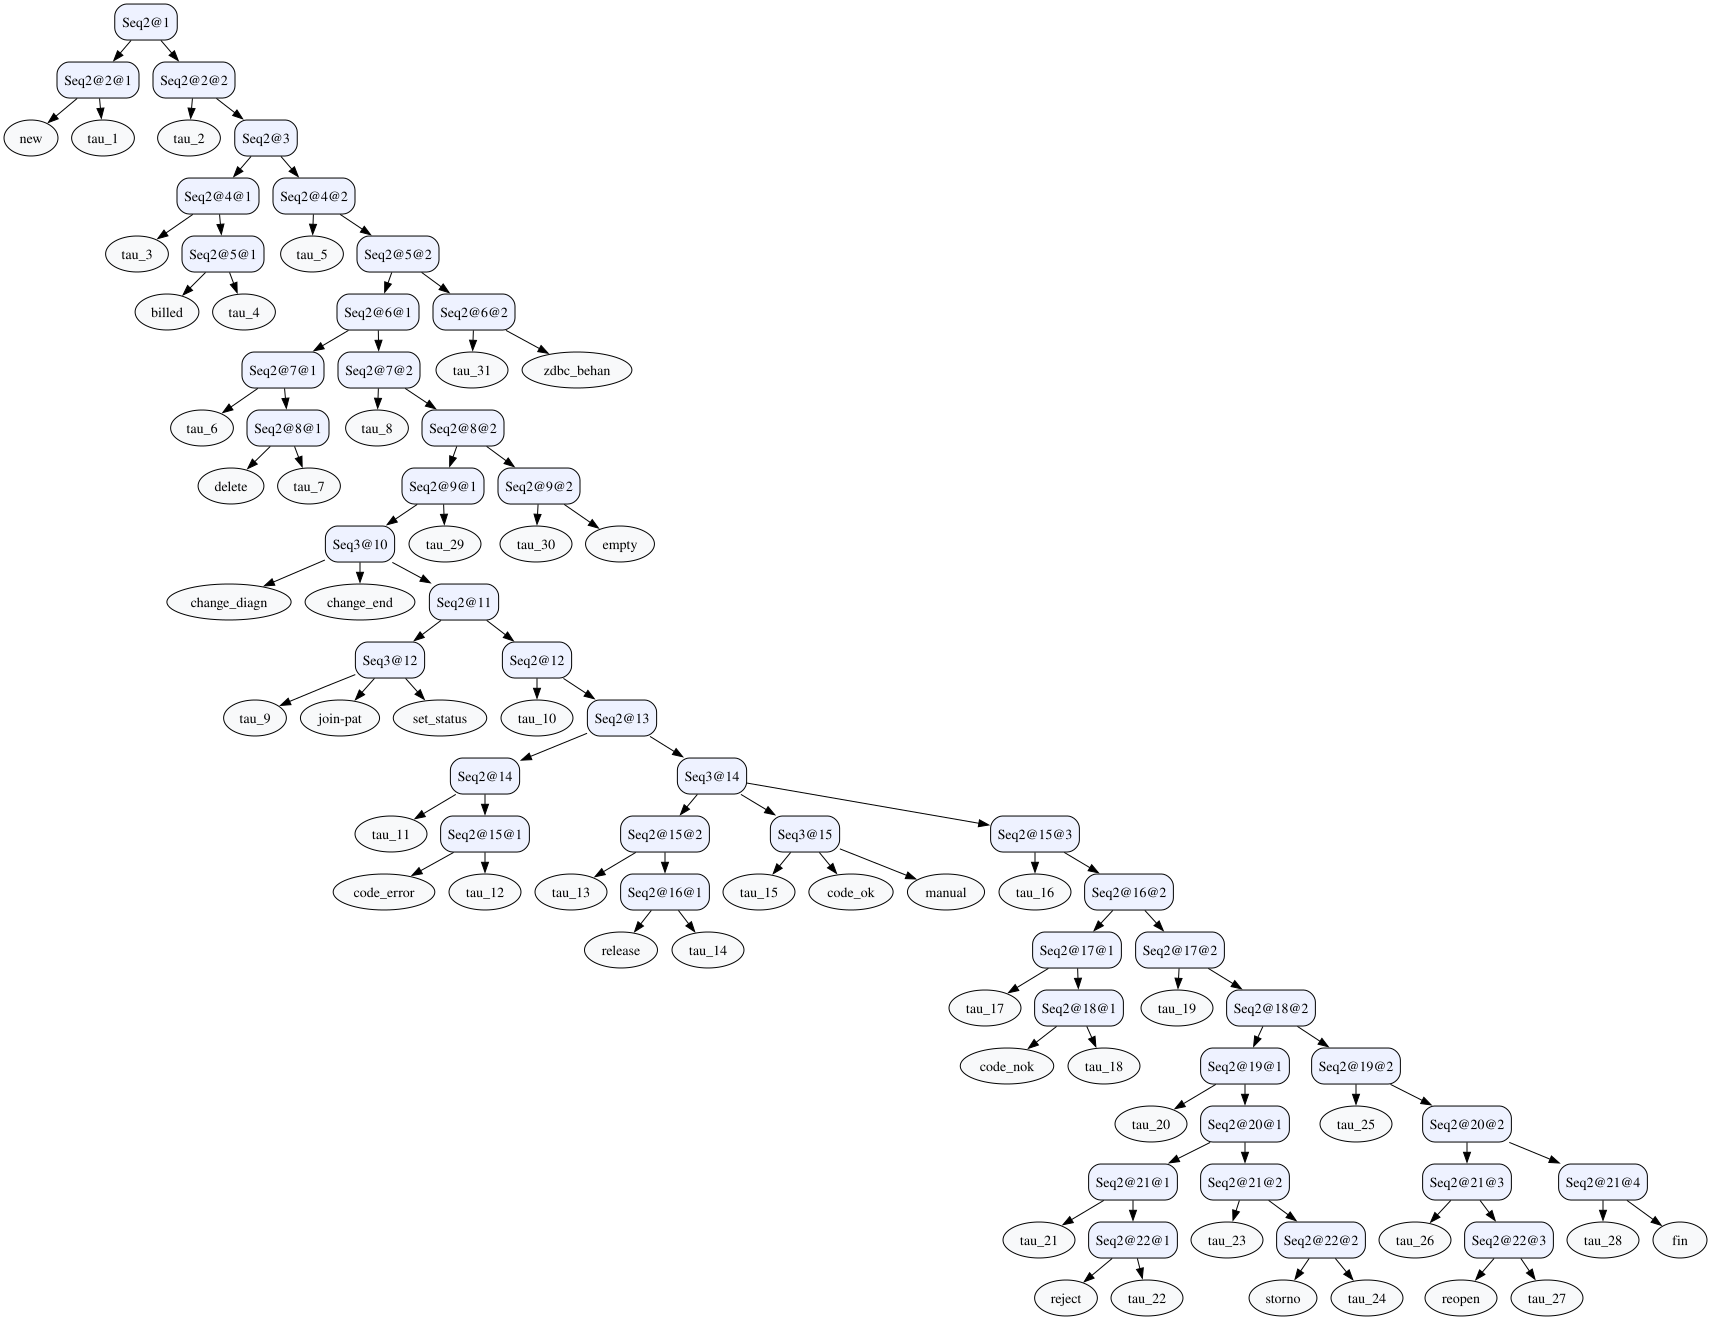

--------------------------------------------------------------------------------
Tree: log=hospital_billing, noise=0.25


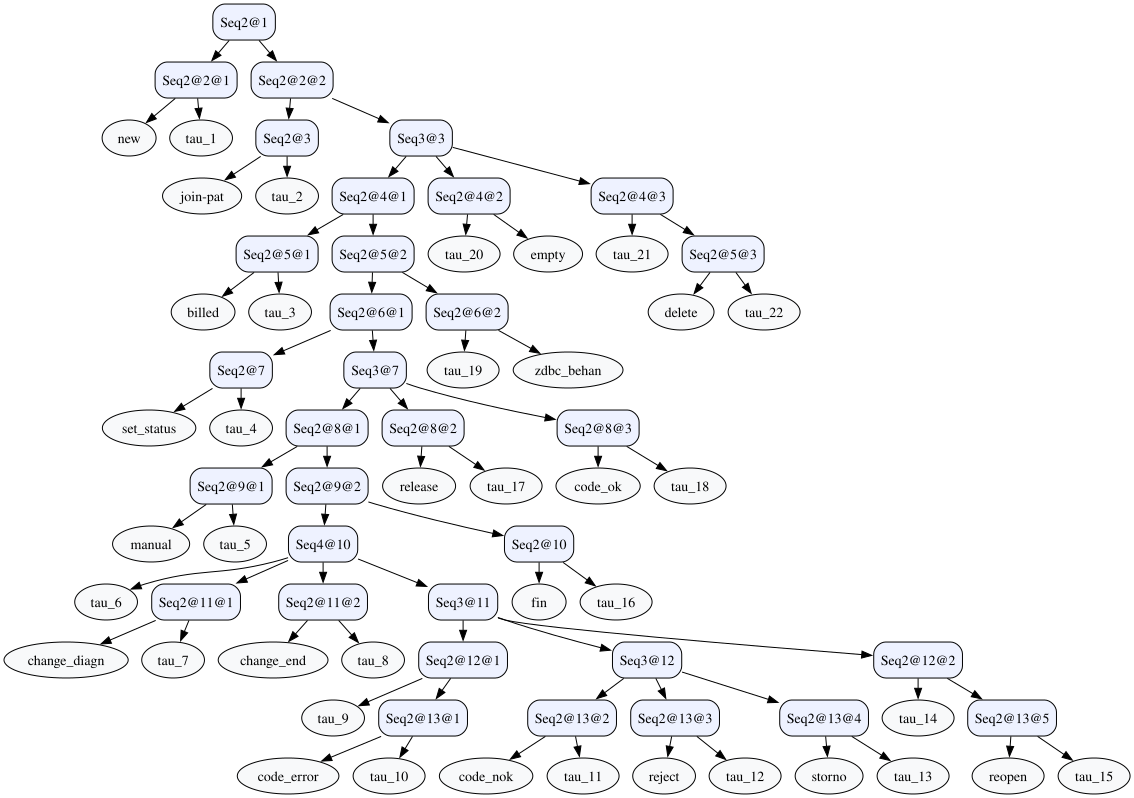

--------------------------------------------------------------------------------
Tree: log=hospital_billing, noise=0.5


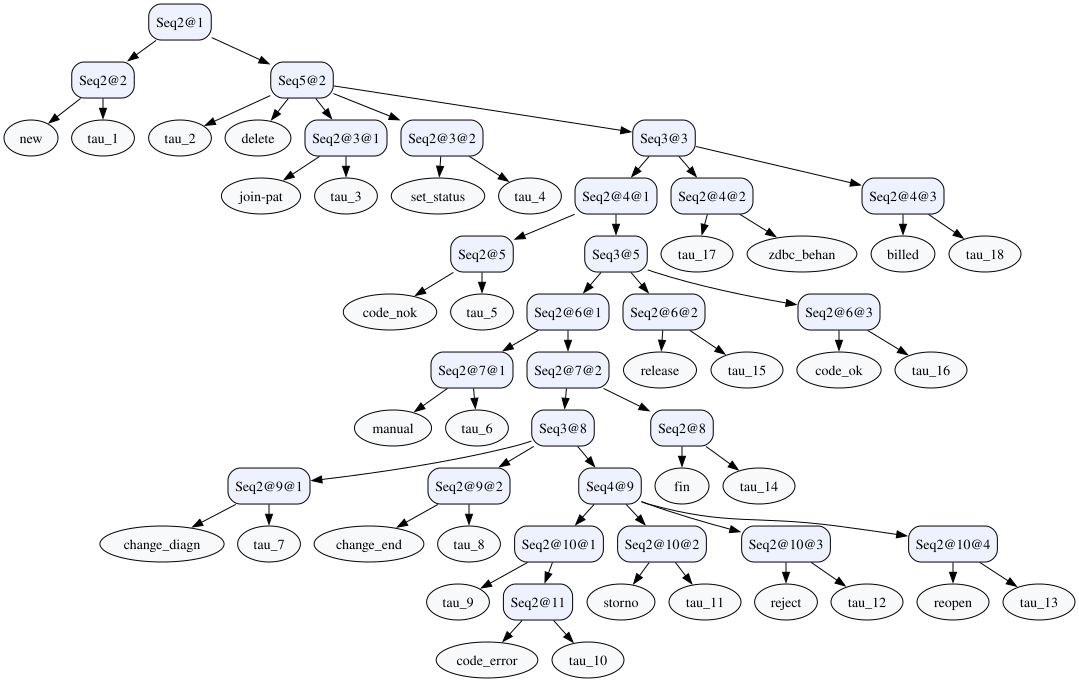

--------------------------------------------------------------------------------
Tree: log=hospital_billing, noise=1.0


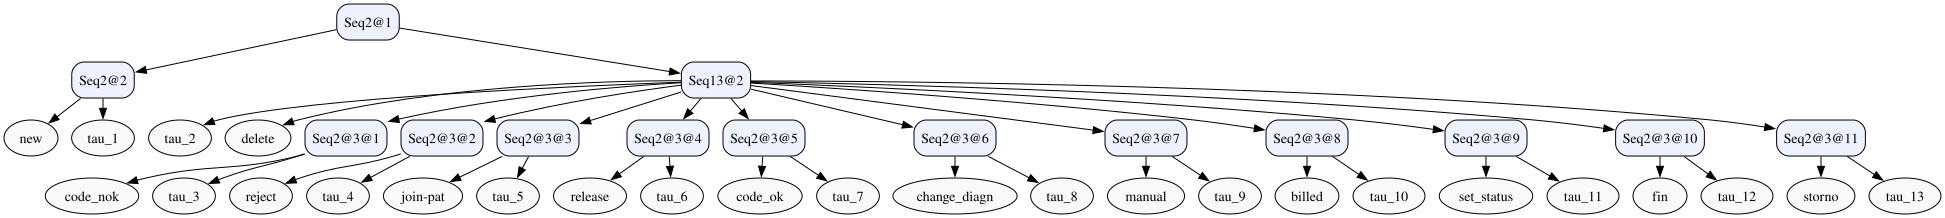

--------------------------------------------------------------------------------
Tree: log=running_example, noise=0.0


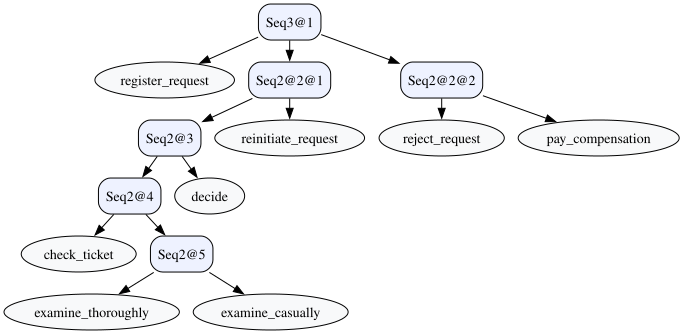

--------------------------------------------------------------------------------
Tree: log=running_example, noise=0.25


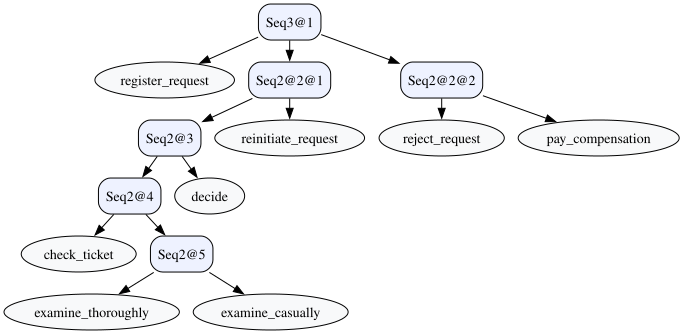

--------------------------------------------------------------------------------
Tree: log=running_example, noise=0.5


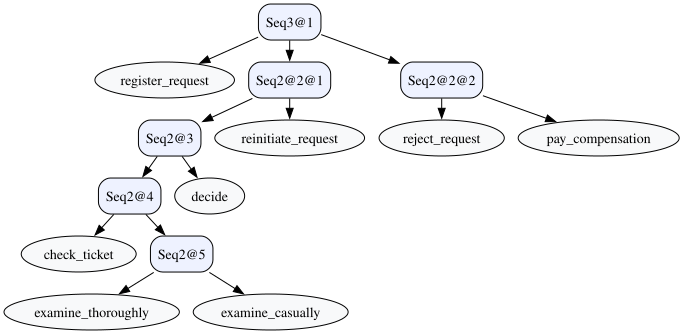

--------------------------------------------------------------------------------
Tree: log=running_example, noise=1.0


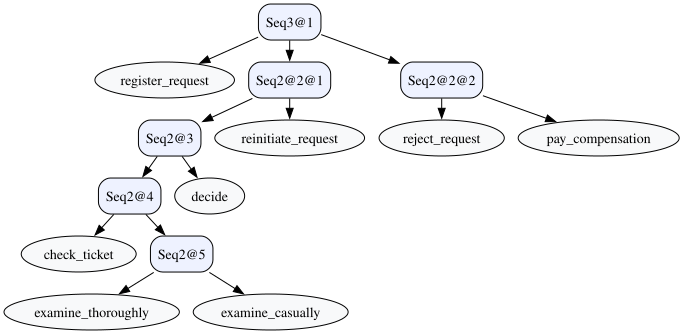

In [86]:
def _build_graphviz_from_tree(tree_dict) -> Digraph:
    dot = Digraph(comment="Pattern Tree", format="png")
    dot.attr(rankdir="TB", nodesep="0.2", ranksep="0.3")

    uid = count(1)
    totals = defaultdict(int)

    def tally(node):
        if node.get("type") == "pattern":
            totals[node["id"]] += 1
        for ch in node.get("children", []):
            tally(ch)

    tally(tree_dict)
    seen = defaultdict(int)

    def resolved_label(node_label: str) -> str:
        if totals[node_label] <= 1:
            return node_label
        seen[node_label] += 1
        return f"{node_label}@{seen[node_label]}"

    def add(node) -> str:
        node_id = f"n{next(uid)}"
        if node.get("type") == "pattern":
            label_for_display = resolved_label(node["id"])
            dot.node(node_id, label=label_for_display, shape="box", style="rounded,filled", fillcolor="#eef2ff")
            for ch in node.get("children", []):
                cid = add(ch)
                dot.edge(node_id, cid)
        else:
            txt = str(node.get("text", ""))
            dot.node(node_id, label=txt, shape="ellipse", style="filled", fillcolor="#f8f9fa")
        return node_id

    add(tree_dict)
    return dot


def visualize_named_expression_tree(named_expr: str, *, display_graph: bool = True, filename_prefix: str | None = None) -> Digraph:
    tree = _parse_labelled_expression_to_tree(named_expr)
    dot = _build_graphviz_from_tree(tree)

    if filename_prefix:
        dot.render(filename_prefix, cleanup=True)
    if display_graph:
        display(dot)
    return dot

def visualize_tree_for_config(log_name: str, noise: float):
    key = (log_name, noise)
    assert key in PATTERNS, f"Missing pattern for {(log_name, noise)}"
    named_expr = PATTERNS[key]
    print(f"Process tree with labelled patterns for log={log_name}, noise={noise}")
    visualize_named_expression_tree(named_expr)

for (log_name, noise), named_expr in sorted(PATTERNS.items(), key=lambda kv: (kv[0][0], kv[0][1])):
    print("-" * 80)
    print(f"Tree: log={log_name}, noise={noise}")
    visualize_named_expression_tree(named_expr)
